# Importing Libraries

In [ ]:
# import the warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.set_option("display.max_columns",None)




# Read Application CSV

In [ ]:
app_data = pd.read_csv("application_data.csv")
app_data.head()

# Data Inspection on apploication Dataset 
# Get info and shape on the dataset


In [237]:
app_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


## Data Quality check

### check for percentage null values in Application dataset

In [239]:
pd.set_option('display.max_rows',200)
app_data.isnull().mean() *100

SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.003902
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     65.990810
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0

- Conclusion : Columns with null values more than 47% may give wrong insights,hence will drop them

### dropping columns with missing values greater then 47%

In [ ]:
percentage = 47
threshold = int(((100 - percentage) / 100) * app_data.shape[0] + 1)
app_df = app_data.dropna(axis=1 ,thresh=threshold)
app_df = app_data.dropna(axis=1 , how = 'any')
app_df.head()


In [ ]:
app_df.shape

In [244]:
app_df = pd.read_csv('application_data.csv', na_values=["", "NA", "N/A", "#N/A"])
print(app_df.isnull().mean() * 100)


SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.003902
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     65.990810
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0

In [245]:
app_df.isnull().mean()*100

SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.003902
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     65.990810
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0

## Impute missing values 
  #### Check the missing values in application dataset before imputing 

In [247]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


## OCCUPATION_TYPE column has 31% missing values ,since its a categorical column,imputing  the missing value with a unknown or other values

In [249]:
app_df.OCCUPATION_TYPE.isnull().mean()*100

31.345545362604916

In [250]:
app_df.OCCUPATION_TYPE .value_counts(normalize=True)*100

OCCUPATION_TYPE
Laborers                 26.139636
Sales staff              15.205570
Core staff               13.058924
Managers                 10.122679
Drivers                   8.811576
High skill tech staff     5.390299
Accountants               4.648067
Medicine staff            4.043672
Security staff            3.183498
Cooking staff             2.816408
Cleaning staff            2.203960
Private service staff     1.256158
Low-skill Laborers        0.991379
Waiters/barmen staff      0.638499
Secretaries               0.618132
Realty agents             0.355722
HR staff                  0.266673
IT staff                  0.249147
Name: proportion, dtype: float64

In [251]:
app_df.OCCUPATION_TYPE .fillna("Others" , inplace=True)


In [252]:
app_df.OCCUPATION_TYPE .isnull().mean()*100

0.0

In [253]:
app_df.OCCUPATION_TYPE.value_counts(normalize=True)*100

OCCUPATION_TYPE
Others                   31.345545
Laborers                 17.946025
Sales staff              10.439301
Core staff                8.965533
Managers                  6.949670
Drivers                   6.049540
High skill tech staff     3.700681
Accountants               3.191105
Medicine staff            2.776161
Security staff            2.185613
Cooking staff             1.933589
Cleaning staff            1.513117
Private service staff     0.862408
Low-skill Laborers        0.680626
Waiters/barmen staff      0.438358
Secretaries               0.424375
Realty agents             0.244219
HR staff                  0.183083
IT staff                  0.171051
Name: proportion, dtype: float64

#### EXT_SOURCE_3 Column has 19% missing values 

In [255]:
app_df.EXT_SOURCE_3.isnull().mean()*100

19.825307062186393

In [256]:
app_df.EXT_SOURCE_3.value_counts(normalize=True)*100


EXT_SOURCE_3
0.746300    0.592182
0.713631    0.533369
0.694093    0.517550
0.670652    0.483074
0.652897    0.468067
              ...   
0.021492    0.000406
0.019468    0.000406
0.023062    0.000406
0.014556    0.000406
0.043227    0.000406
Name: proportion, Length: 814, dtype: float64

In [257]:
app_df.EXT_SOURCE_3.describe()

count    246546.000000
mean          0.510853
std           0.194844
min           0.000527
25%           0.370650
50%           0.535276
75%           0.669057
max           0.896010
Name: EXT_SOURCE_3, dtype: float64

In [258]:
# Convert 'EXT_SOURCE_3' back to numeric, forcing errors to NaN
app_df['EXT_SOURCE_3'] = pd.to_numeric(app_df['EXT_SOURCE_3'], errors='coerce')


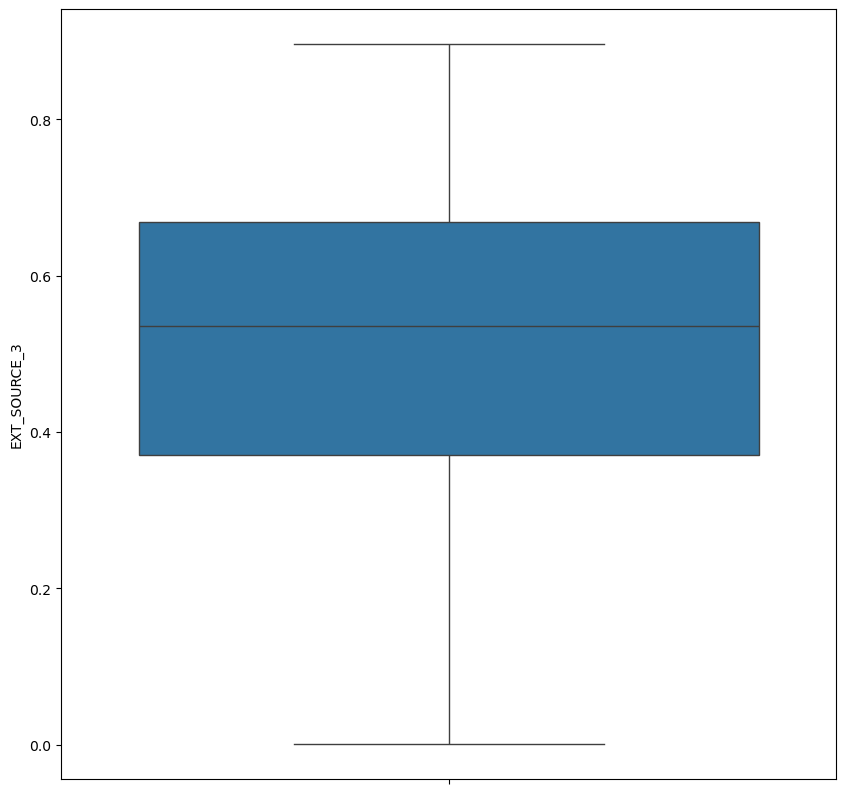

In [259]:
sns.boxplot(app_df.EXT_SOURCE_3)
plt.show()

In [260]:
app_df.EXT_SOURCE_3.fillna(app_df.EXT_SOURCE_3.median(), inplace=True)

In [261]:
app_df.EXT_SOURCE_3.isnull().mean()*100

0.0

In [262]:
app_df.EXT_SOURCE_3.value_counts(normalize=True)*100

EXT_SOURCE_3
0.535276    20.080908
0.746300     0.474780
0.713631     0.427627
0.694093     0.414945
0.670652     0.387303
              ...    
0.021492     0.000325
0.019468     0.000325
0.023062     0.000325
0.014556     0.000325
0.043227     0.000325
Name: proportion, Length: 814, dtype: float64

- Conclusion : since it is a numerical column with no outliers and there is not much difference between mean and median
hence we can impute with mean or median 

In [264]:
null_cols = list(app_df.isna().any())
len(null_cols)

122

In [265]:
app_df.isnull().mean() *100

SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.003902
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     65.990810
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0

### Handling missing values in Columns with 13% null values 

In [267]:
app_df.AMT_REQ_CREDIT_BUREAU_HOUR .value_counts(normalize=True)*100

AMT_REQ_CREDIT_BUREAU_HOUR
0.0    99.388703
1.0     0.586484
2.0     0.021053
3.0     0.003384
4.0     0.000376
Name: proportion, dtype: float64

In [268]:
app_df.AMT_REQ_CREDIT_BUREAU_DAY.value_counts(normalize=True)*100

AMT_REQ_CREDIT_BUREAU_DAY
0.0    99.440209
1.0     0.485729
2.0     0.039851
3.0     0.016918
4.0     0.009775
5.0     0.003384
6.0     0.003008
9.0     0.000752
8.0     0.000376
Name: proportion, dtype: float64

- Conclusion: we could see that 99% of values in the columns AMT_REQ_CREDIT_BUREAU_HOUR ,AMT_REQ_CREDIT_BUREAU_DAY, AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR   is 0.0 hence compute the columns with theses methods 

In [270]:
Cols = ["AMT_REQ_CREDIT_BUREAU_HOUR","AMT_REQ_CREDIT_BUREAU_DAY","AMT_REQ_CREDIT_BUREAU_WEEK","AMT_REQ_CREDIT_BUREAU_MON","AMT_REQ_CREDIT_BUREAU_QRT","AMT_REQ_CREDIT_BUREAU_YEAR"]  

In [271]:
for col in Cols :
    app_df[col].fillna(app_df[col].mode()[0], inplace = True)

In [272]:
app_df.isnull().mean()*100

SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.003902
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     65.990810
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0

# Others

In [274]:
app_df.OWN_CAR_AGE.isnull().mean()*100

65.9908100848425

In [275]:
app_df.OWN_CAR_AGE.value_counts(normalize=True)*100

OWN_CAR_AGE
7.0     7.098736
6.0     6.102389
3.0     6.090914
8.0     5.629076
2.0     5.595609
4.0     5.313534
1.0     5.048670
9.0     4.800061
10.0    4.595437
14.0    4.392725
13.0    4.365952
12.0    4.070490
11.0    3.978696
5.0     3.437494
15.0    3.423151
16.0    3.208009
17.0    2.771988
64.0    2.335966
18.0    2.312061
0.0     2.040504
19.0    1.782333
20.0    1.460098
21.0    1.397946
22.0    1.195234
24.0    1.099616
23.0    1.020252
65.0    0.851963
25.0    0.827102
26.0    0.554589
28.0    0.518254
27.0    0.461839
29.0    0.379606
30.0    0.311717
31.0    0.255302
32.0    0.198887
34.0    0.174982
35.0    0.150121
33.0    0.126217
36.0    0.118567
38.0    0.092750
40.0    0.081276
39.0    0.074583
37.0    0.071714
41.0    0.055459
42.0    0.040160
44.0    0.020080
43.0    0.018168
54.0    0.011474
45.0    0.010518
49.0    0.005737
46.0    0.004781
55.0    0.003825
51.0    0.002869
91.0    0.001912
63.0    0.001912
56.0    0.000956
57.0    0.000956
69.0    0.000956
50

In [276]:
app_df.OWN_CAR_AGE.fillna("Others" , inplace=True)

In [277]:
app_df.OWN_CAR_AGE.isnull().mean()*100

0.0

In [278]:
app_df.OWN_CAR_AGE.value_counts(normalize=True)*100

OWN_CAR_AGE
Others    65.990810
7.0        2.414223
6.0        2.075373
3.0        2.071471
8.0        1.914403
2.0        1.903021
4.0        1.807090
1.0        1.717012
9.0        1.632462
10.0       1.562871
14.0       1.493930
13.0       1.484825
12.0       1.384341
11.0       1.353122
5.0        1.169064
15.0       1.164186
16.0       1.091018
17.0       0.942731
64.0       0.794443
18.0       0.786313
0.0        0.693959
19.0       0.606157
20.0       0.496568
21.0       0.475430
22.0       0.406490
24.0       0.373970
23.0       0.346979
65.0       0.289746
25.0       0.281291
26.0       0.188611
28.0       0.176254
27.0       0.157068
29.0       0.129101
30.0       0.106012
31.0       0.086826
32.0       0.067640
34.0       0.059510
35.0       0.051055
33.0       0.042925
36.0       0.040324
38.0       0.031544
40.0       0.027641
39.0       0.025365
37.0       0.024389
41.0       0.018861
42.0       0.013658
44.0       0.006829
43.0       0.006179
54.0       0.003902
45.0    

In [279]:
Cols = ["EXT_SOURCE_1","APARTMENTS_AVG","BASEMENTAREA_AVG","YEARS_BEGINEXPLUATATION_AVG","YEARS_BUILD_AVG","COMMONAREA_AVG","ELEVATORS_AVG","ENTRANCES_AVG","FLOORSMAX_AVG","FLOORSMIN_AVG","LANDAREA_AVG","LIVINGAPARTMENTS_AVG","LIVINGAREA_AVG","NONLIVINGAPARTMENTS_AVG","NONLIVINGAREA_AVG","APARTMENTS_MODE","BASEMENTAREA_MODE","YEARS_BEGINEXPLUATATION_MODE","YEARS_BUILD_MODE","COMMONAREA_MODE","ELEVATORS_MODE","ENTRANCES_MODE","FLOORSMAX_MODE","FLOORSMIN_MODE","LANDAREA_MODE","LIVINGAPARTMENTS_MODE","LIVINGAREA_MODE","NONLIVINGAPARTMENTS_MODE","NONLIVINGAREA_MODE","APARTMENTS_MEDI","BASEMENTAREA_MEDI","YEARS_BEGINEXPLUATATION_MEDI","YEARS_BUILD_MEDI","COMMONAREA_MEDI","ELEVATORS_MEDI","ENTRANCES_MEDI","FLOORSMAX_MEDI","FLOORSMIN_MEDI","LANDAREA_MEDI","LIVINGAPARTMENTS_MEDI","LIVINGAREA_MEDI","NONLIVINGAPARTMENTS_MEDI","NONLIVINGAREA_MEDI","FONDKAPREMONT_MODE","HOUSETYPE_MODE","TOTALAREA_MODE","WALLSMATERIAL_MODE","EMERGENCYSTATE_MODE" ]

In [280]:
for col in Cols :
    app_df[col].fillna(app_df[col].mode()[0], inplace = True)

In [281]:
app_df.isnull().mean()*100

SK_ID_CURR                      0.000000
TARGET                          0.000000
NAME_CONTRACT_TYPE              0.000000
CODE_GENDER                     0.000000
FLAG_OWN_CAR                    0.000000
FLAG_OWN_REALTY                 0.000000
CNT_CHILDREN                    0.000000
AMT_INCOME_TOTAL                0.000000
AMT_CREDIT                      0.000000
AMT_ANNUITY                     0.003902
AMT_GOODS_PRICE                 0.090403
NAME_TYPE_SUITE                 0.420148
NAME_INCOME_TYPE                0.000000
NAME_EDUCATION_TYPE             0.000000
NAME_FAMILY_STATUS              0.000000
NAME_HOUSING_TYPE               0.000000
REGION_POPULATION_RELATIVE      0.000000
DAYS_BIRTH                      0.000000
DAYS_EMPLOYED                   0.000000
DAYS_REGISTRATION               0.000000
DAYS_ID_PUBLISH                 0.000000
OWN_CAR_AGE                     0.000000
FLAG_MOBIL                      0.000000
FLAG_EMP_PHONE                  0.000000
FLAG_WORK_PHONE 

##Handling Missing values less than 1 % 

In [283]:
null_cols = list(app_df.columns[app_df.isna().any()])
len(null_cols)

10

In [284]:
app_df.NAME_TYPE_SUITE .value_counts(normalize=True)*100

NAME_TYPE_SUITE
Unaccompanied      81.159562
Family             13.111205
Spouse, partner     3.713029
Children            1.066884
Other_B             0.578018
Other_A             0.282804
Group of people     0.088499
Name: proportion, dtype: float64

In [285]:
app_df.EXT_SOURCE_2 .value_counts(normalize=True)*100

EXT_SOURCE_2
0.285898    0.234967
0.262258    0.135897
0.265256    0.111781
0.159679    0.104937
0.265312    0.099723
              ...   
0.004725    0.000326
0.257313    0.000326
0.282030    0.000326
0.181540    0.000326
0.267834    0.000326
Name: proportion, Length: 119831, dtype: float64

In [286]:
app_df.OBS_30_CNT_SOCIAL_CIRCLE.value_counts(normalize=True)*100

OBS_30_CNT_SOCIAL_CIRCLE
0.0      53.479722
1.0      15.916669
2.0       9.725603
3.0       6.630559
4.0       4.614506
5.0       3.116904
6.0       2.105452
7.0       1.432347
8.0       0.968058
9.0       0.653529
10.0      0.448954
11.0      0.277986
12.0      0.212731
13.0      0.134099
14.0      0.084179
15.0      0.054162
16.0      0.043395
17.0      0.028712
18.0      0.015009
19.0      0.014356
20.0      0.009788
21.0      0.009462
22.0      0.007178
23.0      0.004894
25.0      0.003589
24.0      0.003589
27.0      0.001631
26.0      0.000979
30.0      0.000653
28.0      0.000326
29.0      0.000326
47.0      0.000326
348.0     0.000326
Name: proportion, dtype: float64

- Conclusion :
 
       -For categorical columns ,Impute the missing values with mode
       -For numerical columns,imputinng missing values with median

In [ ]:
app_df.NAME_TYPE_SUITE.fillna(app_df.NAME_TYPE_SUITE.mode()[0],inplace = True)

In [ ]:
app_df.CNT_FAM_MEMBERS.fillna(app_df.CNT_FAM_MEMBERS.mode()[0],inplace = True)

In [ ]:
# Imputing numerical columns
app_df.AMT_GOODS_PRICE .fillna(app_df.AMT_GOODS_PRICE .median(), inplace=True)
app_df.AMT_ANNUITY .fillna(app_df.AMT_ANNUITY .median(), inplace=True)
app_df.EXT_SOURCE_2.fillna(app_df.EXT_SOURCE_2.median(), inplace=True)
app_df.OBS_30_CNT_SOCIAL_CIRCLE.fillna(app_df.OBS_30_CNT_SOCIAL_CIRCLE.median(), inplace=True)
app_df.DEF_30_CNT_SOCIAL_CIRCLE .fillna(app_df.DEF_30_CNT_SOCIAL_CIRCLE .median(), inplace=True)
app_df.OBS_60_CNT_SOCIAL_CIRCLE.fillna(app_df.OBS_60_CNT_SOCIAL_CIRCLE.median(), inplace=True)
app_df.DEF_60_CNT_SOCIAL_CIRCLE .fillna(app_df.DEF_60_CNT_SOCIAL_CIRCLE .median(), inplace=True)
app_df.DAYS_LAST_PHONE_CHANGE .fillna(app_df.DAYS_LAST_PHONE_CHANGE.median(), inplace=True)

In [ ]:
null_cols = list(app_df.columns[app_df.isna().any()])
len(null_cols)

In [ ]:
app_df.isnull().mean()*100

#### Convert Negative values to positive in days variables so that median is not affected

In [ ]:
app_df.DAYS_BIRTH = app_df.DAYS_BIRTH.apply(lambda x : abs(x))
app_df.DAYS_EMPLOYED = app_df.DAYS_EMPLOYED.apply(lambda x : abs(x))
app_df.DAYS_REGISTRATION = app_df.DAYS_REGISTRATION.apply(lambda x : abs(x))
app_df.DAYS_ID_PUBLISH  = app_df.DAYS_ID_PUBLISH .apply(lambda x : abs(x))
app_df.DAYS_LAST_PHONE_CHANGE= app_df.DAYS_LAST_PHONE_CHANGE.apply(lambda x : abs(x))

### Binning of continouous variables

standardizing days columns in a years for easy binning

In [ ]:
app_df["YEARS_BIRTH"] = app_df.DAYS_BIRTH.apply(lambda x: int(x//356))
app_df["YEARS_EMPLOYED"] = app_df.DAYS_EMPLOYED.apply(lambda x: int(x//356))
app_df["YEARS_REGISTRATION "] = app_df.DAYS_REGISTRATION .apply(lambda x: int(x//356))
app_df["YEARS_ID_PUBLISH "] = app_df.DAYS_ID_PUBLISH .apply(lambda x: int(x//356))
app_df["YEARS_LAST_PHONE_CHANGE"] = app_df.DAYS_LAST_PHONE_CHANGE.apply(lambda x: int(x//356))

## Binning AMT_credit Column

In [298]:
app_df.AMT_CREDIT.value_counts(normalize=True)*100

AMT_CREDIT
450000.0     3.157285
675000.0     2.886726
225000.0     2.654214
180000.0     2.387557
270000.0     2.354713
               ...   
487318.5     0.000325
630400.5     0.000325
1875276.0    0.000325
1395895.5    0.000325
1391130.0    0.000325
Name: proportion, Length: 5603, dtype: float64

In [299]:
app_df.AMT_CREDIT.describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

In [300]:
app_df["AMT_CREDIT_Category"] = pd.cut(app_df.AMT_CREDIT, [0,200000, 400000, 600000, 800000,1000000], 
                                       labels = ["Very low Credit","low Credit", "Medium Credit", "High Credit", "Very High Credit"])

In [301]:
app_df.AMT_CREDIT_Category.value_counts(normalize=True)*100

AMT_CREDIT_Category
low Credit          31.511770
Medium Credit       25.733324
High Credit         16.791314
Very low Credit     14.035088
Very High Credit    11.928504
Name: proportion, dtype: float64

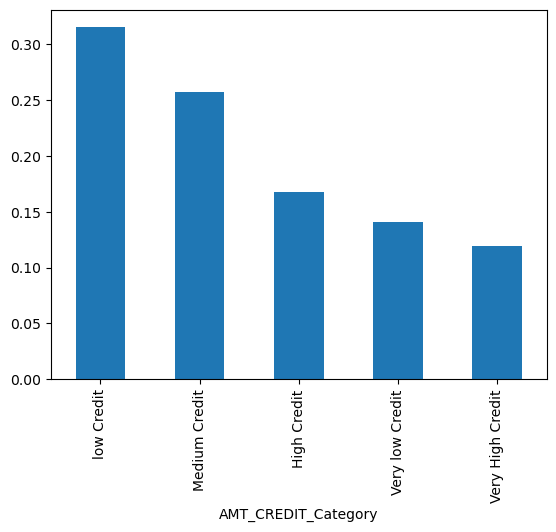

In [302]:
app_df["AMT_CREDIT_Category"].value_counts(normalize=True).plot.bar()
plt.show()

- Conclusion : The credit amount of the loan for amount low(2L to 4L) or very High (above 8L)

## Binning YEARS_BIRTH Column

In [305]:
app_df["AGE_Category"] = pd.cut(app_df.YEARS_BIRTH, [0,25, 45, 65, 85], 
                                labels = ["Below 25", "25-45", "45-65", "65-85"])

In [306]:
app_df.AGE_Category.value_counts(normalize=True)*100

AGE_Category
25-45       50.094143
45-65       41.772489
Below 25     4.426834
65-85        3.706534
Name: proportion, dtype: float64

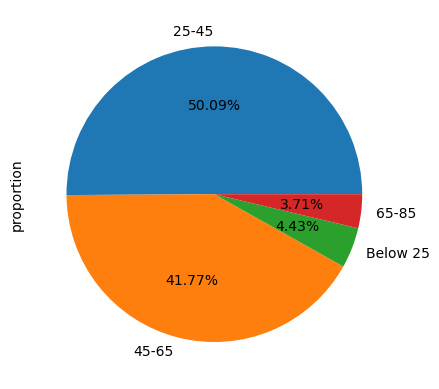

In [307]:
app_df["AGE_Category"].value_counts(normalize=True).plot.pie(autopct = '%1.2f%%')
plt.show()

- Conclusion: Most of the applicants are Between 25-45 age group

## Data Imbalance Check

In [310]:
app_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE,AMT_CREDIT_Category,AGE_Category
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,9461,637,3648.0,2120,Others,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,26,1,10,5,3,Medium Credit,25-45
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,16765,1188,1186.0,291,Others,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,47,3,3,0,2,NaN,45-65
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,19046,225,4260.0,2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY

## Dividing Application Dataset with Target Variabes as 0 and 1

In [312]:
tar_0 = app_df[app_df.TARGET == 0]
tar_1 = app_df[app_df.TARGET == 1]

In [313]:
app_df.TARGET.value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

- Conclusion: 1 out of 9/10 applicants are defaults

# Univariate Analysis

In [316]:
cat_cols = list(app_df.columns[app_df.dtypes == object])


In [317]:
cat_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OWN_CAR_AGE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [318]:
num_cols = list(app_df.columns[app_df.dtypes == np.int64]) + list(app_df.columns[app_df.dtypes == np.float64]) 

In [319]:
num_cols

['SK_ID_CURR',
 'TARGET',
 'CNT_CHILDREN',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_ID_PUBLISH',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21',
 'YEARS_BIRTH',
 'YEARS_EMPLOYED',
 'YEARS_REGISTRATION ',
 'YEARS_ID_PUBLISH ',
 'YEARS_LAST_PHONE_CHANGE',
 'AMT_INCOME_TOTA

NAME_CONTRACT_TYPE
Cash loans         0.904787
Revolving loans    0.095213
Name: proportion, dtype: float64


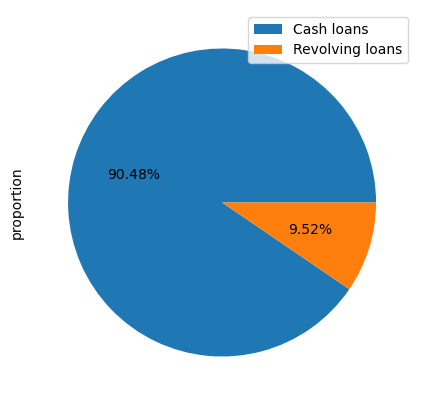

CODE_GENDER
F      0.658344
M      0.341643
XNA    0.000013
Name: proportion, dtype: float64


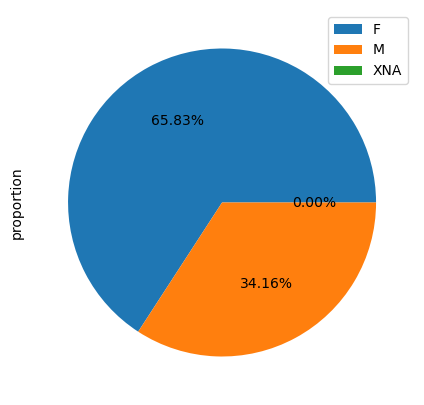

FLAG_OWN_CAR
N    0.659892
Y    0.340108
Name: proportion, dtype: float64


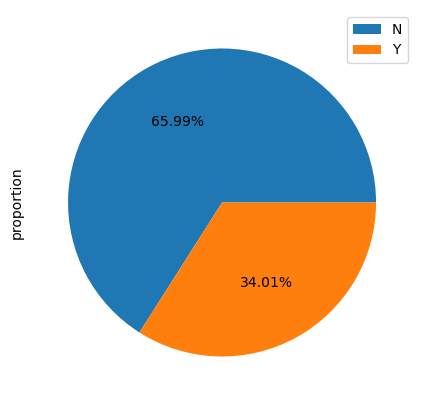

FLAG_OWN_REALTY
Y    0.693673
N    0.306327
Name: proportion, dtype: float64


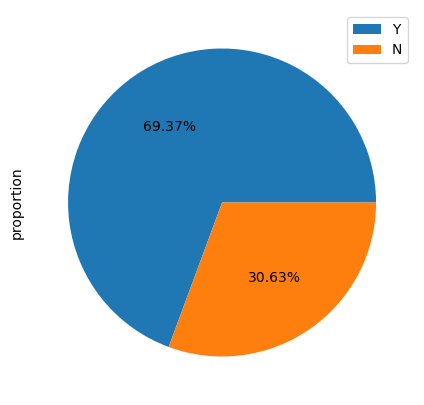

NAME_TYPE_SUITE
Unaccompanied      0.812387
Family             0.130561
Spouse, partner    0.036974
Children           0.010624
Other_B            0.005756
Other_A            0.002816
Group of people    0.000881
Name: proportion, dtype: float64


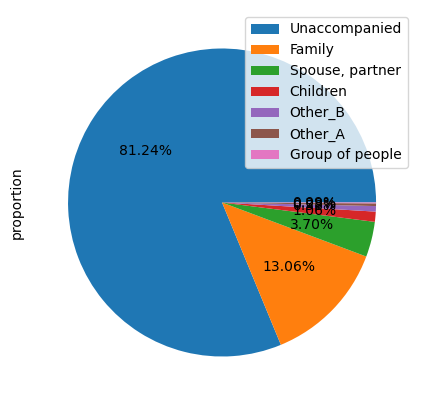

NAME_INCOME_TYPE
Working                 0.516320
Commercial associate    0.232892
Pensioner               0.180033
State servant           0.070576
Unemployed              0.000072
Student                 0.000059
Businessman             0.000033
Maternity leave         0.000016
Name: proportion, dtype: float64


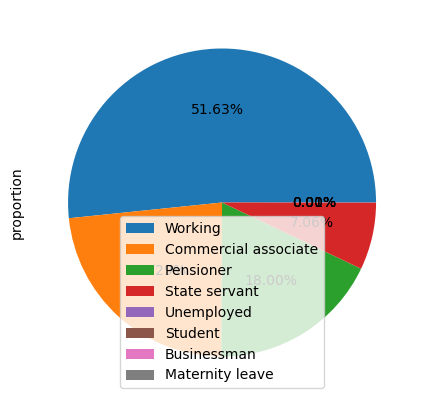

NAME_EDUCATION_TYPE
Secondary / secondary special    0.710189
Higher education                 0.243448
Incomplete higher                0.033420
Lower secondary                  0.012409
Academic degree                  0.000533
Name: proportion, dtype: float64


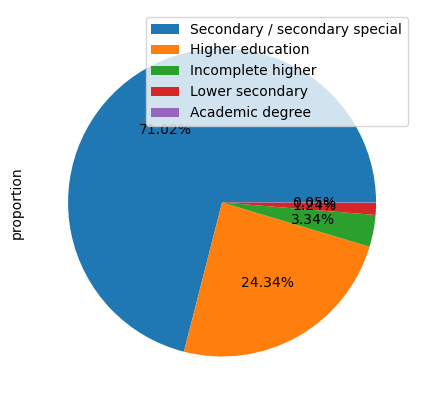

NAME_FAMILY_STATUS
Married                 0.638780
Single / not married    0.147780
Civil marriage          0.096826
Separated               0.064290
Widow                   0.052317
Unknown                 0.000007
Name: proportion, dtype: float64


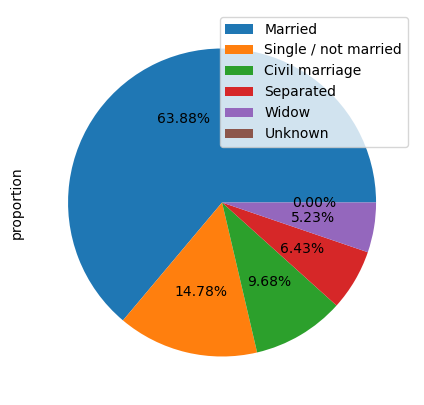

NAME_HOUSING_TYPE
House / apartment      0.887344
With parents           0.048258
Municipal apartment    0.036366
Rented apartment       0.015873
Office apartment       0.008510
Co-op apartment        0.003649
Name: proportion, dtype: float64


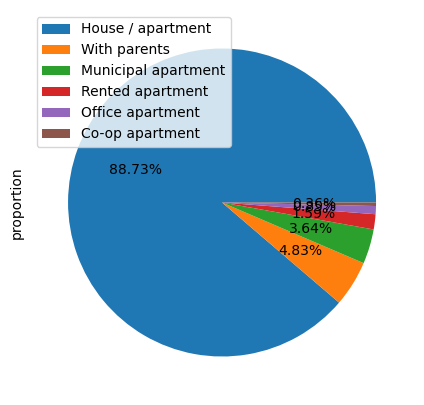

OWN_CAR_AGE
Others    0.659908
7.0       0.024142
6.0       0.020754
3.0       0.020715
8.0       0.019144
2.0       0.019030
4.0       0.018071
1.0       0.017170
9.0       0.016325
10.0      0.015629
14.0      0.014939
13.0      0.014848
12.0      0.013843
11.0      0.013531
5.0       0.011691
15.0      0.011642
16.0      0.010910
17.0      0.009427
64.0      0.007944
18.0      0.007863
0.0       0.006940
19.0      0.006062
20.0      0.004966
21.0      0.004754
22.0      0.004065
24.0      0.003740
23.0      0.003470
65.0      0.002897
25.0      0.002813
26.0      0.001886
28.0      0.001763
27.0      0.001571
29.0      0.001291
30.0      0.001060
31.0      0.000868
32.0      0.000676
34.0      0.000595
35.0      0.000511
33.0      0.000429
36.0      0.000403
38.0      0.000315
40.0      0.000276
39.0      0.000254
37.0      0.000244
41.0      0.000189
42.0      0.000137
44.0      0.000068
43.0      0.000062
54.0      0.000039
45.0      0.000036
49.0      0.000020
46.0      0.000016


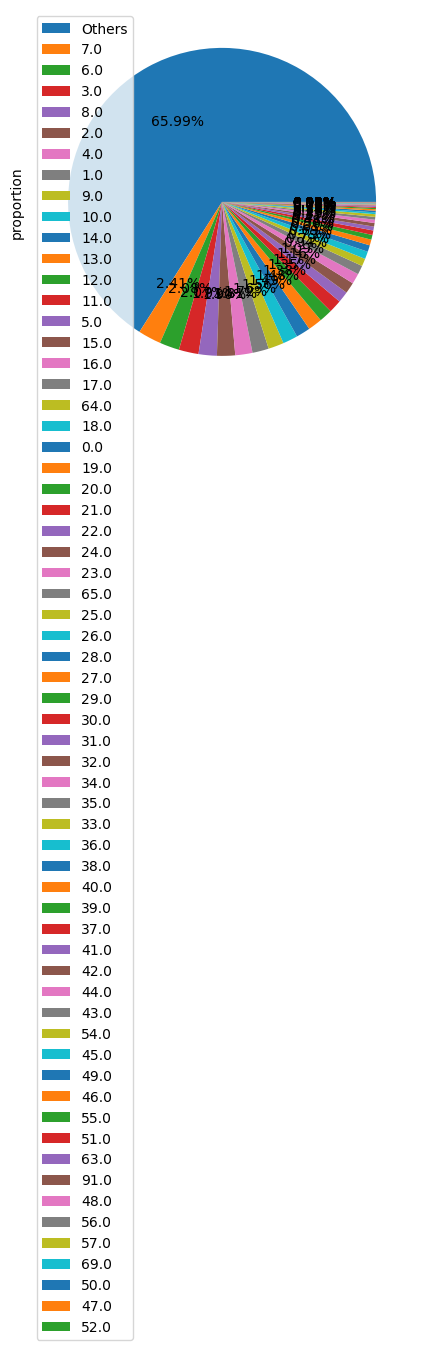

OCCUPATION_TYPE
Others                   0.313455
Laborers                 0.179460
Sales staff              0.104393
Core staff               0.089655
Managers                 0.069497
Drivers                  0.060495
High skill tech staff    0.037007
Accountants              0.031911
Medicine staff           0.027762
Security staff           0.021856
Cooking staff            0.019336
Cleaning staff           0.015131
Private service staff    0.008624
Low-skill Laborers       0.006806
Waiters/barmen staff     0.004384
Secretaries              0.004244
Realty agents            0.002442
HR staff                 0.001831
IT staff                 0.001711
Name: proportion, dtype: float64


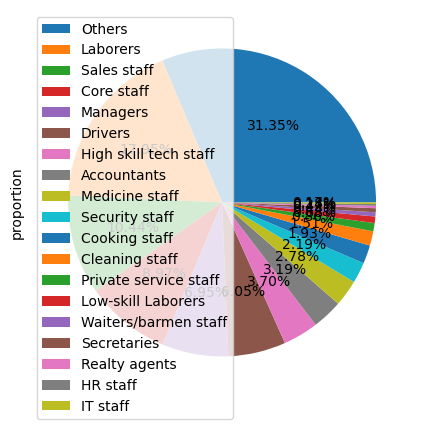

WEEKDAY_APPR_PROCESS_START
TUESDAY      0.175282
WEDNESDAY    0.168885
MONDAY       0.164918
THURSDAY     0.164518
FRIDAY       0.163695
SATURDAY     0.110084
SUNDAY       0.052619
Name: proportion, dtype: float64


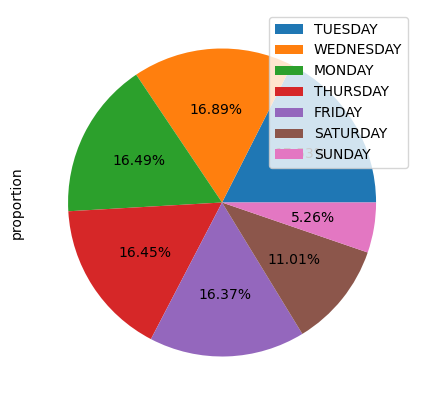

ORGANIZATION_TYPE
Business Entity Type 3    0.221104
XNA                       0.180072
Self-employed             0.124913
Other                     0.054252
Medicine                  0.036399
Business Entity Type 2    0.034317
Government                0.033833
School                    0.028919
Trade: type 7             0.025466
Kindergarten              0.022373
Construction              0.021856
Business Entity Type 1    0.019459
Transport: type 4         0.017554
Trade: type 3             0.011356
Industry: type 9          0.010952
Industry: type 3          0.010660
Security                  0.010559
Housing                   0.009619
Industry: type 11         0.008793
Military                  0.008566
Bank                      0.008153
Agriculture               0.007980
Police                    0.007613
Transport: type 2         0.007167
Postal                    0.007014
Security Ministries       0.006419
Trade: type 2             0.006179
Restaurant                0.005889
Se

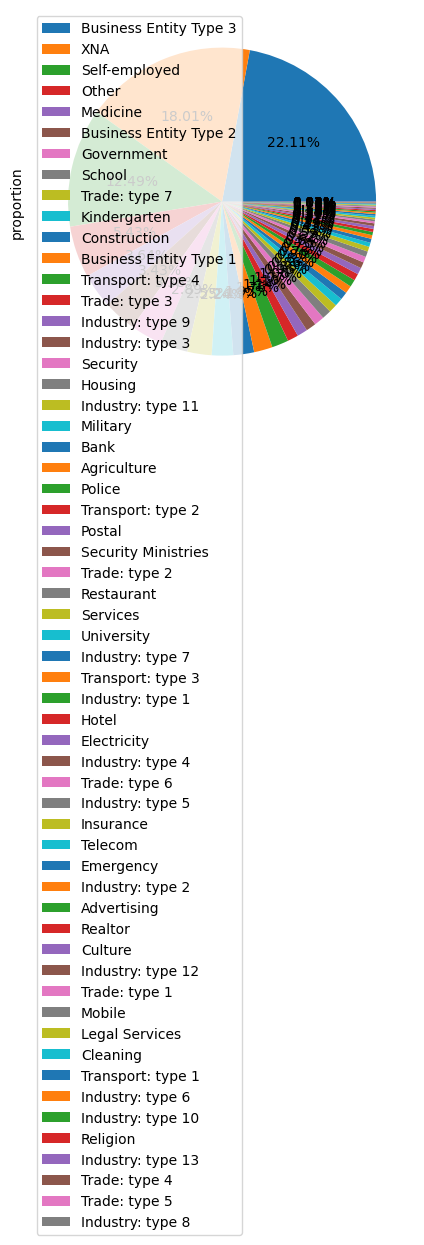

FONDKAPREMONT_MODE
reg oper account         0.923951
reg oper spec account    0.039283
not specified            0.018494
org spec account         0.018273
Name: proportion, dtype: float64


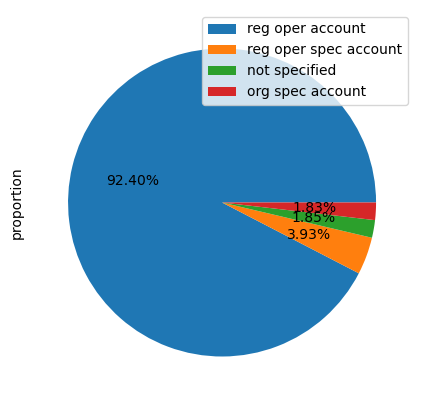

HOUSETYPE_MODE
block of flats      0.991184
specific housing    0.004875
terraced house      0.003941
Name: proportion, dtype: float64


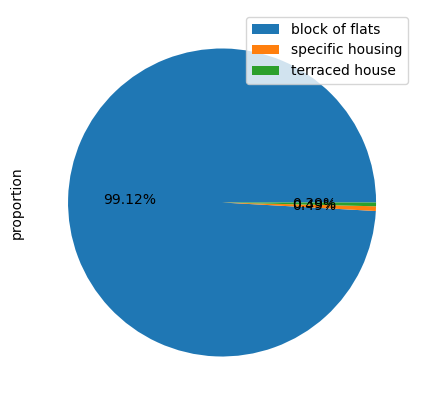

WALLSMATERIAL_MODE
Panel           0.723164
Stone, brick    0.210773
Block           0.030090
Wooden          0.017437
Mixed           0.007466
Monolithic      0.005785
Others          0.005284
Name: proportion, dtype: float64


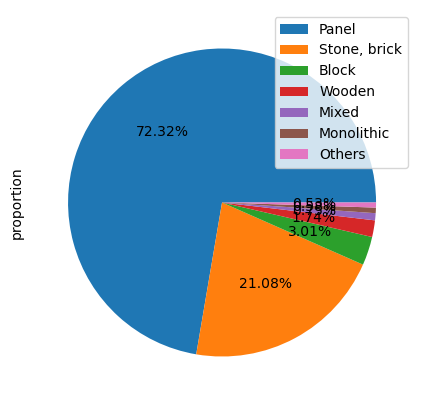

EMERGENCYSTATE_MODE
No     0.99243
Yes    0.00757
Name: proportion, dtype: float64


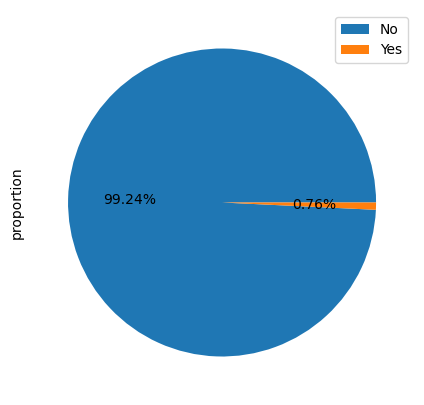

In [320]:
for col in cat_cols:
    print(app_df[col].value_counts(normalize=True))
    plt.figure(figsize=[5,5])
    app_df[col].value_counts(normalize=True).plot.pie(labeldistance = None, autopct = '%1.2f%%')
    plt.legend()
    plt.show()

-conclusion>> Insights on below columns

1.NAME_CONTRACT_TYPE - More application have cash loans than Revolving loans

2.CODE_GENDER - Number of Female applicants are twice than that of male applicants

3.FLAG_OWN_CAR - Most(70%) of the applicants do not own a car

4.FLAG_OWN_REALTY - Most(70%) of the applicants do not own a house

5.NAME_TYPE_SUITE - Most(81%) of the applicants are Unaccompanied

6.NAME_INCOME_TYPE - Most(51%) of the applicants are earning their income from Work

7.NAME_EDUCATION_TYPE -71% of the applicants have completed Secondary/secondary special 
education

8.NAME_FAMILY_STATUS -63% of the applicants are  married

9.NAME_HOUSING_TYPE - 88% of the Housing type of applicants are House/apartment

10.OCCUPATION_TYPE - Most(31%) of the applicants have other Occupation type

11.WEEKDAY_APPR_PROCESS_START - Most of the applicants have applied the loan on Tuesday

12.ORGANIZATION_TYPE - Most of the Organization type of employees are Business Entity Type 3


# Plot on Numerical Columns

 ### categorizing columns with and without flags

In [324]:
num_cols_withoutflag = []
num_cols_withflag = []
for col in num_cols:
    if col.startswith("FLAG"):
        num_cols_withflag.append(col)
    else:
        num_cols_withoutflag.append(col)


In [325]:
num_cols_withflag

['FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21']

In [326]:
num_cols_withoutflag

['SK_ID_CURR',
 'TARGET',
 'CNT_CHILDREN',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_ID_PUBLISH',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'YEARS_BIRTH',
 'YEARS_EMPLOYED',
 'YEARS_REGISTRATION ',
 'YEARS_ID_PUBLISH ',
 'YEARS_LAST_PHONE_CHANGE',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_REGISTRATION',
 'CNT_FAM_MEMBERS',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 '

count    307511.000000
mean     278180.518577
std      102790.175348
min      100002.000000
25%      189145.500000
50%      278202.000000
75%      367142.500000
max      456255.000000
Name: SK_ID_CURR, dtype: float64


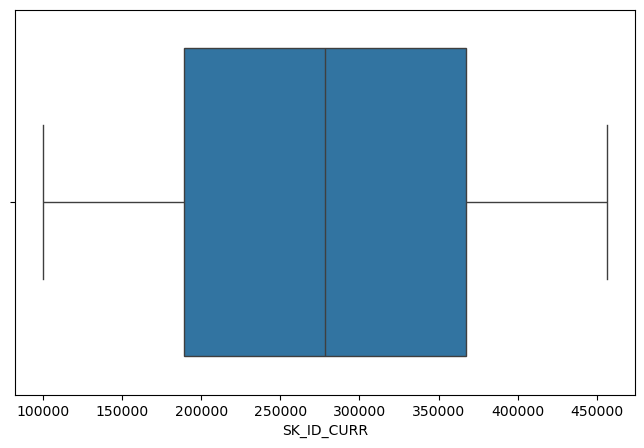

----------------------
count    307511.000000
mean          0.080729
std           0.272419
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: TARGET, dtype: float64


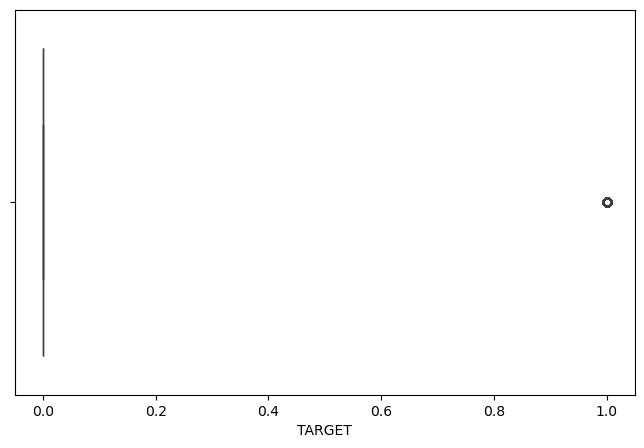

----------------------
count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64


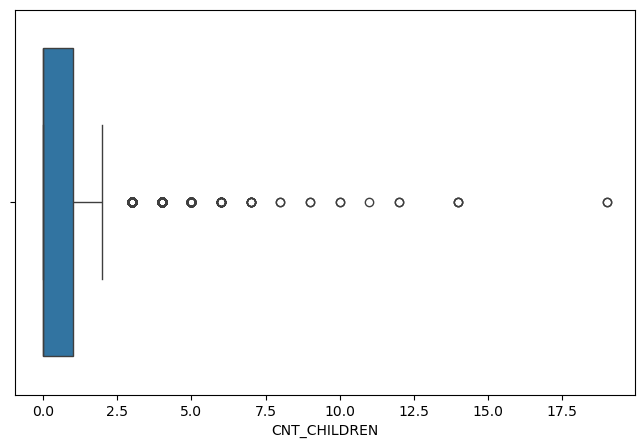

----------------------
count    307511.000000
mean      16036.995067
std        4363.988632
min        7489.000000
25%       12413.000000
50%       15750.000000
75%       19682.000000
max       25229.000000
Name: DAYS_BIRTH, dtype: float64


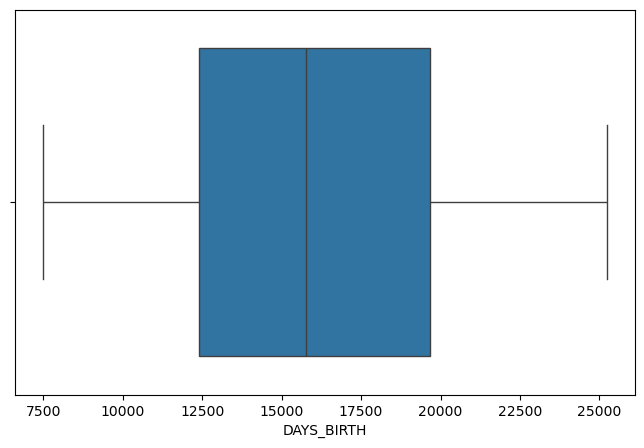

----------------------
count    307511.000000
mean      67724.742149
std      139443.751806
min           0.000000
25%         933.000000
50%        2219.000000
75%        5707.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


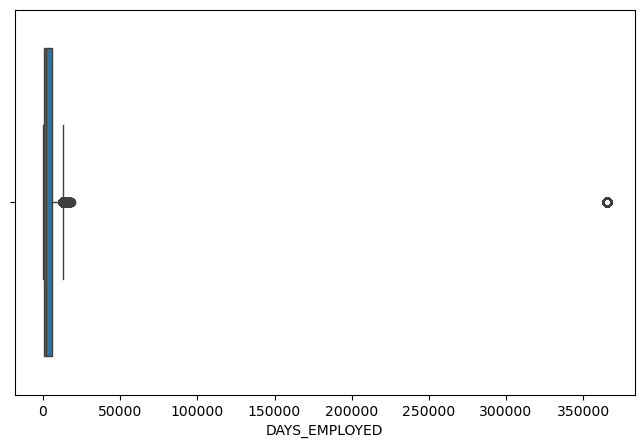

----------------------
count    307511.000000
mean       2994.202373
std        1509.450419
min           0.000000
25%        1720.000000
50%        3254.000000
75%        4299.000000
max        7197.000000
Name: DAYS_ID_PUBLISH, dtype: float64


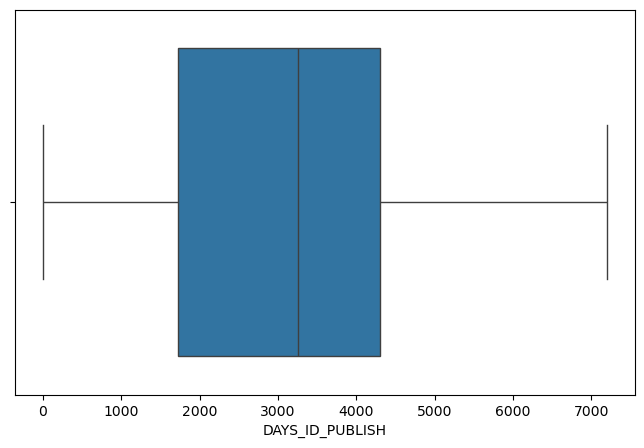

----------------------
count    307511.000000
mean          2.052463
std           0.509034
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: REGION_RATING_CLIENT, dtype: float64


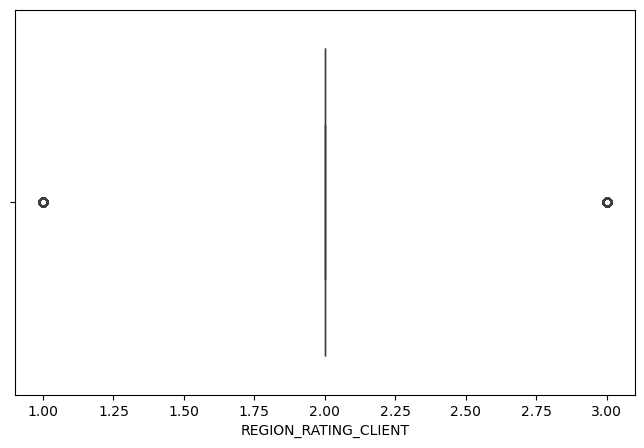

----------------------
count    307511.000000
mean          2.031521
std           0.502737
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: REGION_RATING_CLIENT_W_CITY, dtype: float64


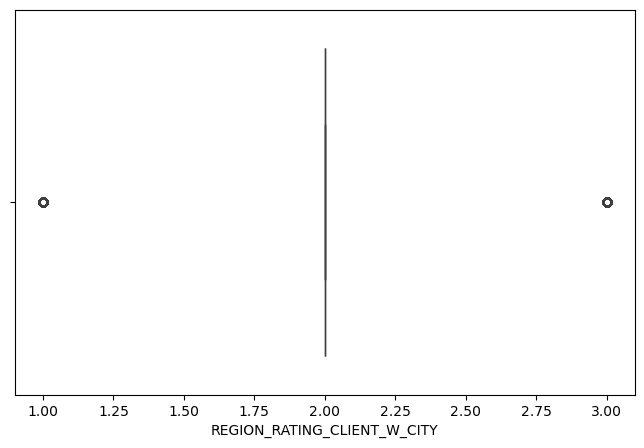

----------------------
count    307511.000000
mean         12.063419
std           3.265832
min           0.000000
25%          10.000000
50%          12.000000
75%          14.000000
max          23.000000
Name: HOUR_APPR_PROCESS_START, dtype: float64


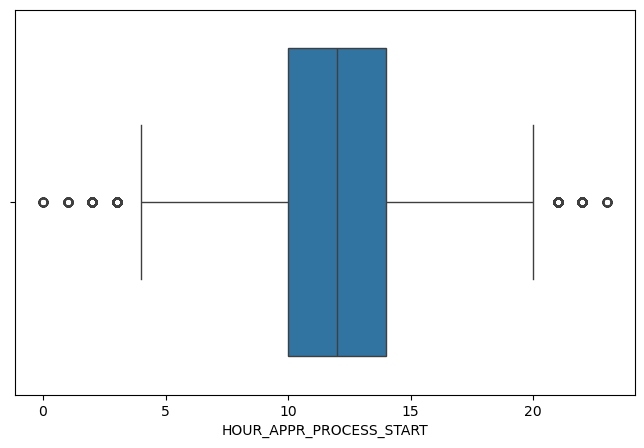

----------------------
count    307511.000000
mean          0.015144
std           0.122126
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: REG_REGION_NOT_LIVE_REGION, dtype: float64


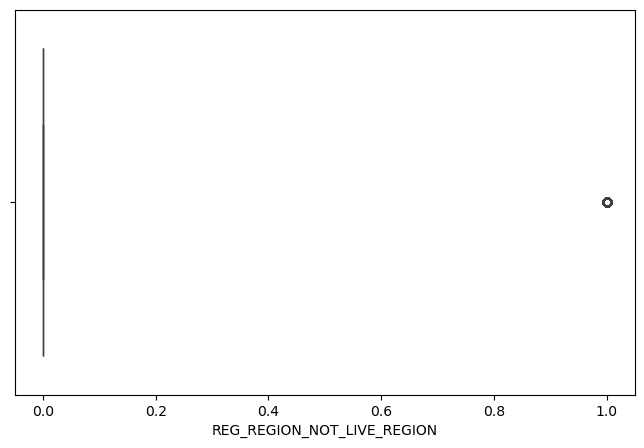

----------------------
count    307511.000000
mean          0.050769
std           0.219526
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: REG_REGION_NOT_WORK_REGION, dtype: float64


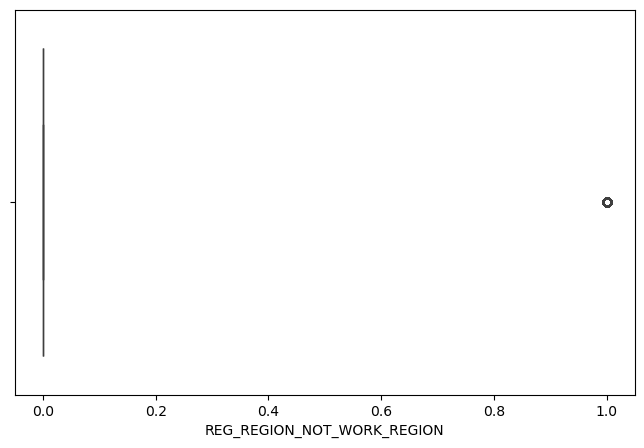

----------------------
count    307511.000000
mean          0.040659
std           0.197499
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: LIVE_REGION_NOT_WORK_REGION, dtype: float64


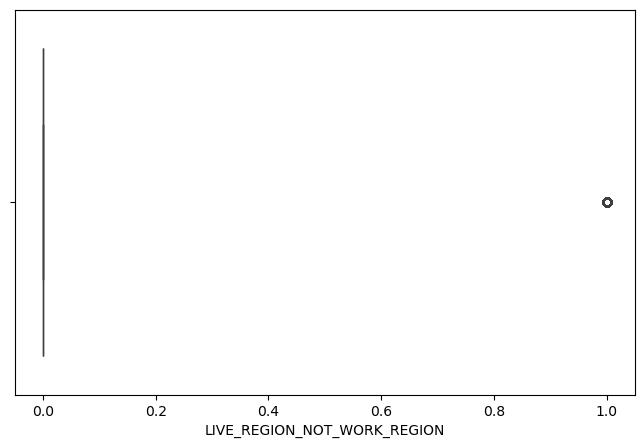

----------------------
count    307511.000000
mean          0.078173
std           0.268444
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: REG_CITY_NOT_LIVE_CITY, dtype: float64


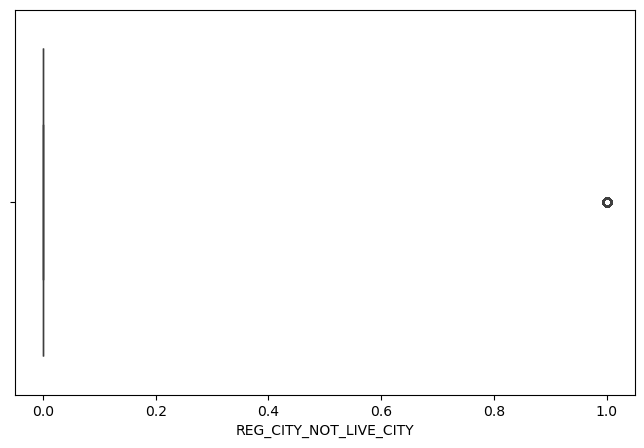

----------------------
count    307511.000000
mean          0.230454
std           0.421124
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: REG_CITY_NOT_WORK_CITY, dtype: float64


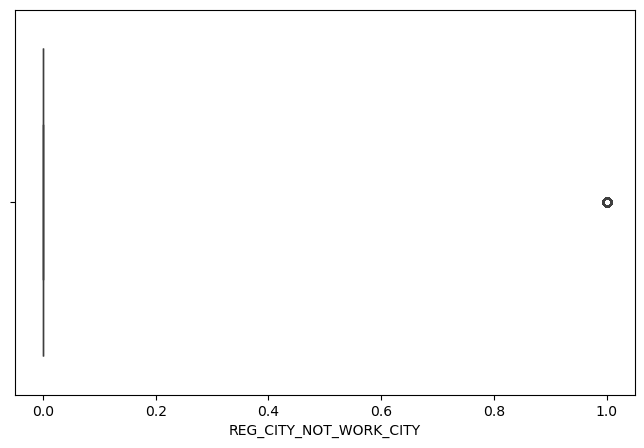

----------------------
count    307511.000000
mean          0.179555
std           0.383817
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: LIVE_CITY_NOT_WORK_CITY, dtype: float64


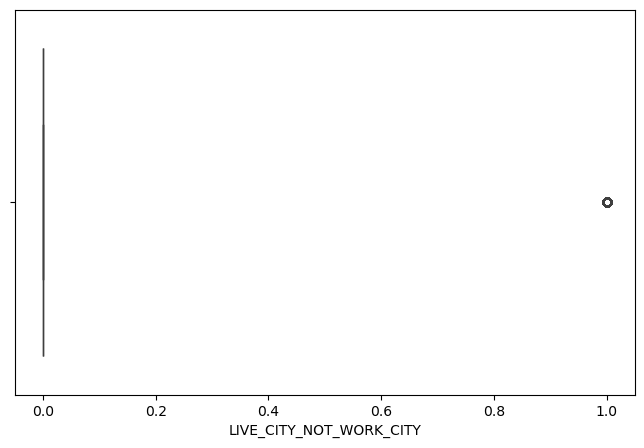

----------------------
count    307511.000000
mean         44.548992
std          12.263409
min          21.000000
25%          34.000000
50%          44.000000
75%          55.000000
max          70.000000
Name: YEARS_BIRTH, dtype: float64


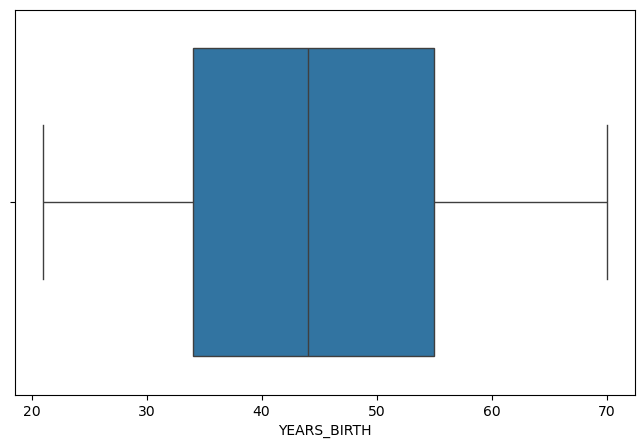

----------------------
count    307511.000000
mean        189.656025
std         391.517218
min           0.000000
25%           2.000000
50%           6.000000
75%          16.000000
max        1025.000000
Name: YEARS_EMPLOYED, dtype: float64


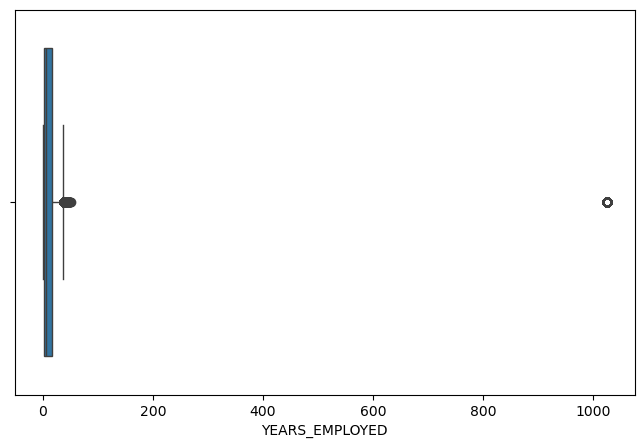

----------------------
count    307511.000000
mean         13.513478
std           9.891137
min           0.000000
25%           5.000000
50%          12.000000
75%          21.000000
max          69.000000
Name: YEARS_REGISTRATION , dtype: float64


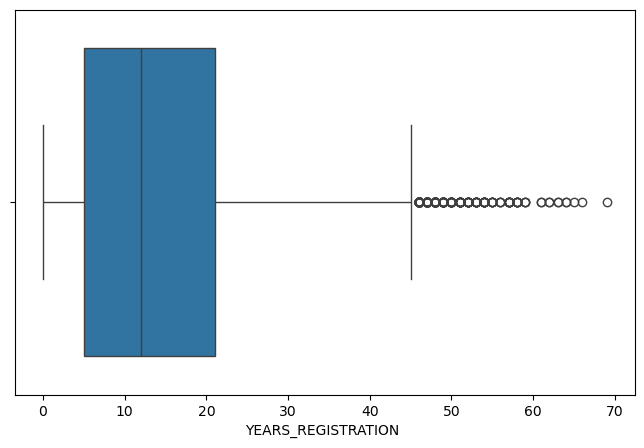

----------------------
count    307511.000000
mean          7.920845
std           4.238167
min           0.000000
25%           4.000000
50%           9.000000
75%          12.000000
max          20.000000
Name: YEARS_ID_PUBLISH , dtype: float64


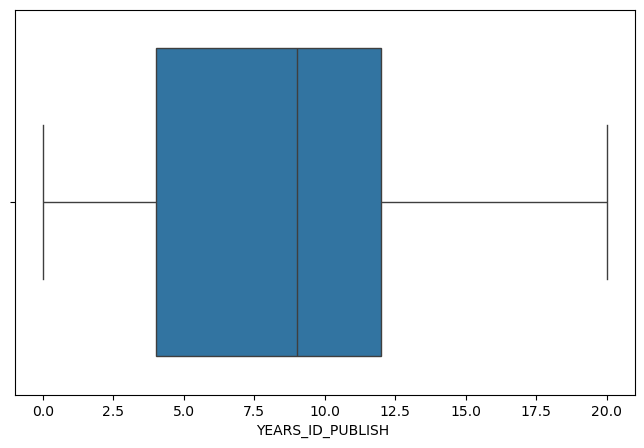

----------------------
count    307511.000000
mean          2.293102
std           2.249671
min           0.000000
25%           0.000000
50%           2.000000
75%           4.000000
max          12.000000
Name: YEARS_LAST_PHONE_CHANGE, dtype: float64


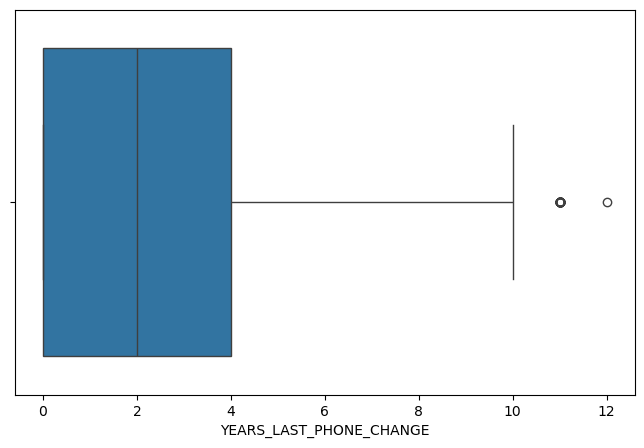

----------------------
count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


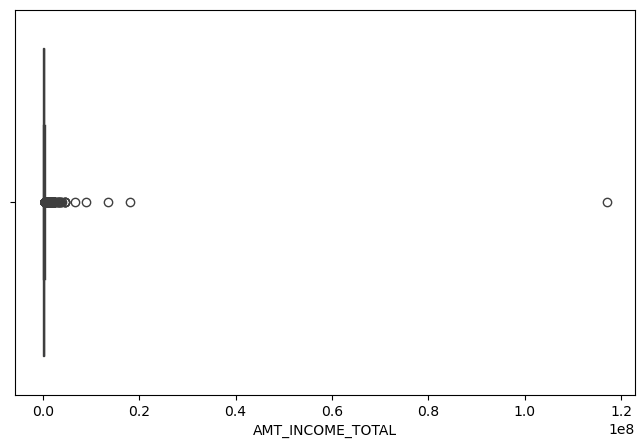

----------------------
count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64


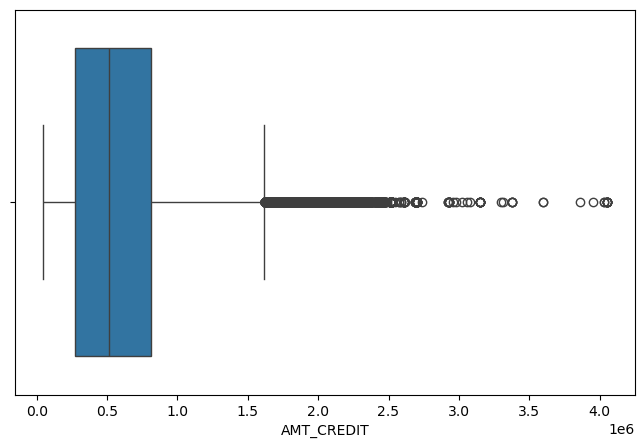

----------------------
count    307511.000000
mean      27108.487841
std       14493.461065
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64


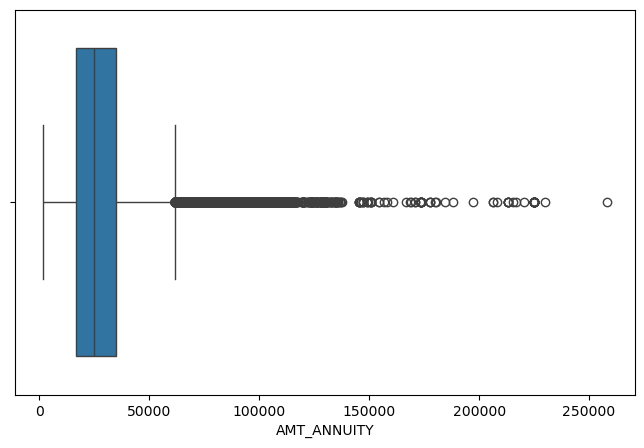

----------------------
count    3.075110e+05
mean     5.383163e+05
std      3.692890e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64


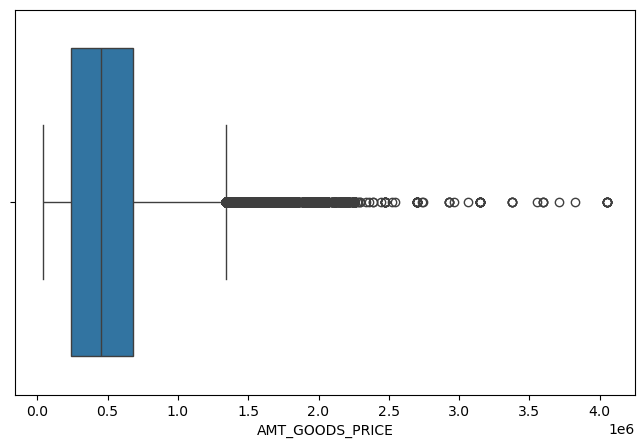

----------------------
count    307511.000000
mean          0.020868
std           0.013831
min           0.000290
25%           0.010006
50%           0.018850
75%           0.028663
max           0.072508
Name: REGION_POPULATION_RELATIVE, dtype: float64


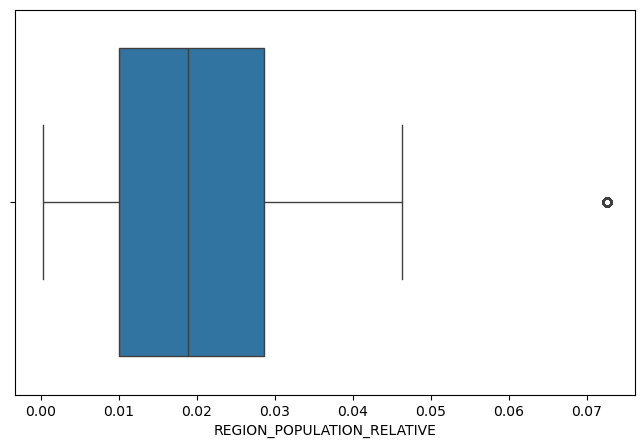

----------------------
count    307511.000000
mean       4986.120328
std        3522.886321
min           0.000000
25%        2010.000000
50%        4504.000000
75%        7479.500000
max       24672.000000
Name: DAYS_REGISTRATION, dtype: float64


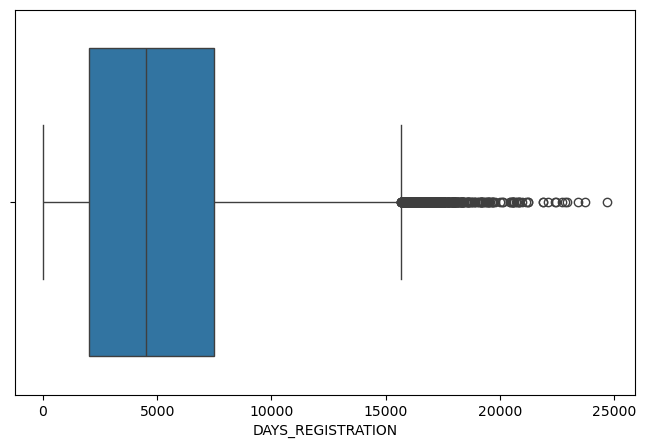

----------------------
count    307511.000000
mean          2.152664
std           0.910679
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64


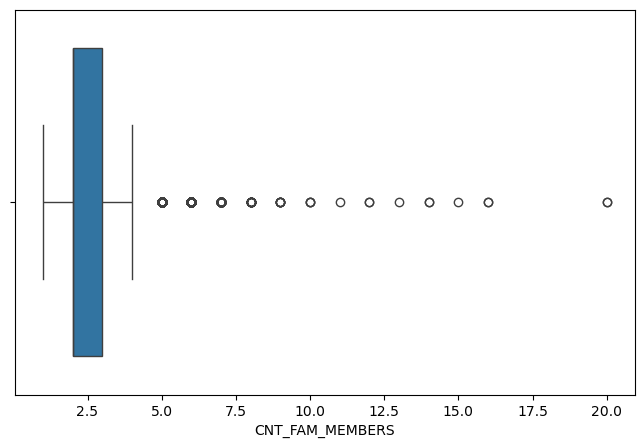

----------------------
count    307511.000000
mean          0.419922
std           0.157033
min           0.014568
25%           0.356323
50%           0.356323
75%           0.456261
max           0.962693
Name: EXT_SOURCE_1, dtype: float64


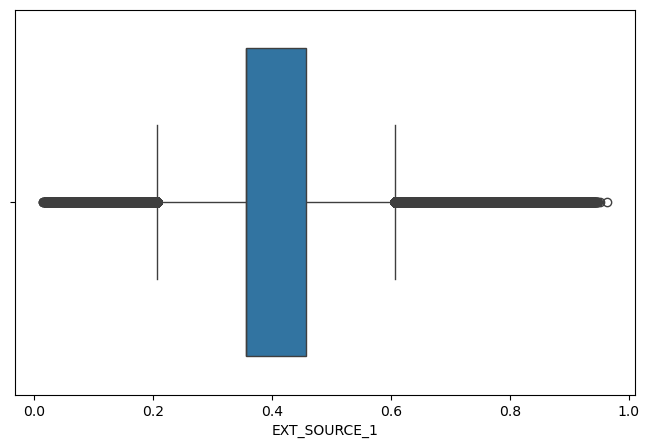

----------------------
count    3.075110e+05
mean     5.145034e-01
std      1.908699e-01
min      8.173617e-08
25%      3.929737e-01
50%      5.659614e-01
75%      6.634218e-01
max      8.549997e-01
Name: EXT_SOURCE_2, dtype: float64


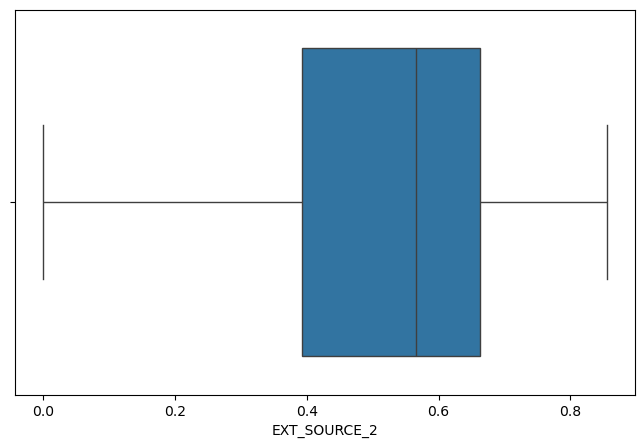

----------------------
count    307511.000000
mean          0.515695
std           0.174736
min           0.000527
25%           0.417100
50%           0.535276
75%           0.636376
max           0.896010
Name: EXT_SOURCE_3, dtype: float64


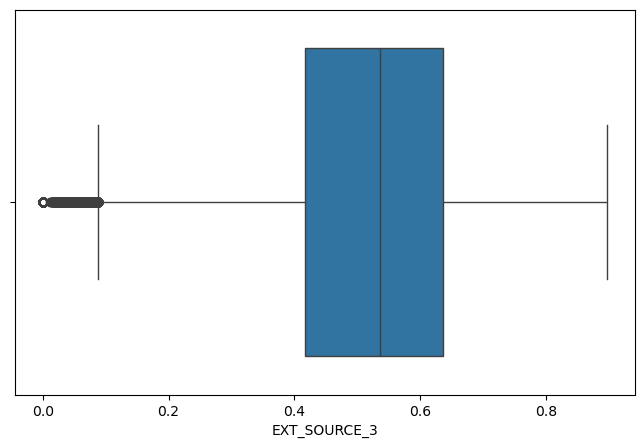

----------------------
count    307511.000000
mean          0.099708
std           0.077944
min           0.000000
25%           0.082500
50%           0.082500
75%           0.085600
max           1.000000
Name: APARTMENTS_AVG, dtype: float64


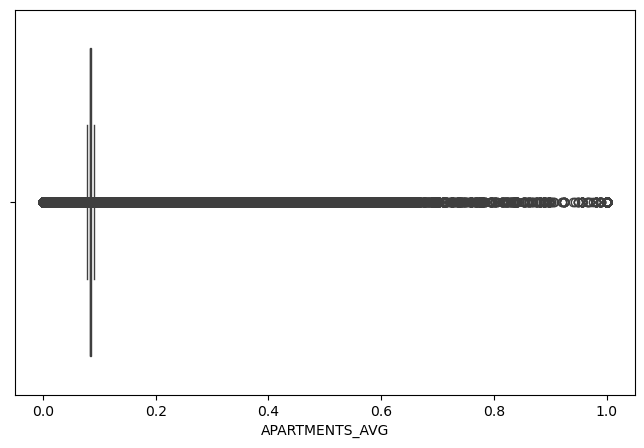

----------------------
count    307511.000000
mean          0.036689
std           0.068688
min           0.000000
25%           0.000000
50%           0.000000
75%           0.063500
max           1.000000
Name: BASEMENTAREA_AVG, dtype: float64


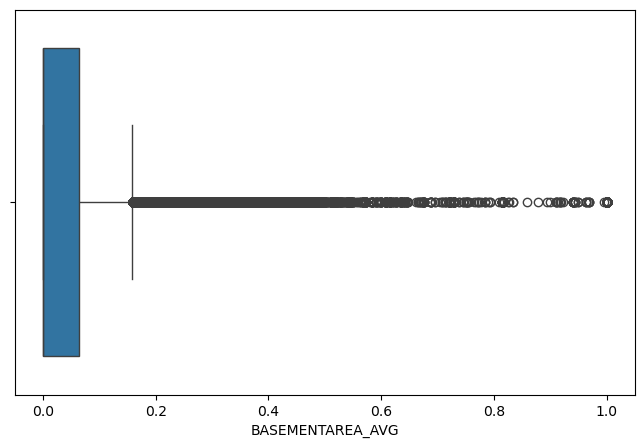

----------------------
count    307511.000000
mean          0.982303
std           0.042642
min           0.000000
25%           0.981600
50%           0.987100
75%           0.987100
max           1.000000
Name: YEARS_BEGINEXPLUATATION_AVG, dtype: float64


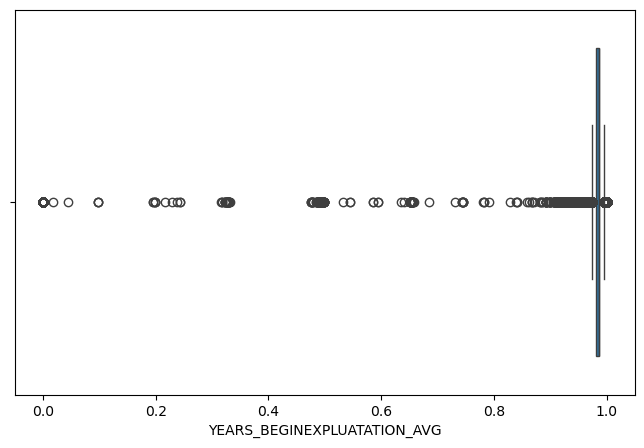

----------------------
count    307511.000000
mean          0.799504
std           0.073577
min           0.000000
25%           0.823200
50%           0.823200
75%           0.823200
max           1.000000
Name: YEARS_BUILD_AVG, dtype: float64


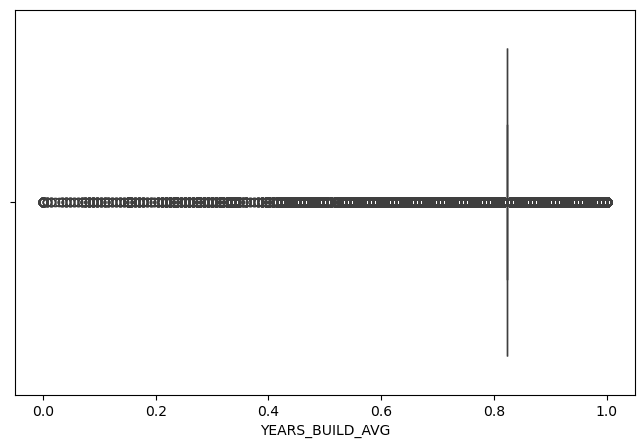

----------------------
count    307511.000000
mean          0.013443
std           0.046486
min           0.000000
25%           0.000000
50%           0.000000
75%           0.004000
max           1.000000
Name: COMMONAREA_AVG, dtype: float64


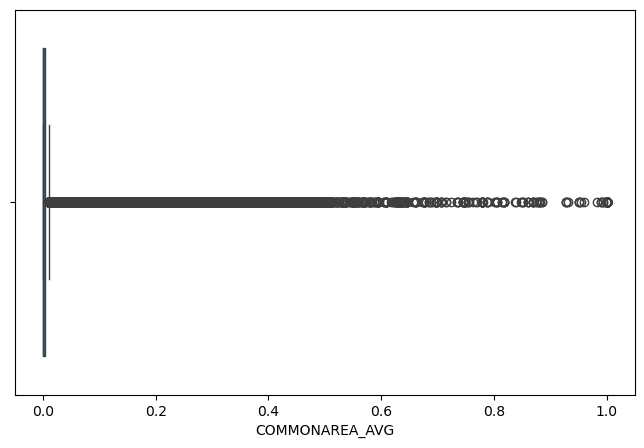

----------------------
count    307511.000000
mean          0.036869
std           0.100048
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: ELEVATORS_AVG, dtype: float64


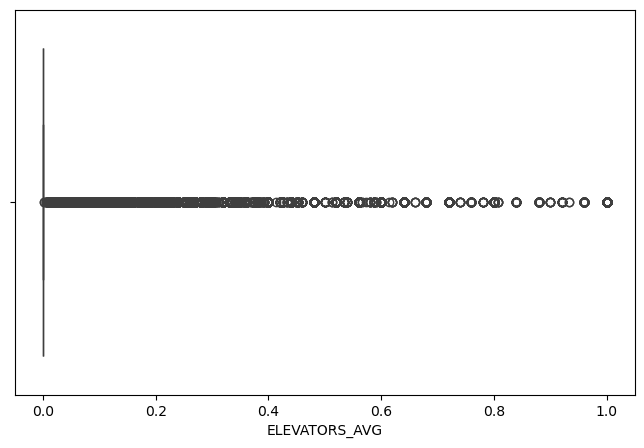

----------------------
count    307511.000000
mean          0.143771
std           0.070746
min           0.000000
25%           0.137900
50%           0.137900
75%           0.137900
max           1.000000
Name: ENTRANCES_AVG, dtype: float64


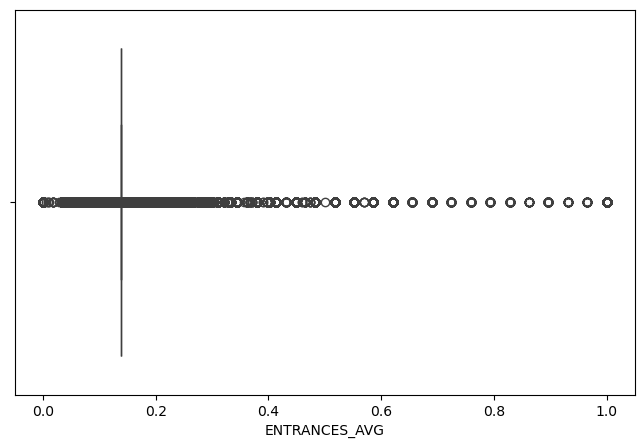

----------------------
count    307511.000000
mean          0.196633
std           0.106761
min           0.000000
25%           0.166700
50%           0.166700
75%           0.166700
max           1.000000
Name: FLOORSMAX_AVG, dtype: float64


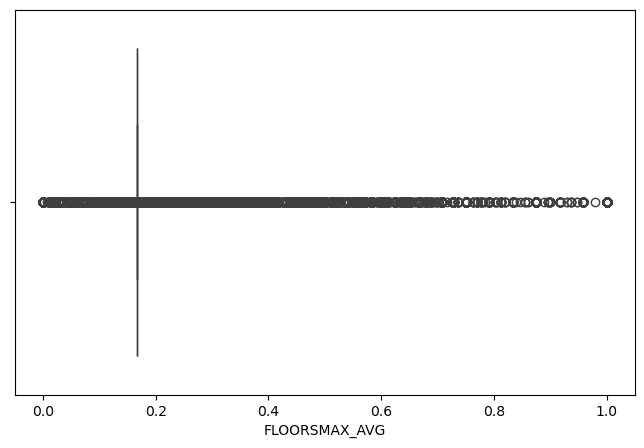

----------------------
count    307511.000000
mean          0.215886
std           0.092167
min           0.000000
25%           0.208300
50%           0.208300
75%           0.208300
max           1.000000
Name: FLOORSMIN_AVG, dtype: float64


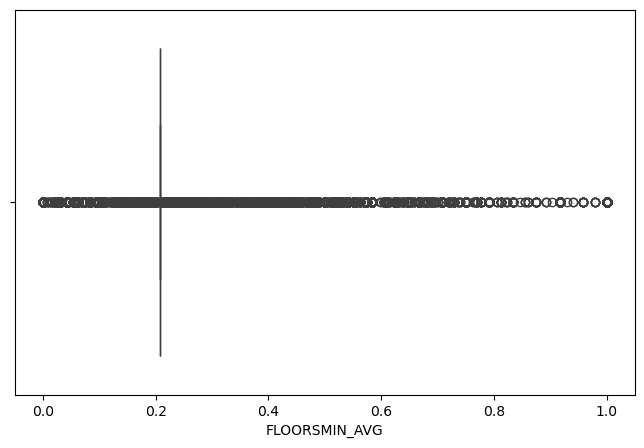

----------------------
count    307511.000000
mean          0.026947
std           0.061145
min           0.000000
25%           0.000000
50%           0.000000
75%           0.033800
max           1.000000
Name: LANDAREA_AVG, dtype: float64


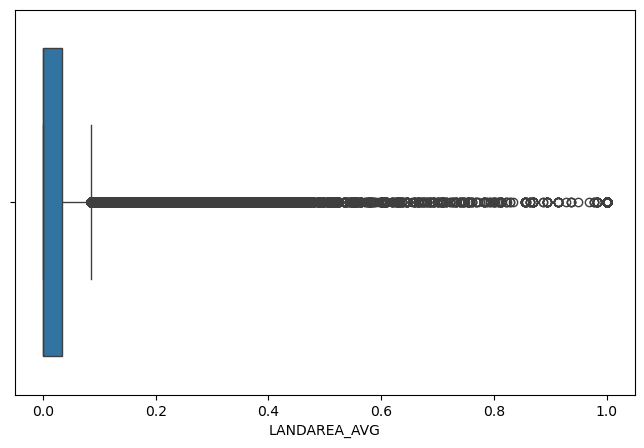

----------------------
count    307511.000000
mean          0.066341
std           0.057105
min           0.000000
25%           0.050400
50%           0.050400
75%           0.050400
max           1.000000
Name: LIVINGAPARTMENTS_AVG, dtype: float64


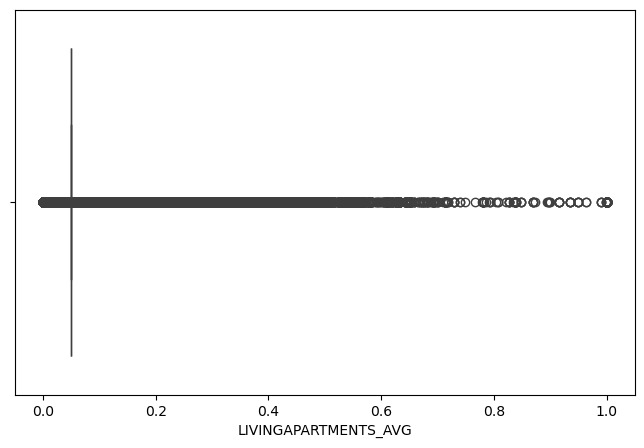

----------------------
count    307511.000000
mean          0.053492
std           0.094722
min           0.000000
25%           0.000000
50%           0.000000
75%           0.074100
max           1.000000
Name: LIVINGAREA_AVG, dtype: float64


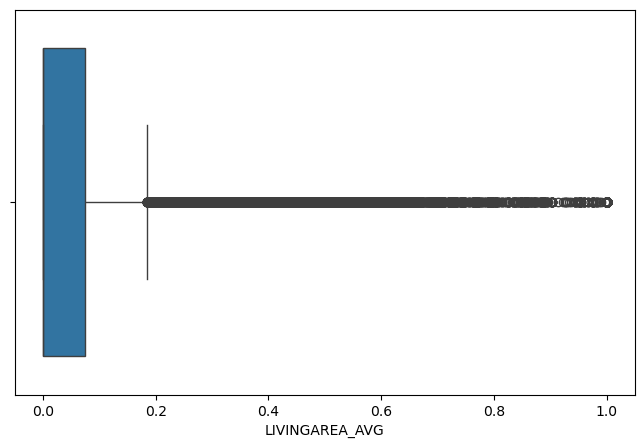

----------------------
count    307511.000000
mean          0.002693
std           0.026700
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: NONLIVINGAPARTMENTS_AVG, dtype: float64


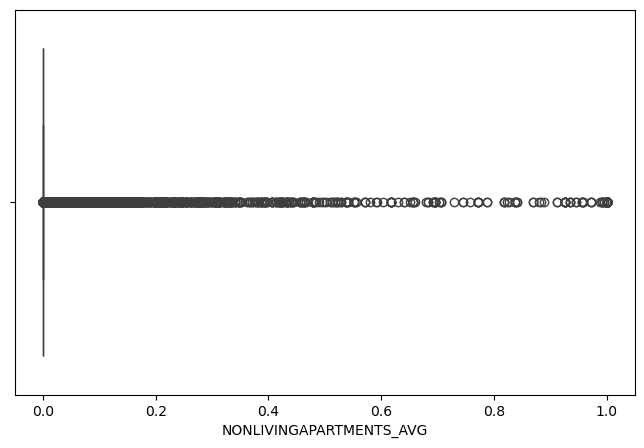

----------------------
count    307511.000000
mean          0.012710
std           0.048634
min           0.000000
25%           0.000000
50%           0.000000
75%           0.001100
max           1.000000
Name: NONLIVINGAREA_AVG, dtype: float64


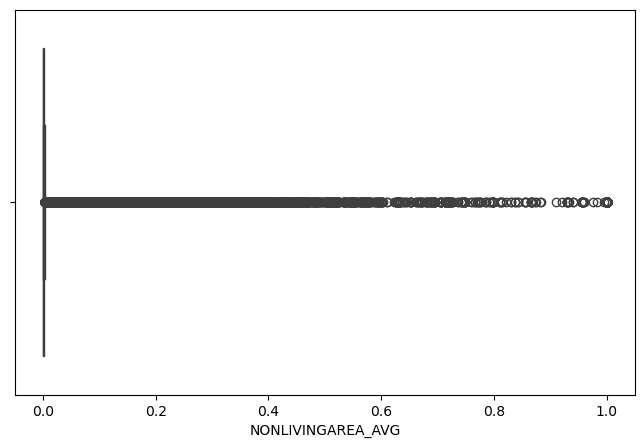

----------------------
count    307511.000000
mean          0.098889
std           0.077241
min           0.000000
25%           0.084000
50%           0.084000
75%           0.084000
max           1.000000
Name: APARTMENTS_MODE, dtype: float64


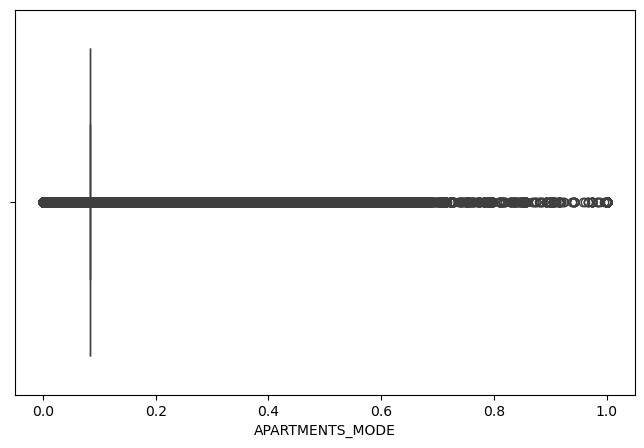

----------------------
count    307511.000000
mean          0.036316
std           0.069346
min           0.000000
25%           0.000000
50%           0.000000
75%           0.062300
max           1.000000
Name: BASEMENTAREA_MODE, dtype: float64


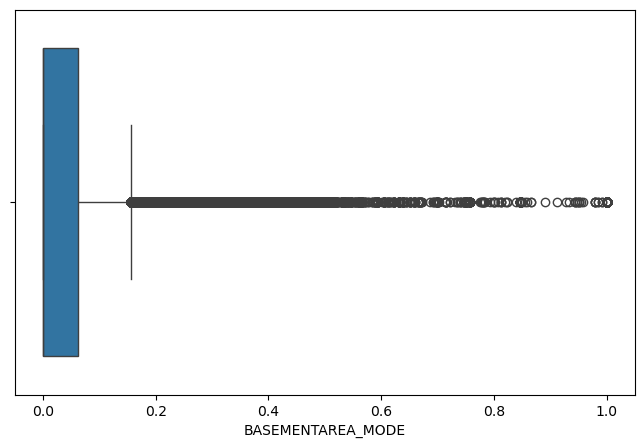

----------------------
count    307511.000000
mean          0.981960
std           0.046486
min           0.000000
25%           0.981100
50%           0.987100
75%           0.987100
max           1.000000
Name: YEARS_BEGINEXPLUATATION_MODE, dtype: float64


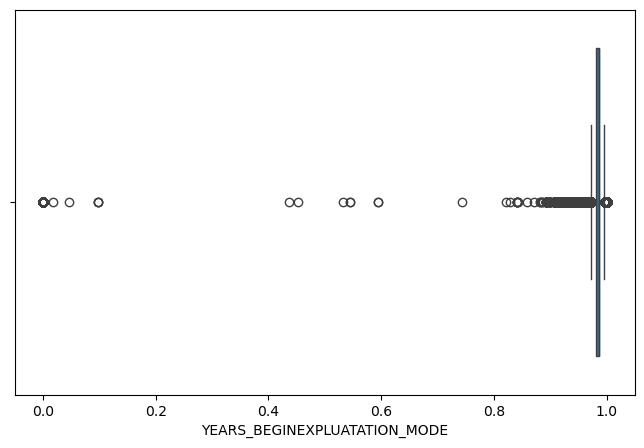

----------------------
count    307511.000000
mean          0.806493
std           0.071889
min           0.000000
25%           0.823600
50%           0.830100
75%           0.830100
max           1.000000
Name: YEARS_BUILD_MODE, dtype: float64


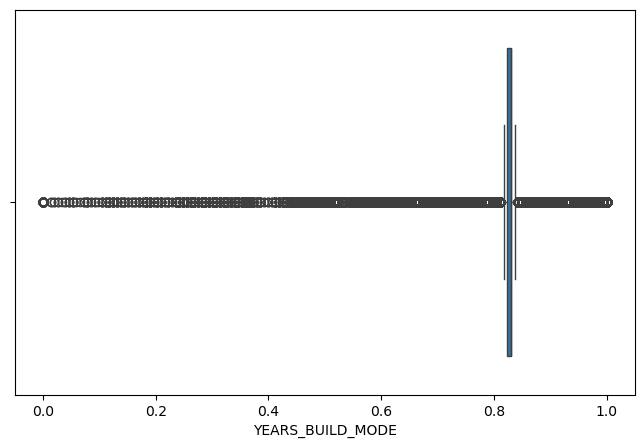

----------------------
count    307511.000000
mean          0.012820
std           0.045286
min           0.000000
25%           0.000000
50%           0.000000
75%           0.003100
max           1.000000
Name: COMMONAREA_MODE, dtype: float64


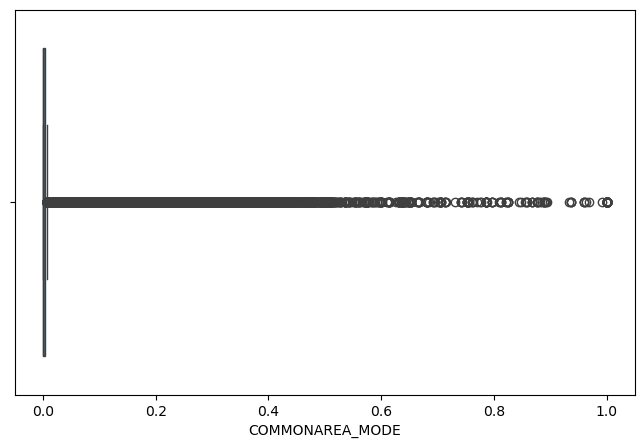

----------------------
count    307511.000000
mean          0.034790
std           0.097726
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: ELEVATORS_MODE, dtype: float64


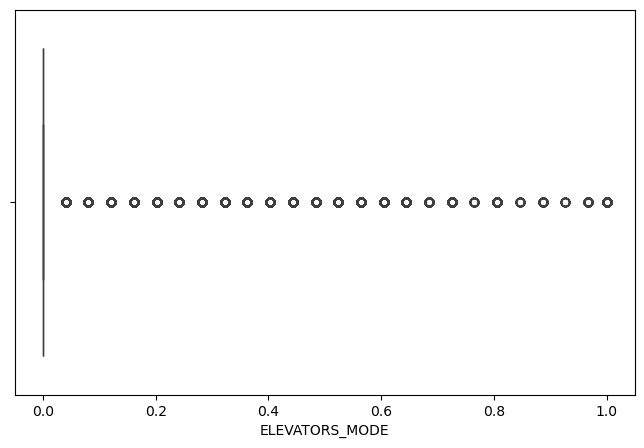

----------------------
count    307511.000000
mean          0.141521
std           0.071245
min           0.000000
25%           0.137900
50%           0.137900
75%           0.137900
max           1.000000
Name: ENTRANCES_MODE, dtype: float64


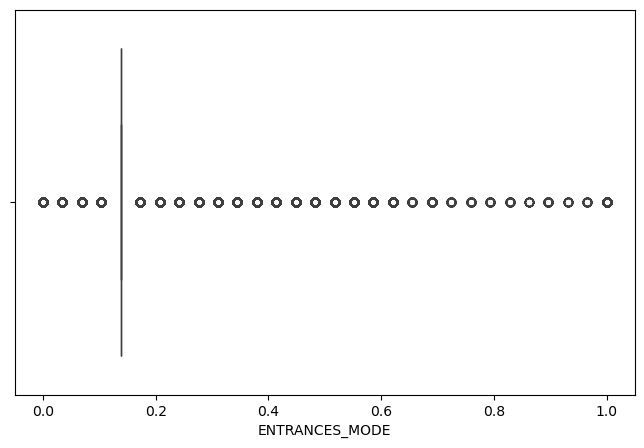

----------------------
count    307511.000000
mean          0.194641
std           0.105588
min           0.000000
25%           0.166700
50%           0.166700
75%           0.166700
max           1.000000
Name: FLOORSMAX_MODE, dtype: float64


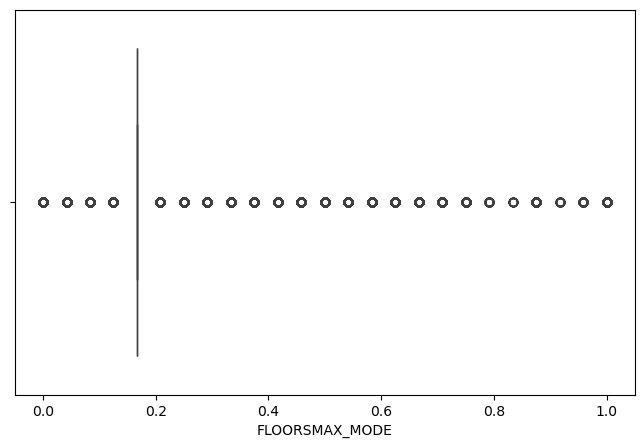

----------------------
count    307511.000000
mean          0.214653
std           0.091846
min           0.000000
25%           0.208300
50%           0.208300
75%           0.208300
max           1.000000
Name: FLOORSMIN_MODE, dtype: float64


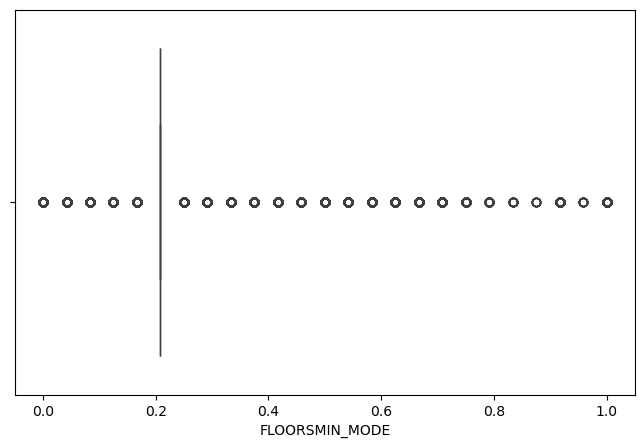

----------------------
count    307511.000000
mean          0.026388
std           0.061096
min           0.000000
25%           0.000000
50%           0.000000
75%           0.031200
max           1.000000
Name: LANDAREA_MODE, dtype: float64


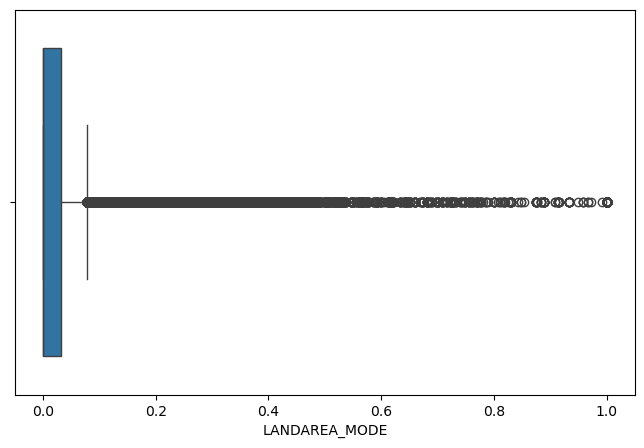

----------------------
count    307511.000000
mean          0.071095
std           0.059870
min           0.000000
25%           0.055100
50%           0.055100
75%           0.055100
max           1.000000
Name: LIVINGAPARTMENTS_MODE, dtype: float64


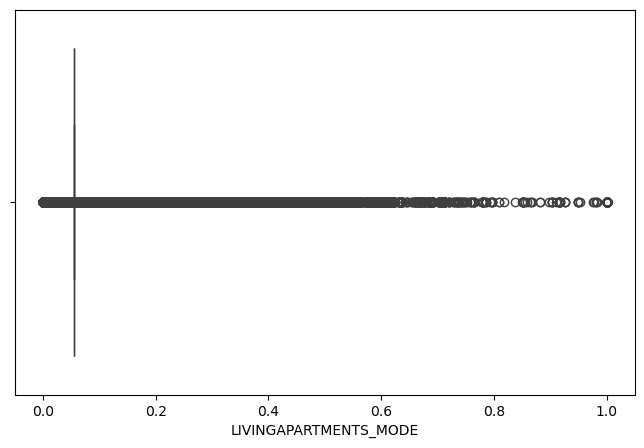

----------------------
count    307511.000000
mean          0.052783
std           0.095069
min           0.000000
25%           0.000000
50%           0.000000
75%           0.072900
max           1.000000
Name: LIVINGAREA_MODE, dtype: float64


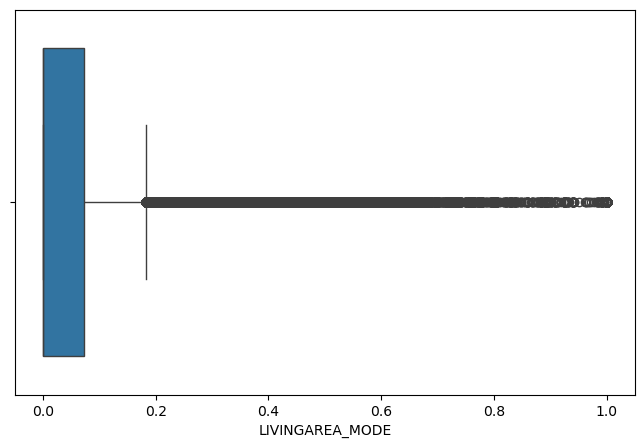

----------------------
count    307511.000000
mean          0.002469
std           0.025854
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: NONLIVINGAPARTMENTS_MODE, dtype: float64


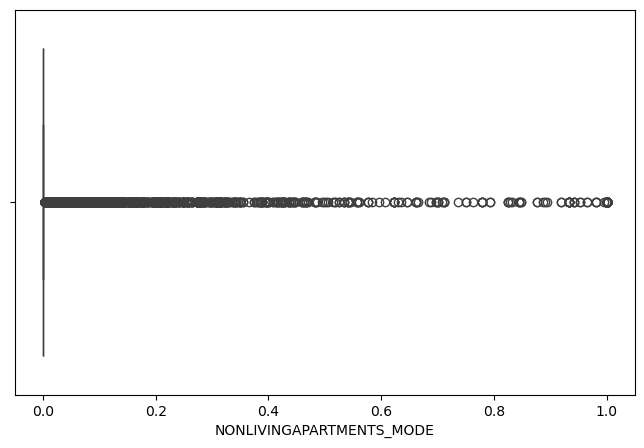

----------------------
count    307511.000000
mean          0.012112
std           0.048916
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: NONLIVINGAREA_MODE, dtype: float64


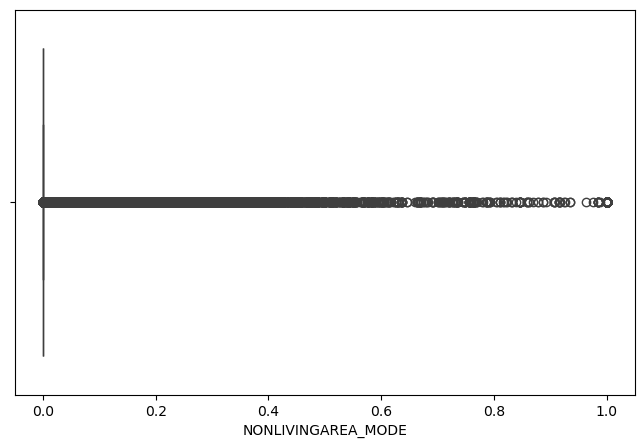

----------------------
count    307511.000000
mean          0.100316
std           0.078472
min           0.000000
25%           0.083300
50%           0.083300
75%           0.084300
max           1.000000
Name: APARTMENTS_MEDI, dtype: float64


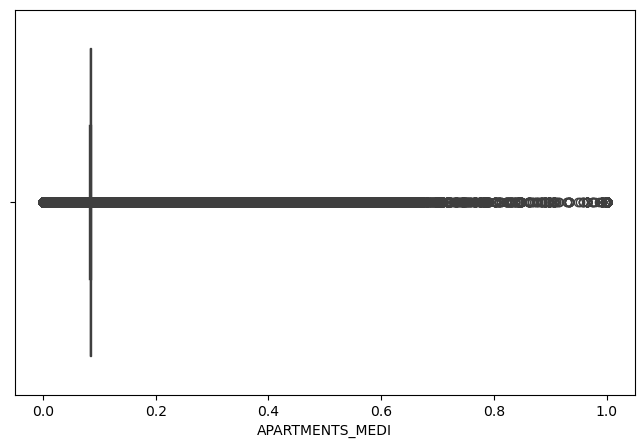

----------------------
count    307511.000000
mean          0.036487
std           0.068407
min           0.000000
25%           0.000000
50%           0.000000
75%           0.063100
max           1.000000
Name: BASEMENTAREA_MEDI, dtype: float64


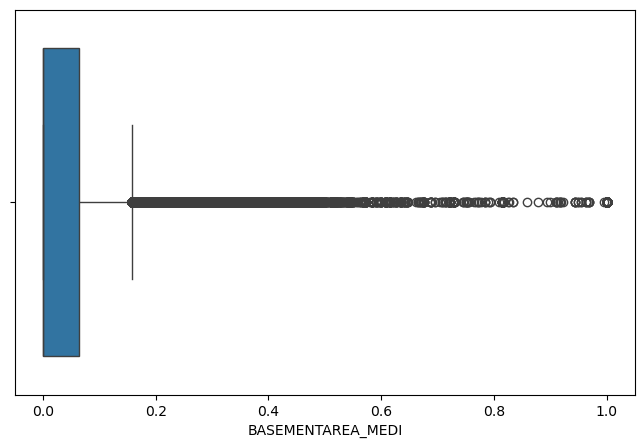

----------------------
count    307511.000000
mean          0.982312
std           0.043121
min           0.000000
25%           0.981600
50%           0.987100
75%           0.987100
max           1.000000
Name: YEARS_BEGINEXPLUATATION_MEDI, dtype: float64


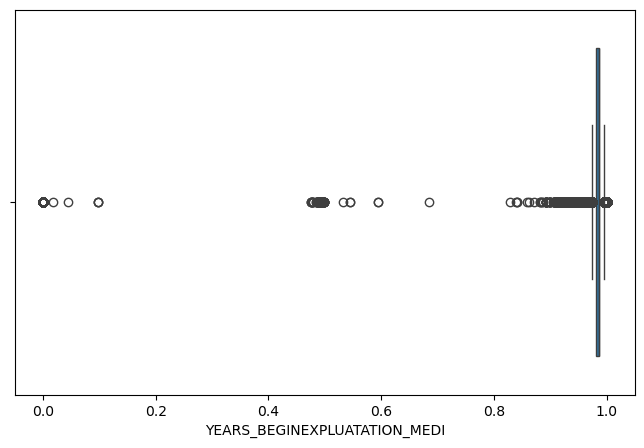

----------------------
count    307511.000000
mean          0.802197
std           0.072764
min           0.000000
25%           0.825600
50%           0.825600
75%           0.825600
max           1.000000
Name: YEARS_BUILD_MEDI, dtype: float64


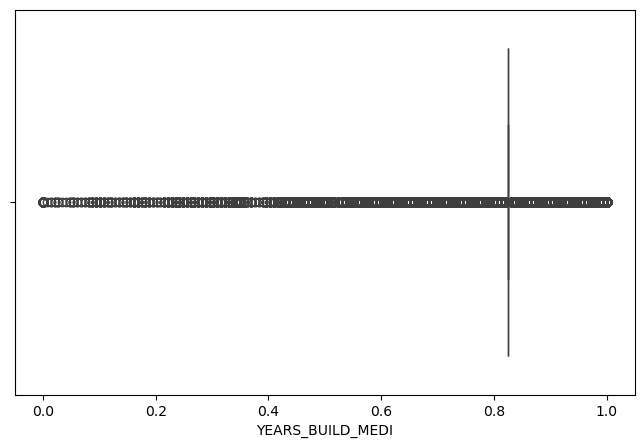

----------------------
count    307511.000000
mean          0.013435
std           0.046534
min           0.000000
25%           0.000000
50%           0.000000
75%           0.003900
max           1.000000
Name: COMMONAREA_MEDI, dtype: float64


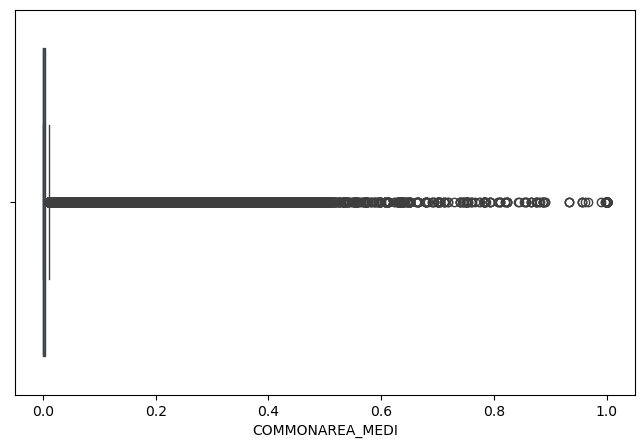

----------------------
count    307511.000000
mean          0.036465
std           0.099810
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: ELEVATORS_MEDI, dtype: float64


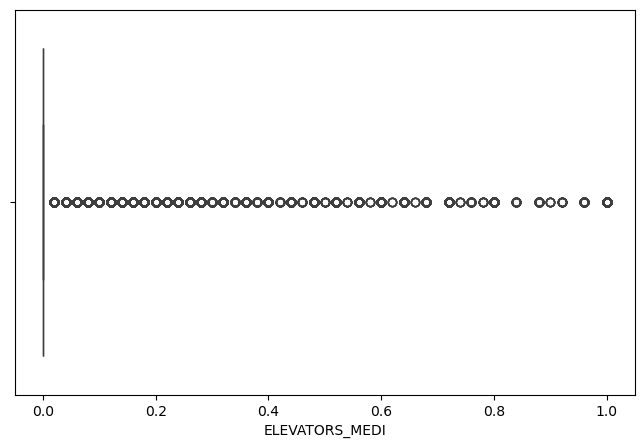

----------------------
count    307511.000000
mean          0.143517
std           0.070949
min           0.000000
25%           0.137900
50%           0.137900
75%           0.137900
max           1.000000
Name: ENTRANCES_MEDI, dtype: float64


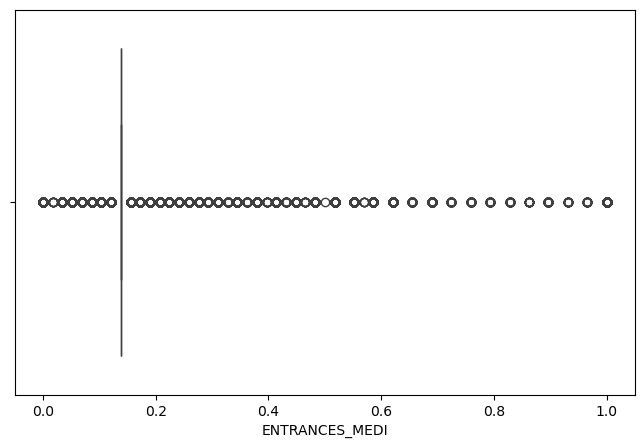

----------------------
count    307511.000000
mean          0.196440
std           0.106998
min           0.000000
25%           0.166700
50%           0.166700
75%           0.166700
max           1.000000
Name: FLOORSMAX_MEDI, dtype: float64


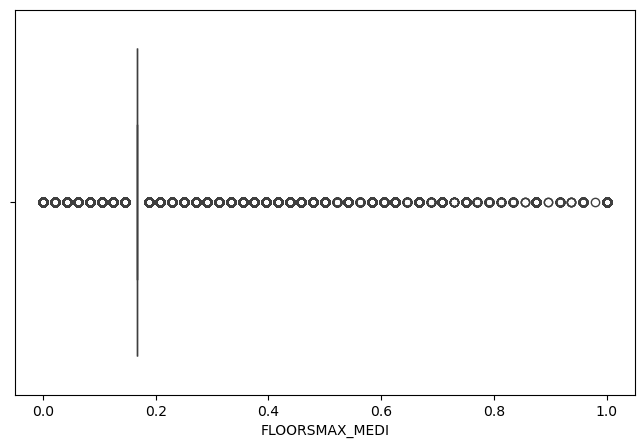

----------------------
count    307511.000000
mean          0.215799
std           0.092464
min           0.000000
25%           0.208300
50%           0.208300
75%           0.208300
max           1.000000
Name: FLOORSMIN_MEDI, dtype: float64


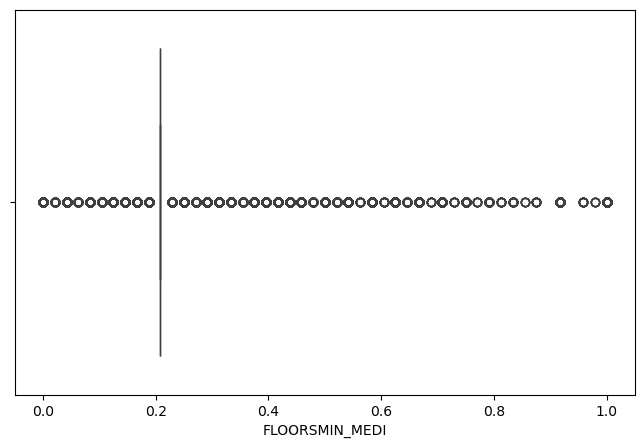

----------------------
count    307511.000000
mean          0.027286
std           0.061894
min           0.000000
25%           0.000000
50%           0.000000
75%           0.034000
max           1.000000
Name: LANDAREA_MEDI, dtype: float64


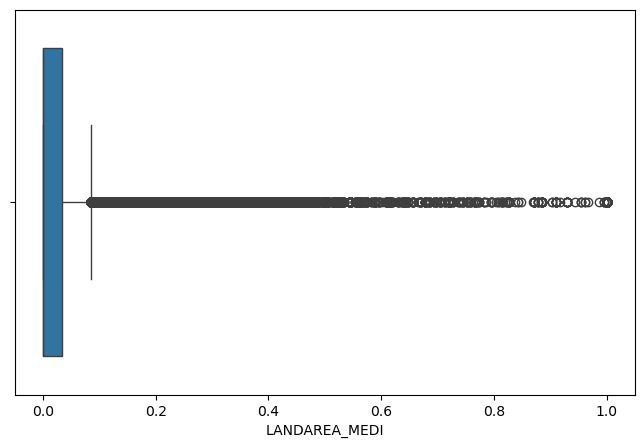

----------------------
count    307511.000000
mean          0.067330
std           0.057705
min           0.000000
25%           0.051300
50%           0.051300
75%           0.051300
max           1.000000
Name: LIVINGAPARTMENTS_MEDI, dtype: float64


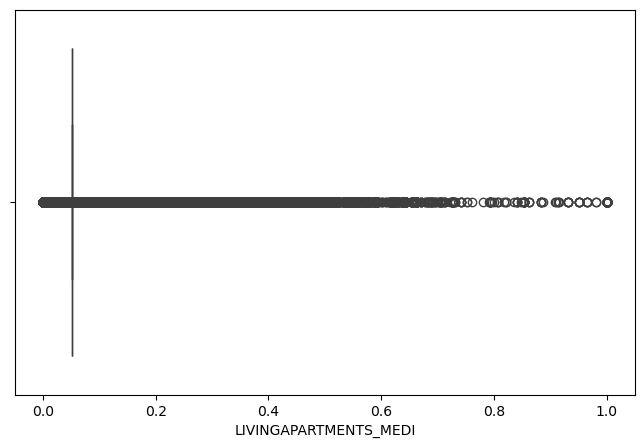

----------------------
count    307511.000000
mean          0.054093
std           0.096050
min           0.000000
25%           0.000000
50%           0.000000
75%           0.074600
max           1.000000
Name: LIVINGAREA_MEDI, dtype: float64


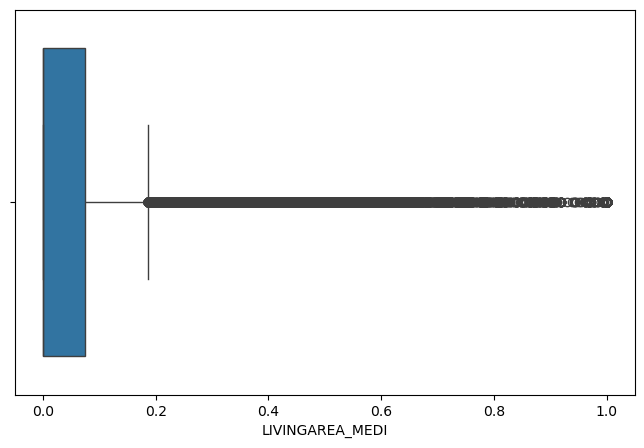

----------------------
count    307511.000000
mean          0.002644
std           0.026516
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: NONLIVINGAPARTMENTS_MEDI, dtype: float64


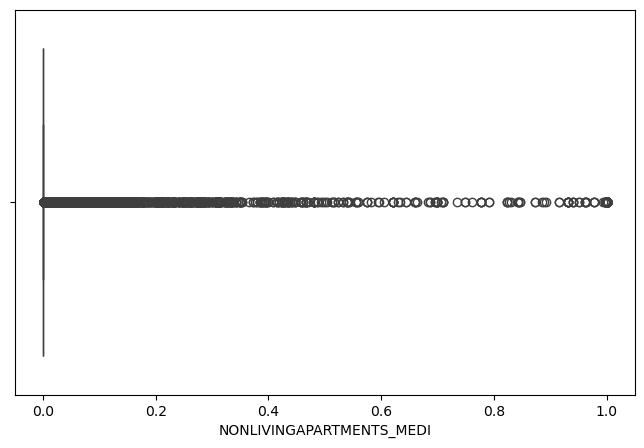

----------------------
count    307511.000000
mean          0.012656
std           0.049029
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: NONLIVINGAREA_MEDI, dtype: float64


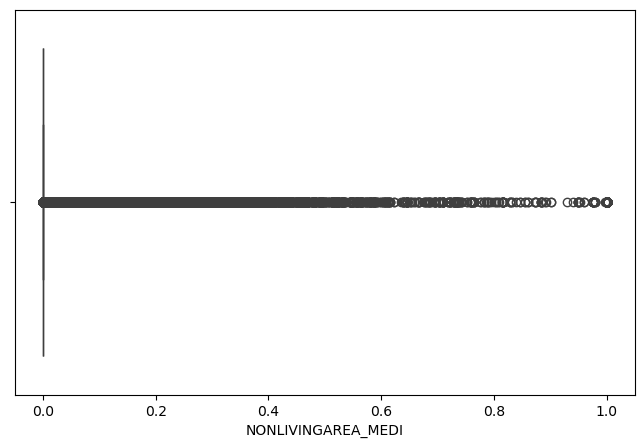

----------------------
count    307511.000000
mean          0.053049
std           0.092735
min           0.000000
25%           0.000000
50%           0.005000
75%           0.070300
max           1.000000
Name: TOTALAREA_MODE, dtype: float64


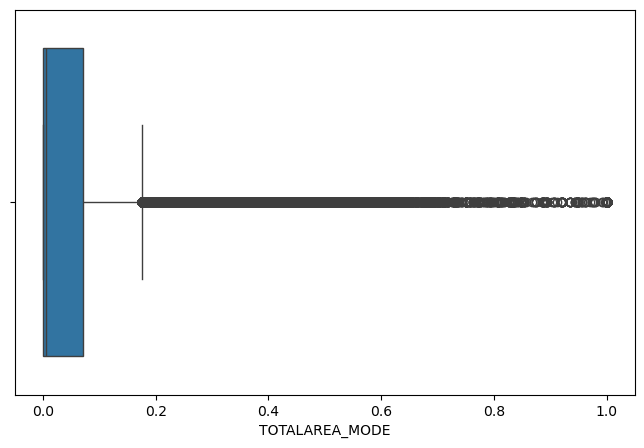

----------------------
count    307511.000000
mean          1.417523
std           2.398395
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         348.000000
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: float64


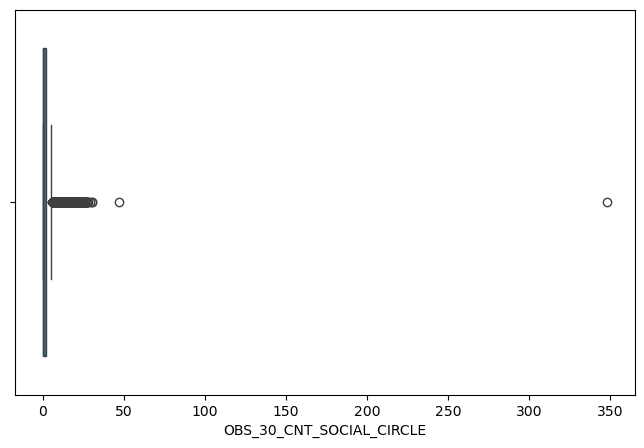

----------------------
count    307511.000000
mean          0.142944
std           0.446033
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          34.000000
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64


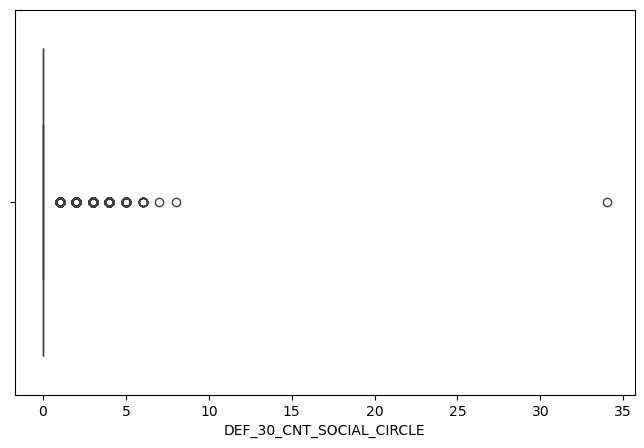

----------------------
count    307511.000000
mean          1.400626
std           2.377224
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         344.000000
Name: OBS_60_CNT_SOCIAL_CIRCLE, dtype: float64


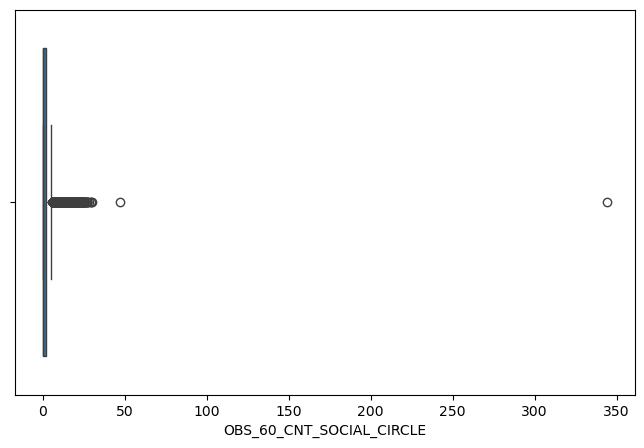

----------------------
count    307511.000000
mean          0.099717
std           0.361735
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.000000
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: float64


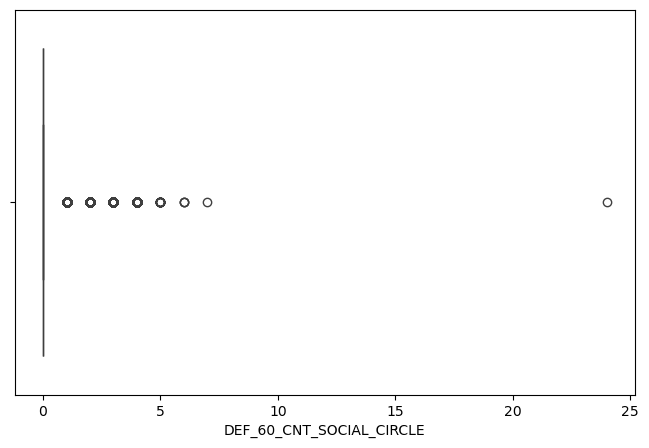

----------------------
count    307511.000000
mean        962.858119
std         826.807226
min           0.000000
25%         274.000000
50%         757.000000
75%        1570.000000
max        4292.000000
Name: DAYS_LAST_PHONE_CHANGE, dtype: float64


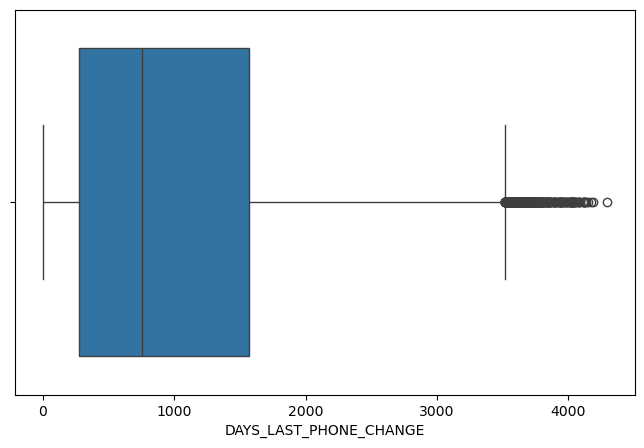

----------------------
count    307511.000000
mean          0.005538
std           0.078014
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: AMT_REQ_CREDIT_BUREAU_HOUR, dtype: float64


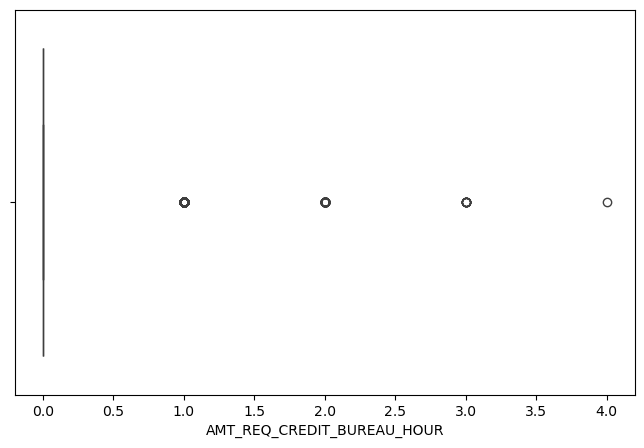

----------------------
count    307511.000000
mean          0.006055
std           0.103037
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: AMT_REQ_CREDIT_BUREAU_DAY, dtype: float64


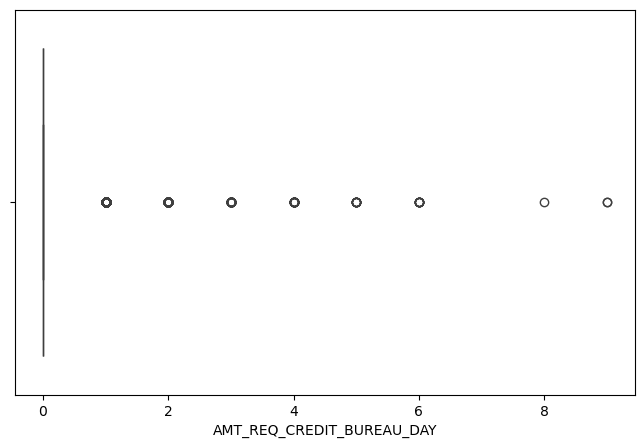

----------------------
count    307511.000000
mean          0.029723
std           0.190728
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: AMT_REQ_CREDIT_BUREAU_WEEK, dtype: float64


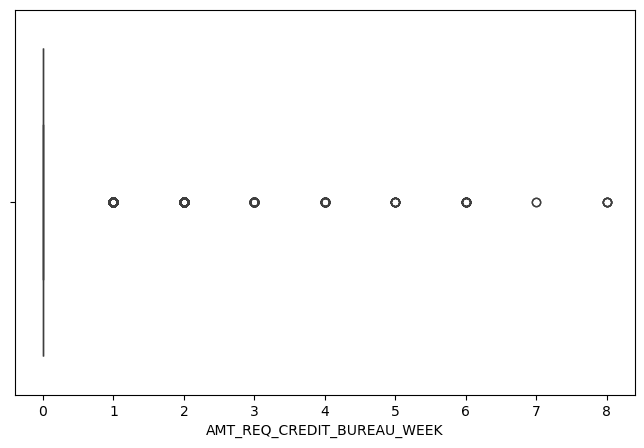

----------------------
count    307511.000000
mean          0.231293
std           0.856810
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          27.000000
Name: AMT_REQ_CREDIT_BUREAU_MON, dtype: float64


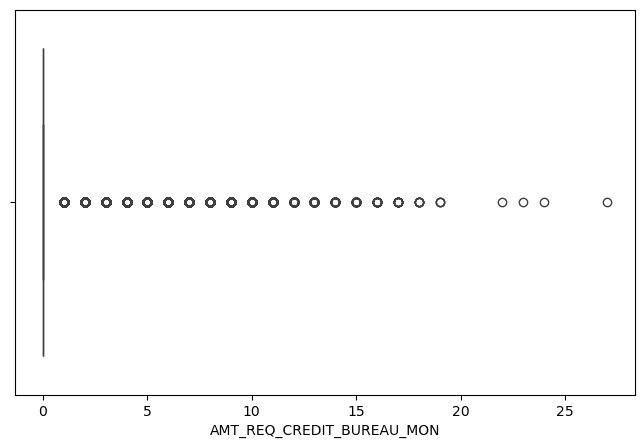

----------------------
count    307511.000000
mean          0.229631
std           0.744059
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         261.000000
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: float64


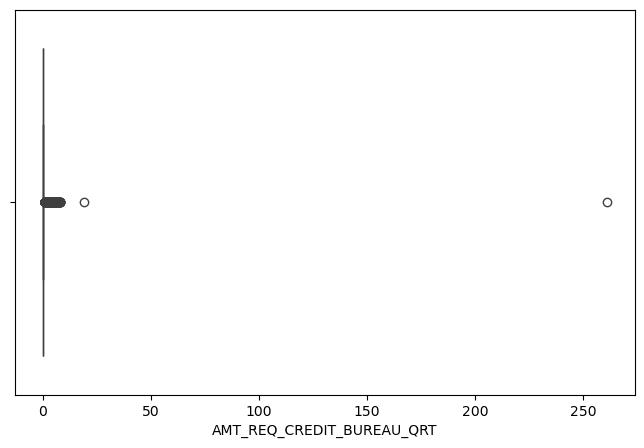

----------------------
count    307511.000000
mean          1.643447
std           1.855821
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          25.000000
Name: AMT_REQ_CREDIT_BUREAU_YEAR, dtype: float64


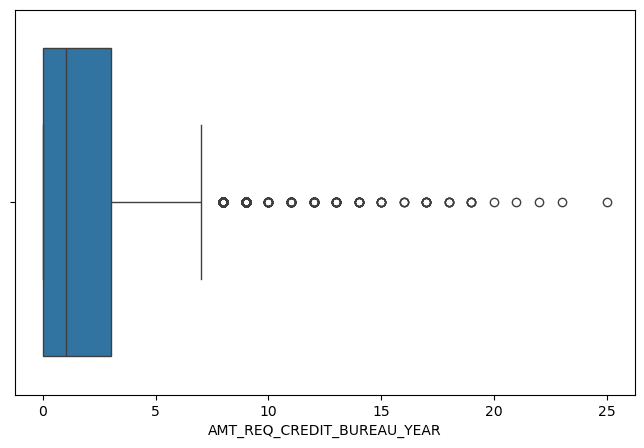

----------------------


In [327]:
for col in num_cols_withoutflag:
    print(app_df[col].describe())
    plt.figure(figsize = [8,5])
    sns.boxplot(data=app_df, x=col)
    plt.show()
    print("----------------------")
    
    

- Conclusion >> Few Columns are with outliers are below

1.AMT_INCOME_TOTAL Column has a few outliers and there is a huge difference between the 99th percentile and the max value, also we could see huge variation in mean and median due to outliers

2.AMT_CREDIT Column has a few outliers and there is a huge difference between the 99th percentile and the max value, also we could see huge variation in mean and median due to outliers

3.AMT_ANNUITY Column has a few outliers and there is a huge difference between the 99th percentile and the max value, also we could see significant variation in mean and median due to outliers

4.AMT_GOODS_PRICE Column has a few outliers and there is a huge difference between the 99th percentile and the max value, also we could see significant variation in mean and median due to outliers

5.REGION_POPULATION_RELATIVE Column has one outlier and there [is] not much difference between mean and median

### Univariate Analysis on Columns with Target 0 and 1

Plot on NAME_CONTRACT_TYPE for Target 0 and 1


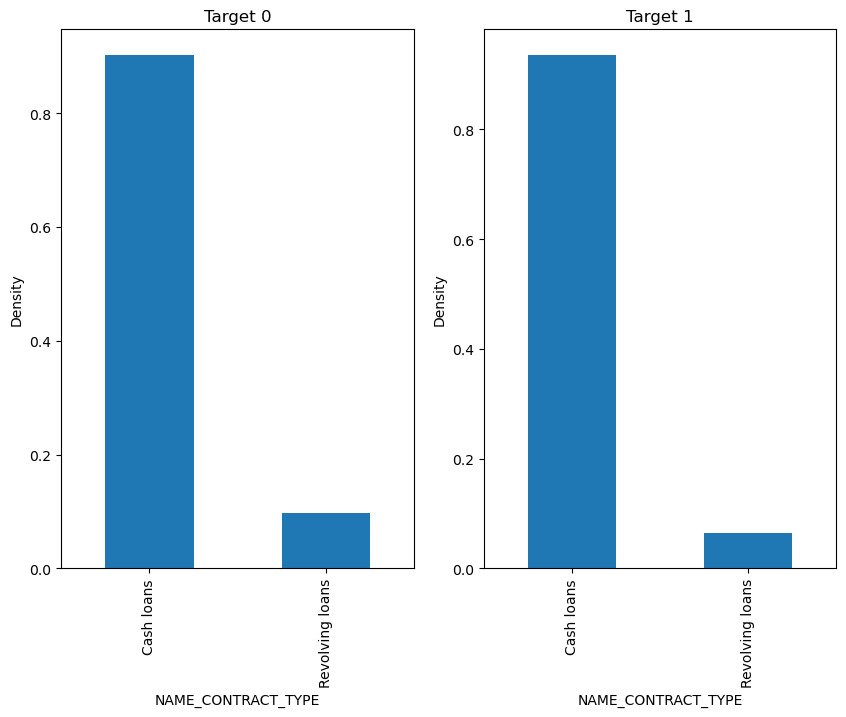



 ------------------------------------------------------------ 


Plot on CODE_GENDER for Target 0 and 1


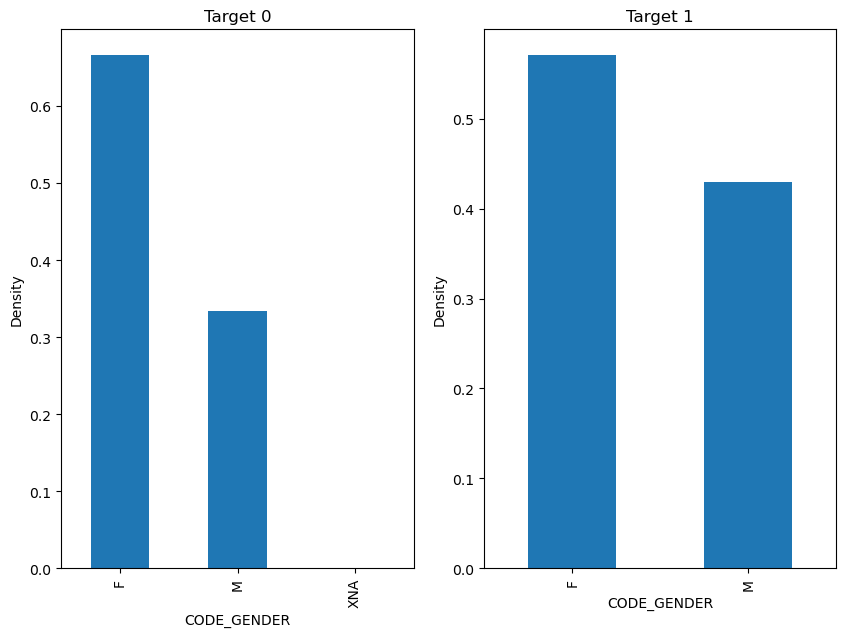



 ------------------------------------------------------------ 


Plot on FLAG_OWN_CAR for Target 0 and 1


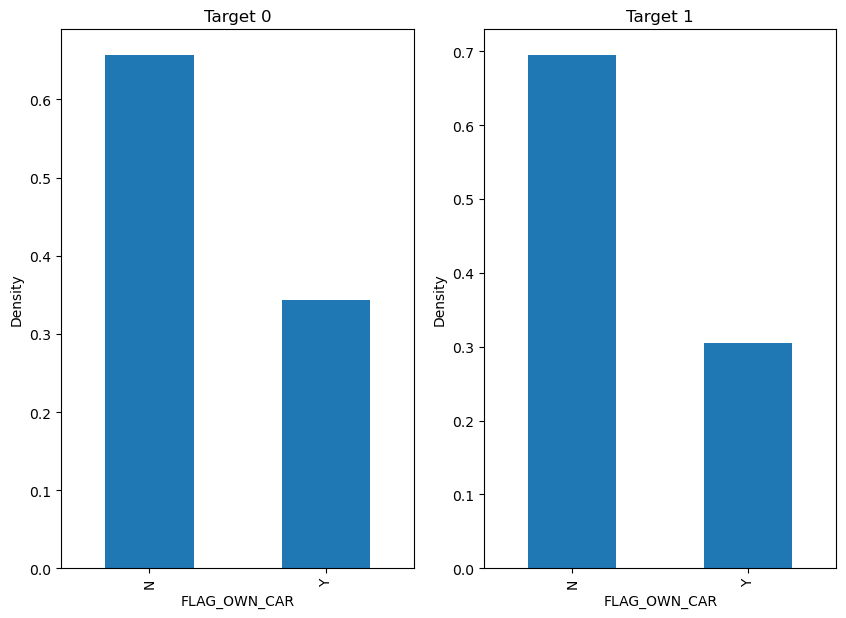



 ------------------------------------------------------------ 


Plot on FLAG_OWN_REALTY for Target 0 and 1


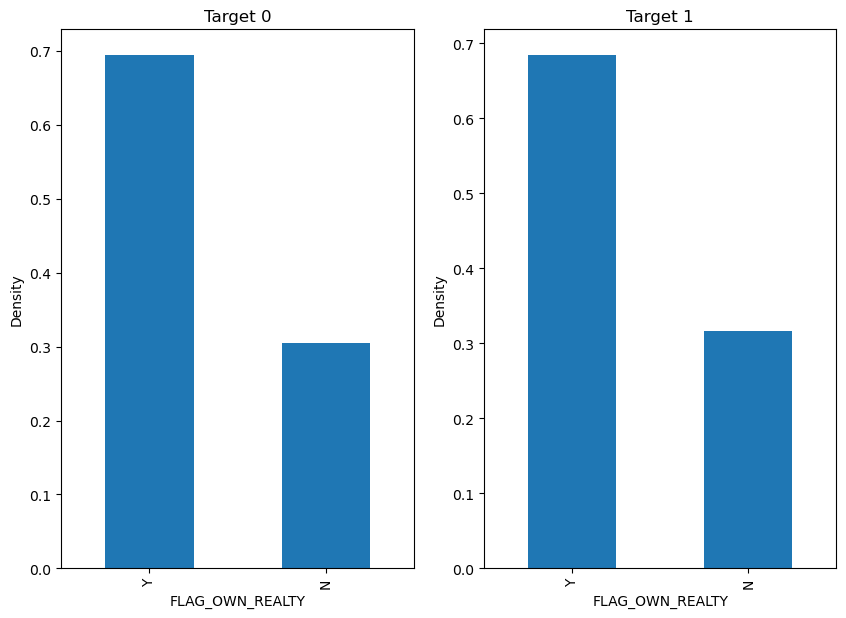



 ------------------------------------------------------------ 


Plot on NAME_TYPE_SUITE for Target 0 and 1


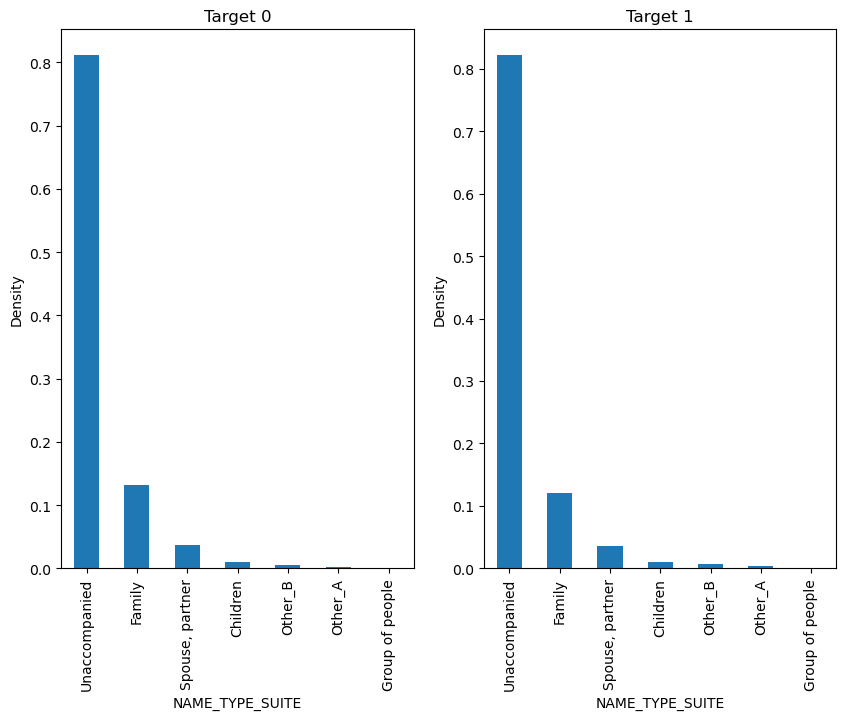



 ------------------------------------------------------------ 


Plot on NAME_INCOME_TYPE for Target 0 and 1


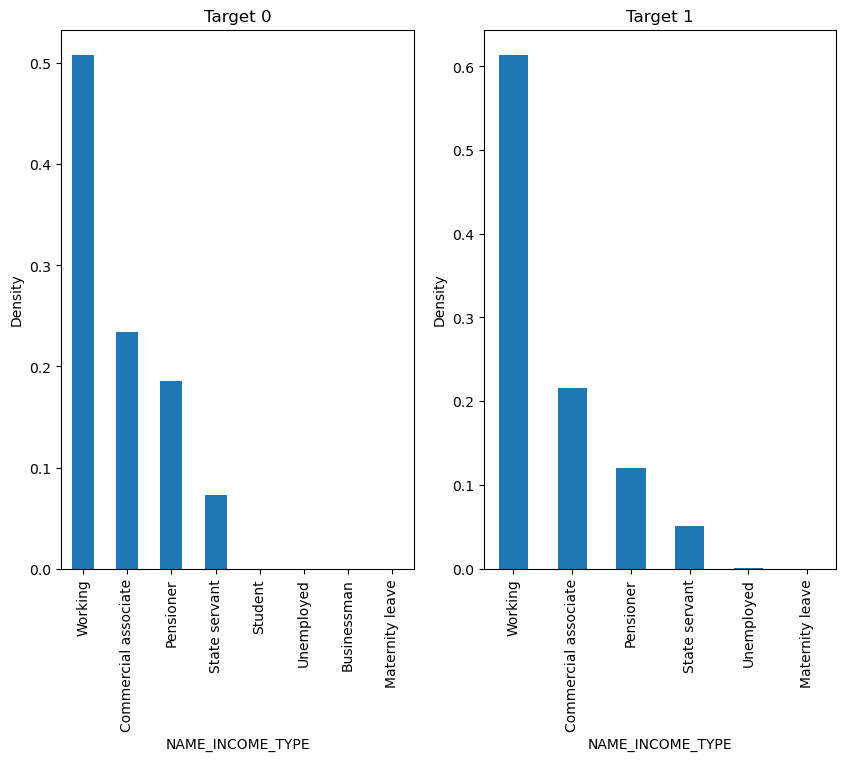



 ------------------------------------------------------------ 


Plot on NAME_EDUCATION_TYPE for Target 0 and 1


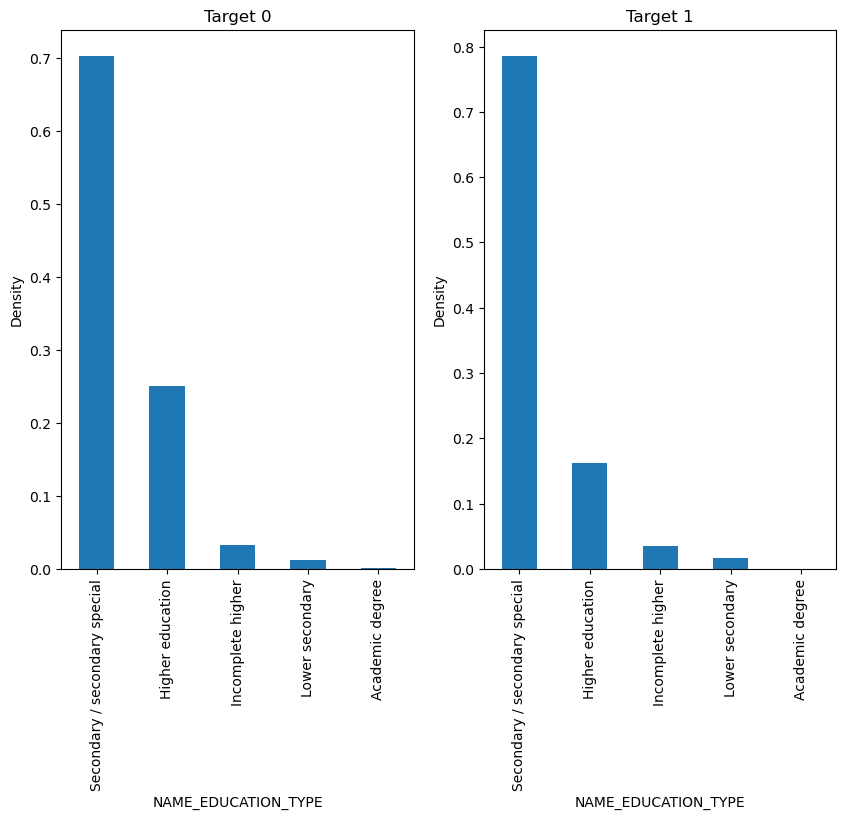



 ------------------------------------------------------------ 


Plot on NAME_FAMILY_STATUS for Target 0 and 1


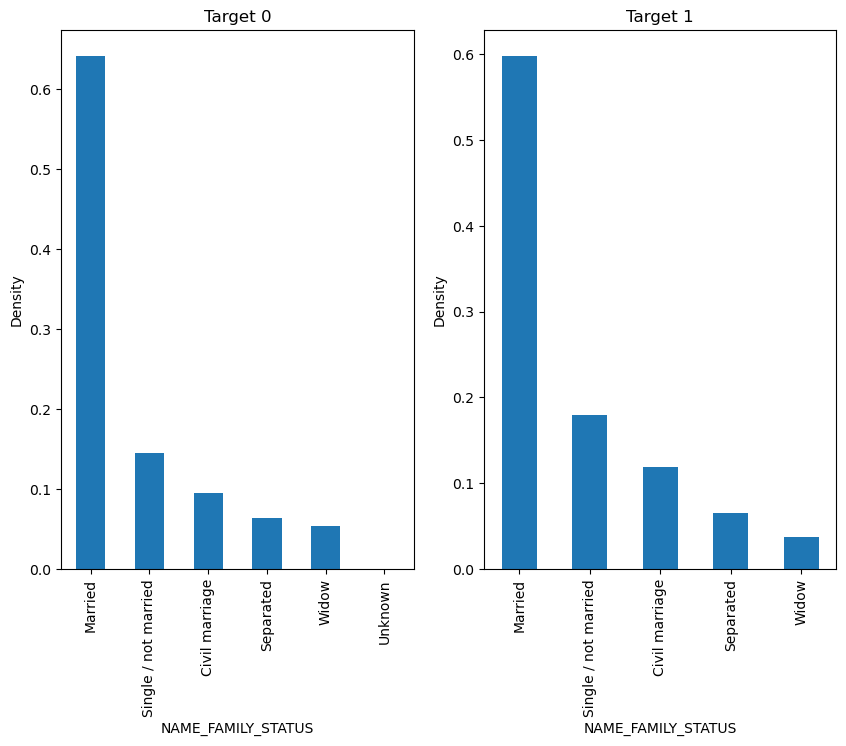



 ------------------------------------------------------------ 


Plot on NAME_HOUSING_TYPE for Target 0 and 1


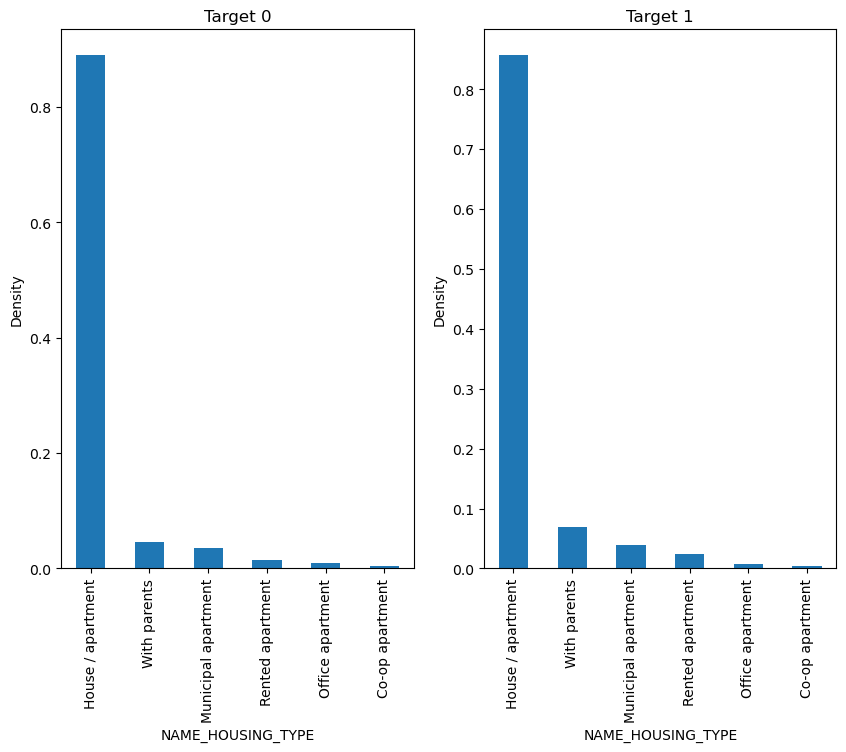



 ------------------------------------------------------------ 


Plot on OWN_CAR_AGE for Target 0 and 1


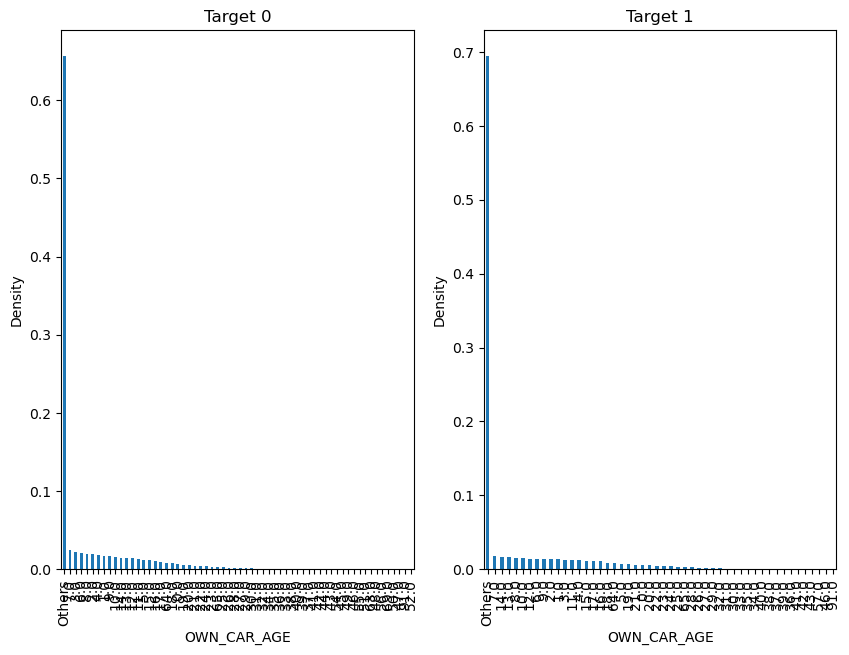



 ------------------------------------------------------------ 


Plot on OCCUPATION_TYPE for Target 0 and 1


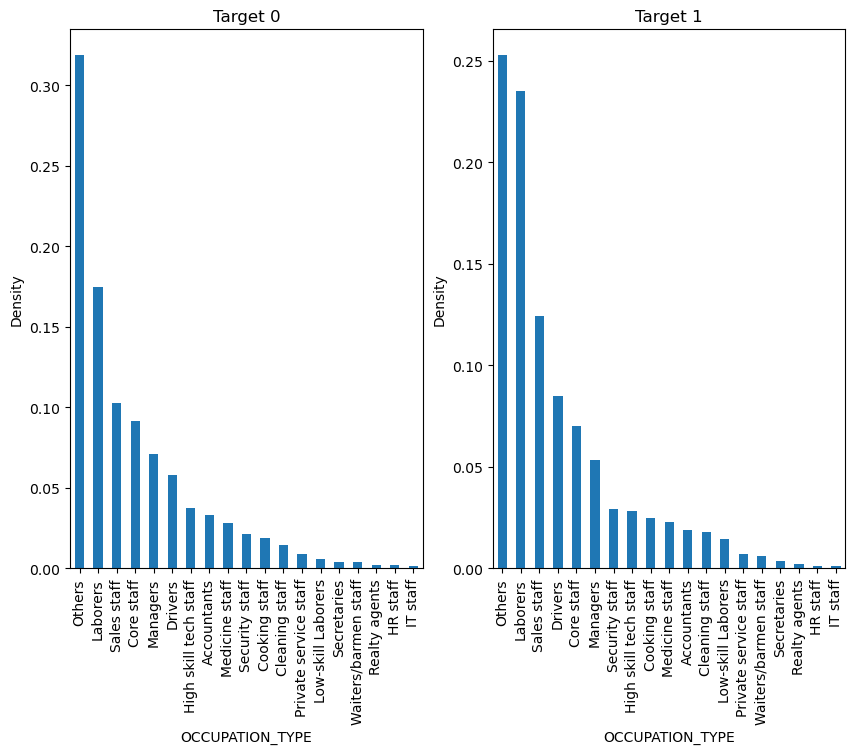



 ------------------------------------------------------------ 


Plot on WEEKDAY_APPR_PROCESS_START for Target 0 and 1


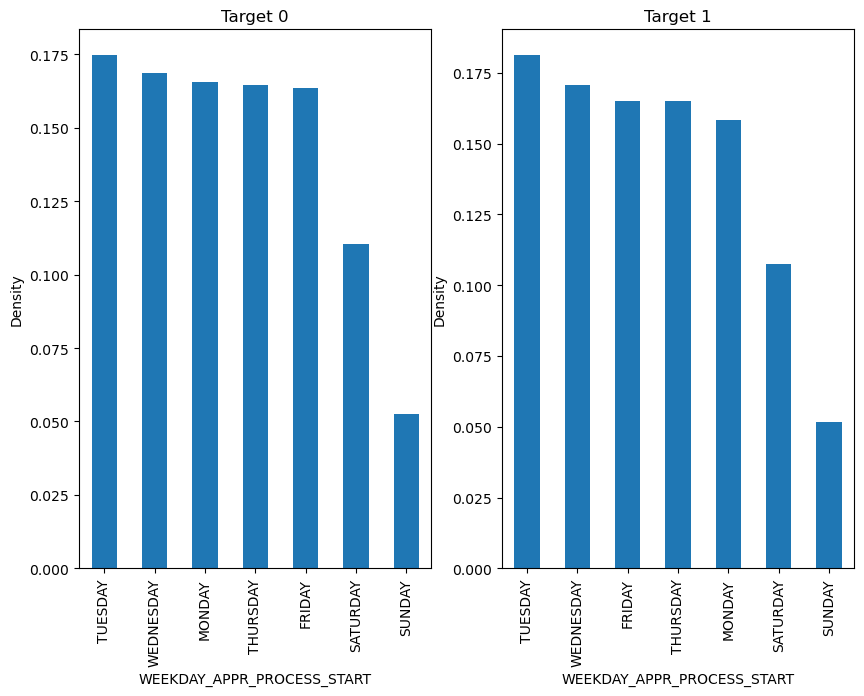



 ------------------------------------------------------------ 


Plot on ORGANIZATION_TYPE for Target 0 and 1


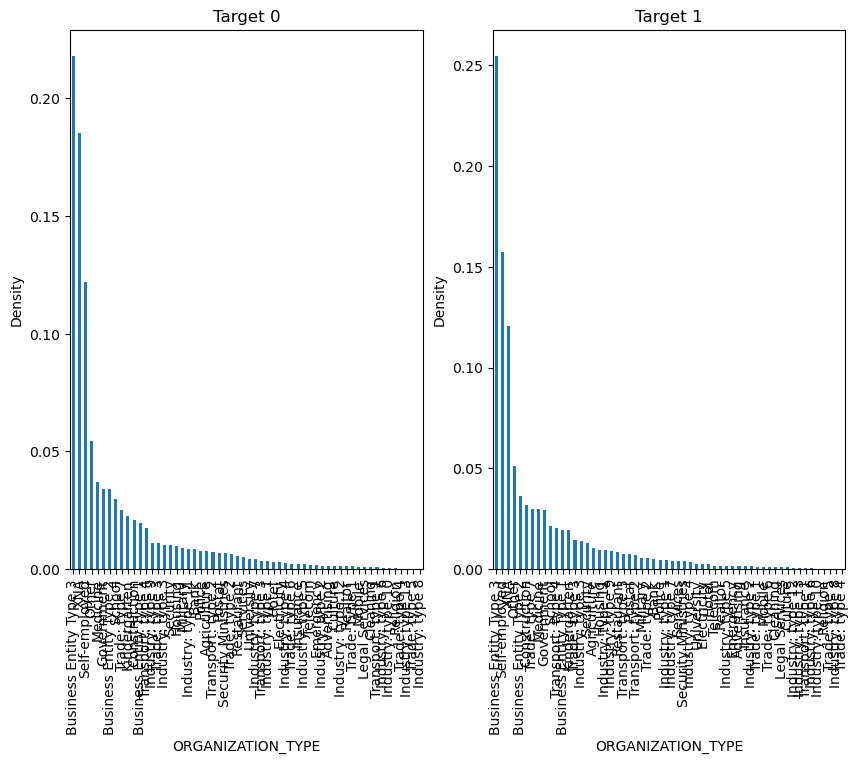



 ------------------------------------------------------------ 


Plot on FONDKAPREMONT_MODE for Target 0 and 1


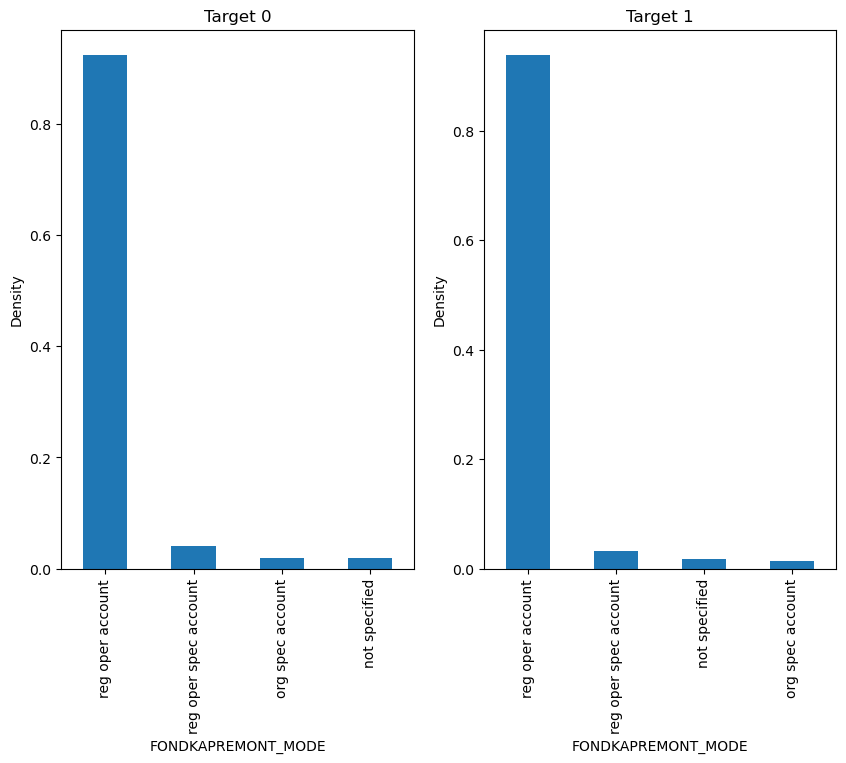



 ------------------------------------------------------------ 


Plot on HOUSETYPE_MODE for Target 0 and 1


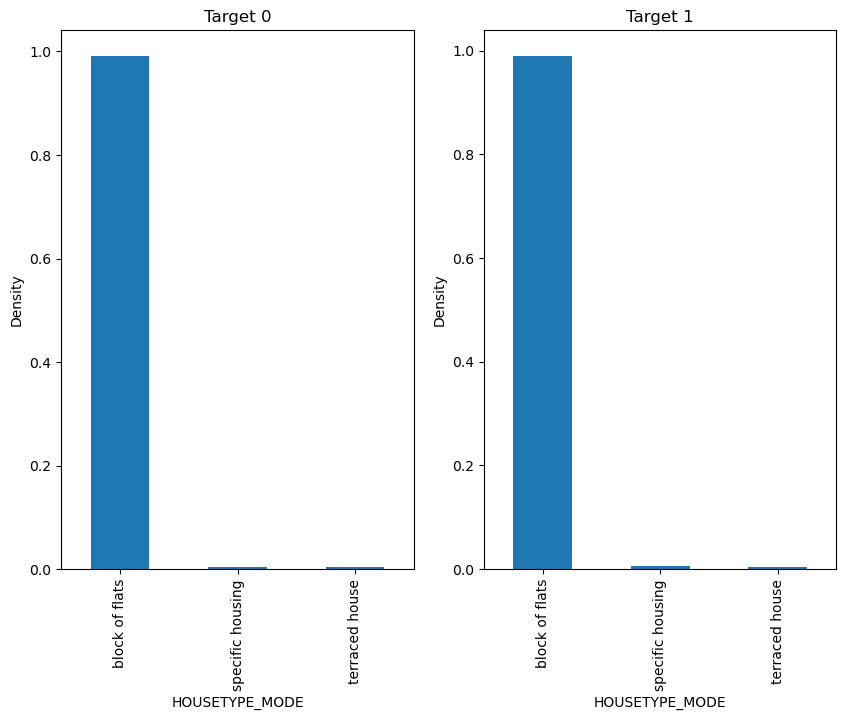



 ------------------------------------------------------------ 


Plot on WALLSMATERIAL_MODE for Target 0 and 1


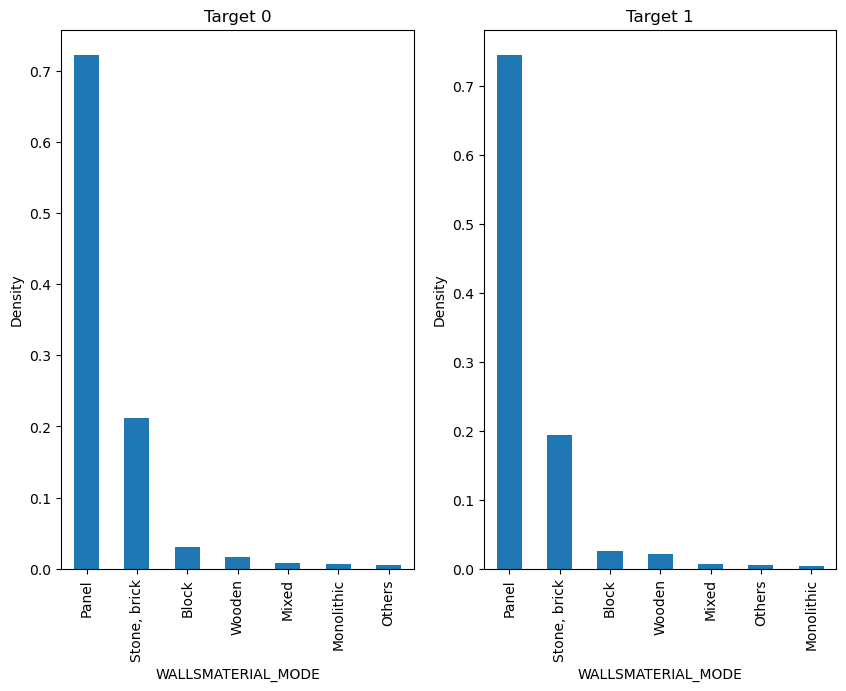



 ------------------------------------------------------------ 


Plot on EMERGENCYSTATE_MODE for Target 0 and 1


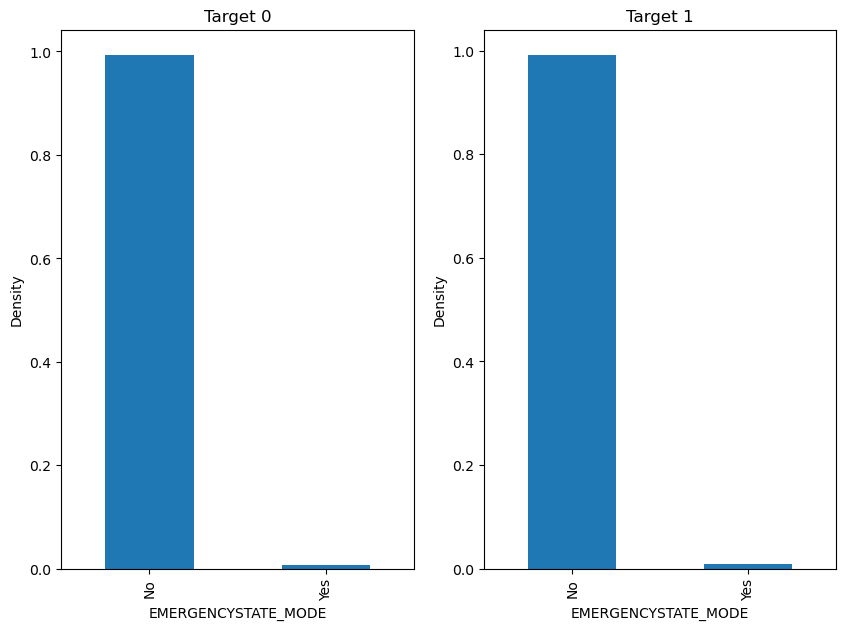



 ------------------------------------------------------------ 




In [330]:
for col in cat_cols:
    print(f"Plot on {col} for Target 0 and 1")
    plt.figure(figsize=[10,7])
    plt.subplot(1,2,1)
    tar_0[col].value_counts(normalize=True).plot.bar()
    plt.title("Target 0")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.subplot(1,2,2)
    tar_1[col].value_counts(normalize=True).plot.bar()
    plt.title("Target 1")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

    print("\n\n ------------------------------------------------------------ \n\n")


- Conclusion >> Below are the column insights

1.NAME_CONTRACT_TYPE - The Applicants are receiving more of Cash loans than Revolving loans both for Target 0 and 1

2.CODE_GENDER - Number of Female applicants are twice that of male applicants both for Target 0 and 1

3.FLAG_OWN_CAR - Most(70%) of the applicants do not own a car both for Target 0 and 1

4.FLAG_OWN_REALTY - Most(70%) of the applicants do not own a house both for Target 0 and 1

5.NAME_TYPE_SUITE - Most(81%) of the applicants are Unaccompanied both for Target 0 and 1

6.NAME_INCOME_TYPE - For both Target 0 and 1, Most(51%) of the applicants are earning their income from Work

7.NAME_EDUCATION_TYPE - For both Target 0 and 1, almost 71% of the applicants have completed Secondary / secondary special education

8.NAME_FAMILY_STATUS - 63% of the applicants are married for both Target 0 and 1

9.NAME_HOUSING_TYPE - 88% of the housing type of applicants are House/apartment for both Target 0 and 1

10.OCCUPATION_TYPE - Most(31%) of the applicants have other Occupation type, are non defaulters and Laborers, Sales staff, Drivers and core staff are not able to repay the loan on time

11.WEEKDAY_APPR_PROCESS_START - Most of the applicants have applied the loan on Tuesday and the least on Sunday

12.ORGANIZATION_TYPE - Most of the Applicants are working in Business Entity Type 3, Self Employed and other Organization type

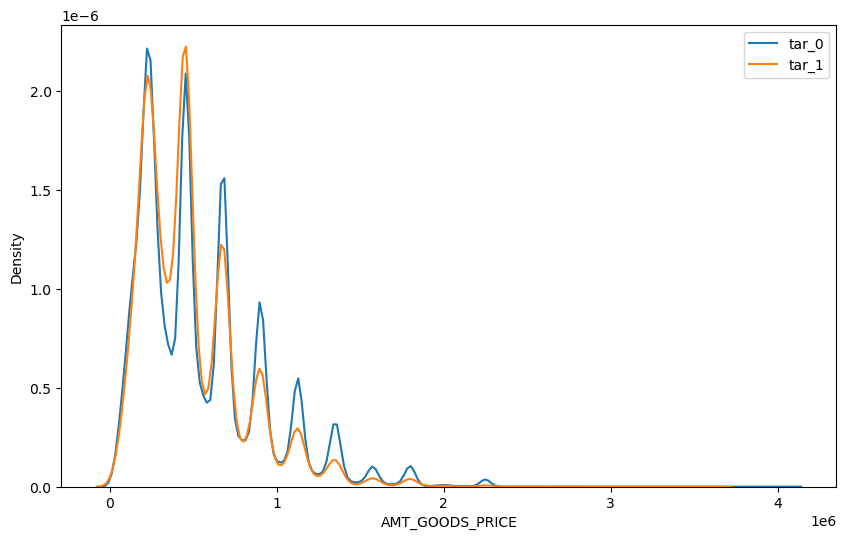

In [332]:
plt.figure(figsize=(10,6))
sns.distplot(tar_0['AMT_GOODS_PRICE'], label='tar_0', hist=False)
sns.distplot(tar_1['AMT_GOODS_PRICE'], label='tar_1', hist=False)
plt.legend()
plt.show()


- Conclusion : The Price of the goods for which loan is given has the same variable for Target 0 and 1

## Bivariate and Multivariate Analysis
#### Bivariate analysis between WEEKDAY_APPR_PROCESS_START vs HOUR_APPR_PROCESS_START

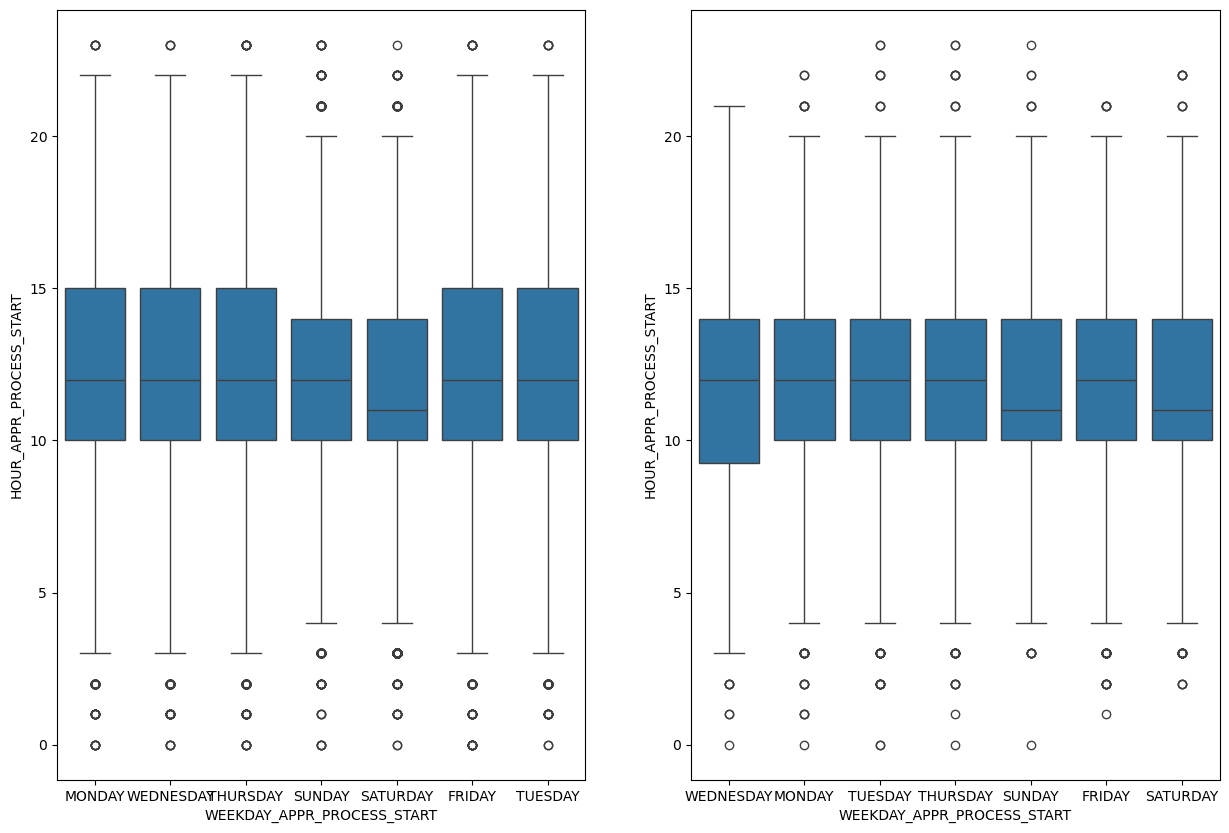

In [335]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.boxplot(x='WEEKDAY_APPR_PROCESS_START', y = 'HOUR_APPR_PROCESS_START',data= tar_0)
plt.subplot(1,2,2)
sns.boxplot(x='WEEKDAY_APPR_PROCESS_START', y = 'HOUR_APPR_PROCESS_START',data= tar_1)
plt.show()

- Conclusion >>
  
1.The Bank operates between 10am to 3pm except for Saturday and Sunday, between 10am to 2pm.

2.We can observe that around 11:30am to 12pm around 50% of customers walk in to the branch for loan application on all the days except for Saturday where the time is between 10am to 11am for both Target 0 and 1

3.The loan defaulters have applied for the loan between 9:30am–10am and 2pm, whereas the applicants who repay the loan on time have applied for the loan between 10am to 3pm

## Bivariate Analysis between AGE_CATEGORY Vs AMT_CREDIT

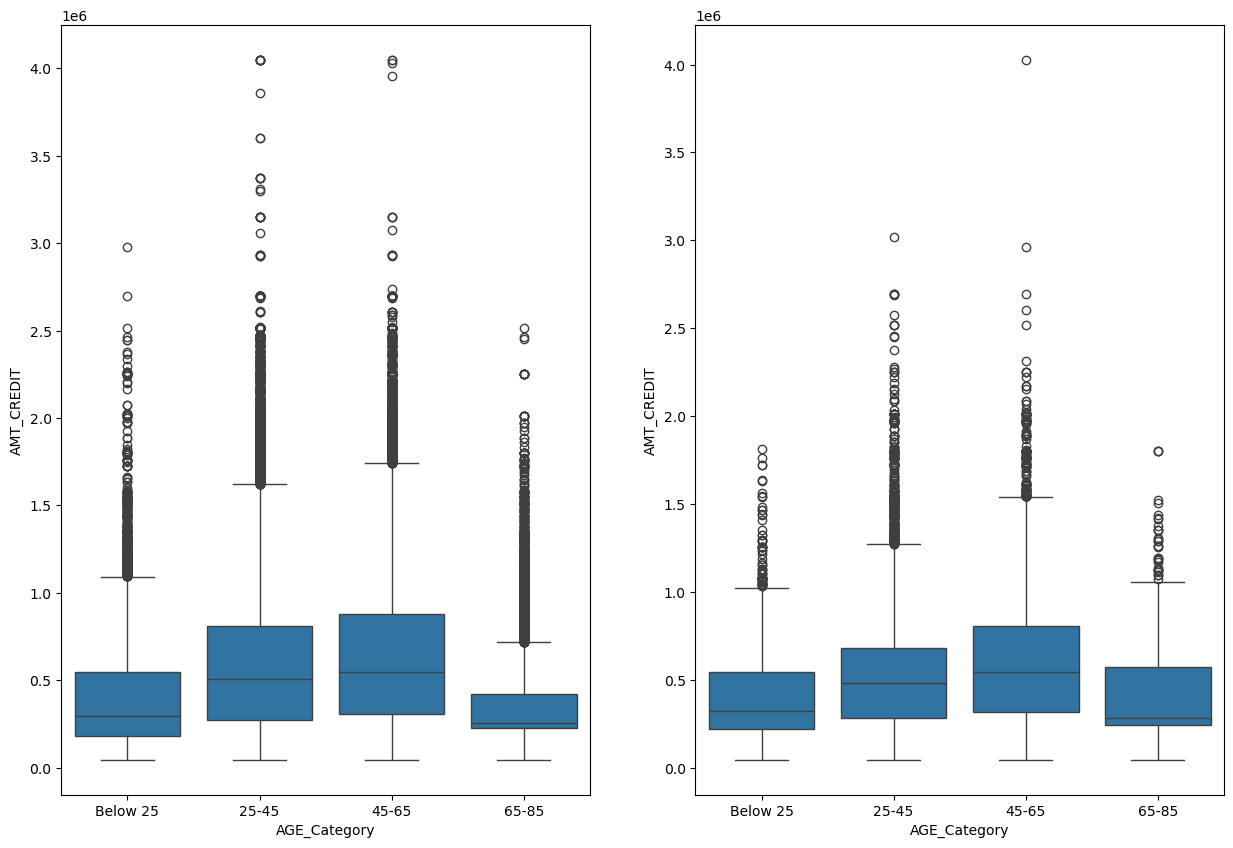

In [338]:
plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
sns.boxplot(x='AGE_Category', y='AMT_CREDIT', data=tar_0)
plt.subplot(1,2,2)
sns.boxplot(x='AGE_Category', y='AMT_CREDIT', data=tar_1)
plt.show()


- conclusion :

1.The applicant between age group 25 to 65 have credit amount to the loan less than 2500000 and are able to repay the loan properly

2.The applicants with less than 100000 Credit amount are with age group greater than 65 may be considered as loan defaulters

3.Most applicants who have Credit amount of the loan less than 1700000 are loan defaulters with 25 and less age

## Pair Plot of Amount Columns for Target 0

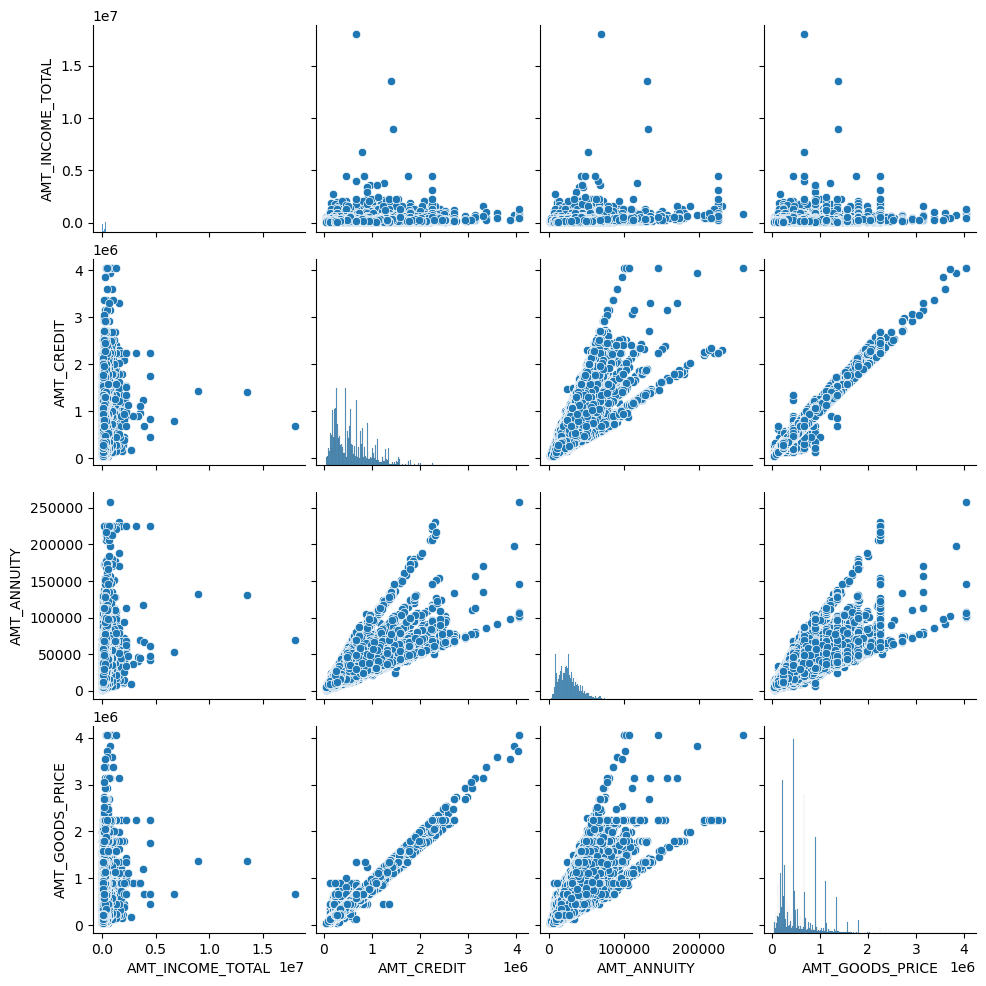

In [341]:
sns.pairplot(tar_0[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]])
plt.show()

## Pair Plot of Amount Columns for Target 1

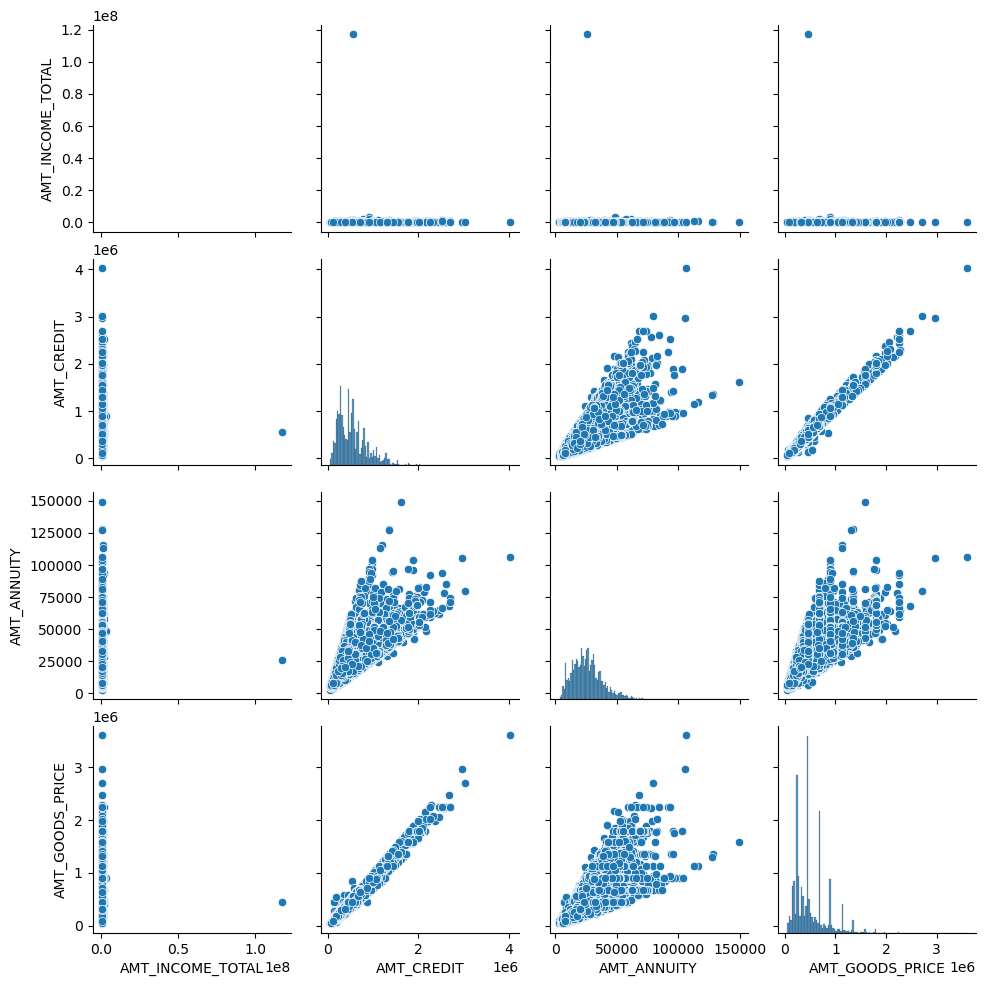

In [343]:
sns.pairplot(tar_1[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]])
plt.show()

- Conclusion >>For Applicants who are unable to replauy the loan on time

1.AMT_CREDIT Increases or varies linearly with AMT_GOODS_PRICE and AMT_CREDIT Increases with AMT_ANNUITY

2.AMT_ANNUITY Increases with Increases in AMT_GOODS_PRICE and AMT_CREDIT

3.AMT_GOODS_PRICE Increases with Increases in AMT_CREDIT and AMT_ANNUITY

4.AMT_INCOME_TOTAL has a drastic Increase with slight Increase in AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE

## Co-realtion between numerical values

In [346]:
corr_data = app_df[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "YEARS_BIRTH","YEARS_EMPLOYED", "DAYS_REGISTRATION", "YEARS_ID_PUBLISH ", "YEARS_LAST_PHONE_CHANGE"]]
corr_data.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,YEARS_BIRTH,YEARS_EMPLOYED,DAYS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
0,202500.0,406597.5,24700.5,351000.0,26,1,3648.0,5,3
1,270000.0,1293502.5,35698.5,1129500.0,47,3,1186.0,0,2
2,67500.0,135000.0,6750.0,135000.0,53,0,4260.0,7,2
3,135000.0,312682.5,29686.5,297000.0,53,8,9833.0,6,1
4,121500.0,513000.0,21865.5,513000.0,55,8,4311.0,9,3


In [347]:
corr_data.corr()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,YEARS_BIRTH,YEARS_EMPLOYED,DAYS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
AMT_INCOME_TOTAL,1.000000,0.156870,0.191657,0.159632,-0.027239,-0.063837,-0.027805,-0.008459,0.018571
AMT_CREDIT,0.156870,1.000000,0.770127,0.986734,0.055373,-0.064321,-0.009621,0.006942,0.077257
AMT_ANNUITY,0.191657,0.770127,1.000000,0.774837,-0.009519,-0.102849,-0.038514,-0.011376,0.064494
AMT_GOODS_PRICE,0.159632,0.986734,0.774837,1.000000,0.053449,-0.062193,-0.011546,0.009647,0.079349
YEARS_BIRTH,-0.027239,0.055373,-0.009519,0.053449,1.000000,0.623745,0.331776,0.272054,0.086317
YEARS_EMPLOYED,-0.063837,-0.064321,-0.102849,-0.062193,0.623745,1.000000,0.214574,0.274644,-0.016424
DAYS_REGISTRATION,-0.027805,-0.009621,-0.038514,-0.011546,0.331776,0.214574,1.000000,0.101826,0.058504
YEARS_ID_PUBLISH,-0.008459,0.006942,-0.011376,0.009647,0.272054,0.274644,0.101826,1.000000,0.092803
YEARS_LAST_PHONE_CHANGE,0.018571,0.077257,0.064494,0.079349,0.086317,-0.016424,0.058504,0.092803,1.000000


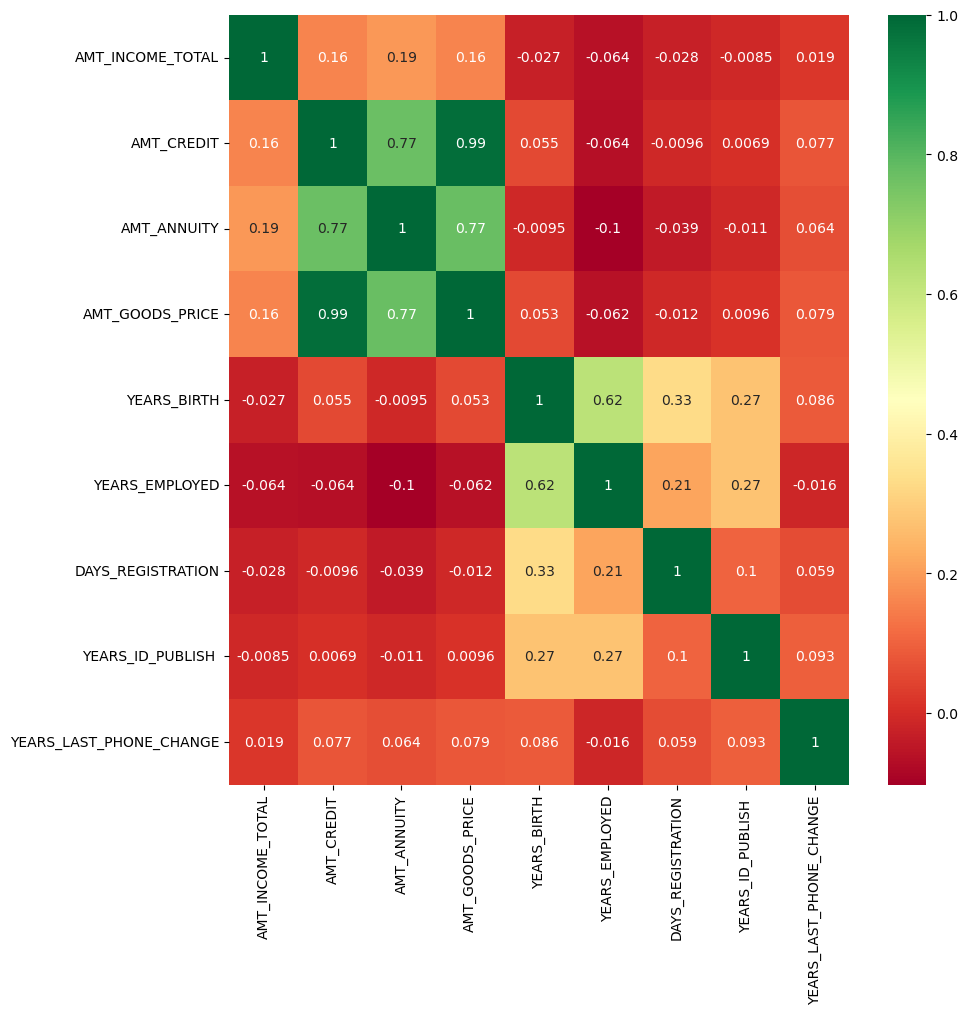

In [348]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_data.corr(),annot=True,cmap="RdYlGn")
plt.show()

- Conclusion >>
1.AMT_INCOME_TOTAL - It has a positive correlation index of 0.16, 0.19, 0.16 with AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE respectively.

2.AMT_CREDIT - Is has negative correlation index of 0.064 with YEARS_EMPLOYED and positive correlation index of 0.99, 0.77 with AMT_GOODS_PRICE, AMT_ANNUITY respectively.

3.AMT_ANNUITY - Is has negative correlation index of 0.1 with YEARS_EMPLOYED and positive correlation index of 0.77 with AMT_CREDIT

4.AMT_GOODS_PRICE - It has a positive correlation with AMT_CREDIT, AMT_ANNUITY

5.YEARS_BIRTH - It has a positive correlation with YEARS_EMPLOYED, AMT_GOODS_PRICE and negative correlation with AMT_ANNUITY, AMT_INCOME_TOTAL

6.YEARS_EMPLOYED - Is has negative correlation index of 0.1 with AMT_ANNUITY and has a positive correlation with YEARS_REGISTRATION, YEARS_ID_PUBLISH

7.YEARS_REGISTRATION - It has a positive correlation with YEARS_ID_PUBLISH, YEARS_BIRTH, YEARS_EMPLOYED

8.YEARS_ID_PUBLISH - It has a positive correlation with YEARS_REGISTRATION and negative correlation with AMT_INCOME_TOTAL, AMT_ANNUITY

9.YEARS_LAST_PHONE_CHANGE - It has negative correlation with YEARS_EMPLOYED and positive correlation with AMT_GOODS_PRICE, YEARS_ID_PUBLISH

### Split the Numerical variables based on Target 0 and 1 to find the co-relation



In [351]:
corr_data_0 = tar_0[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "YEARS_BIRTH","YEARS_EMPLOYED", "DAYS_REGISTRATION", "YEARS_ID_PUBLISH ", "YEARS_LAST_PHONE_CHANGE"]]
corr_data_0.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,YEARS_BIRTH,YEARS_EMPLOYED,DAYS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
1,270000.0,1293502.5,35698.5,1129500.0,47,3,1186.0,0,2
2,67500.0,135000.0,6750.0,135000.0,53,0,4260.0,7,2
3,135000.0,312682.5,29686.5,297000.0,53,8,9833.0,6,1
4,121500.0,513000.0,21865.5,513000.0,55,8,4311.0,9,3
5,99000.0,490495.5,27517.5,454500.0,47,4,4970.0,1,7


In [352]:
corr_data_1= tar_1[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "YEARS_BIRTH","YEARS_EMPLOYED", "DAYS_REGISTRATION", "YEARS_ID_PUBLISH ", "YEARS_LAST_PHONE_CHANGE"]]
corr_data_1.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,YEARS_BIRTH,YEARS_EMPLOYED,DAYS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
0,202500.0,406597.5,24700.5,351000.0,26,1,3648.0,5,3
26,112500.0,979992.0,27076.5,702000.0,52,7,6573.0,5,0
40,202500.0,1193580.0,35028.0,855000.0,49,3,1182.0,2,3
42,135000.0,288873.0,16258.5,238500.0,37,10,45.0,12,4
81,81000.0,252000.0,14593.5,252000.0,69,1025,5391.0,11,0


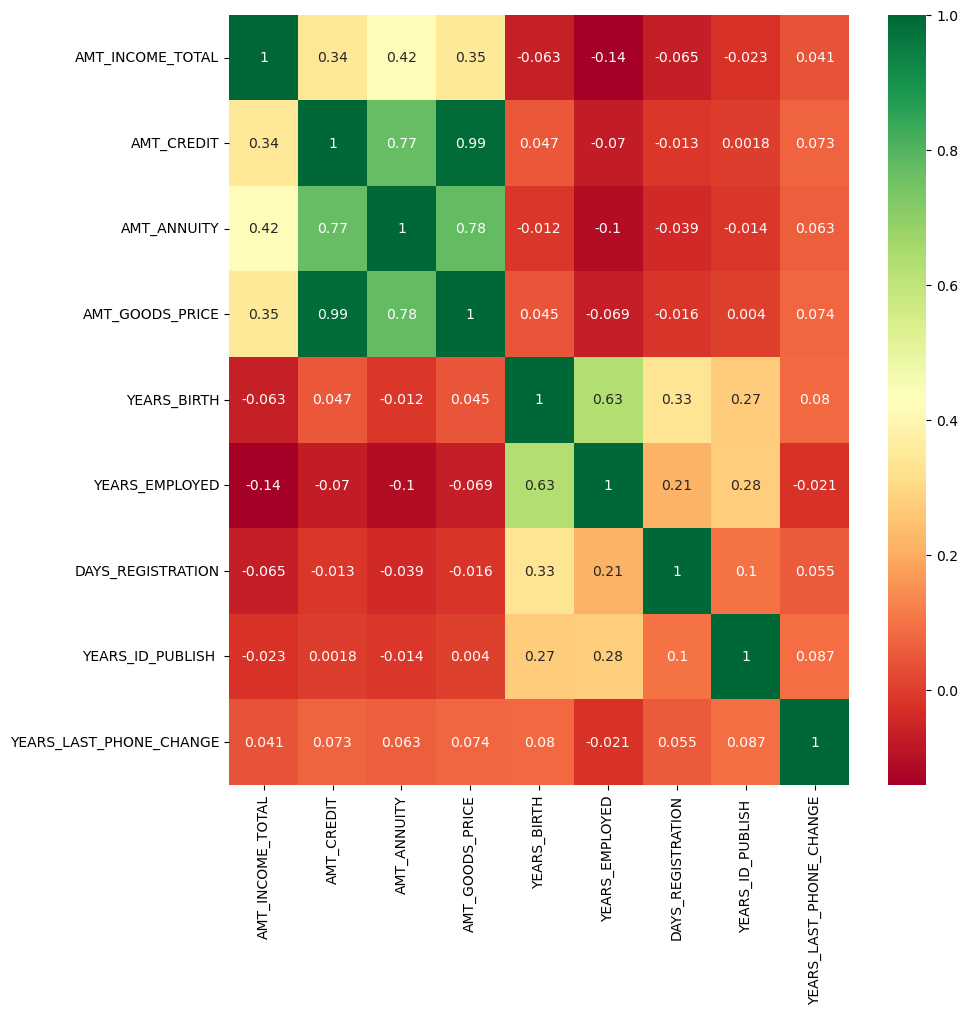

In [353]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_data_0.corr(),annot=True,cmap="RdYlGn")
plt.show()

- Conclusion >>
  
1.AMT_INCOME_TOTAL - It has a positive correlation index of 0.34, 0.42, 0.35 with AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE respectively and negative with most of the other Year columns

2.AMT_CREDIT - Is has strong positive correlation index of 0.99, 0.77 with AMT_GOODS_PRICE, AMT_ANNUITY respectively.

3.AMT_ANNUITY - Is has positive correlation index of 0.77,0.78 with AMT_CREDIT,AMT_GOODS_PRICE respectively and Negative with most of the other Year Columns

4.AMT_GOODS_PRICE - It has a strong  positive correlation index 0.78,0.99  with AMT_CREDIT, AMT_ANNUITY


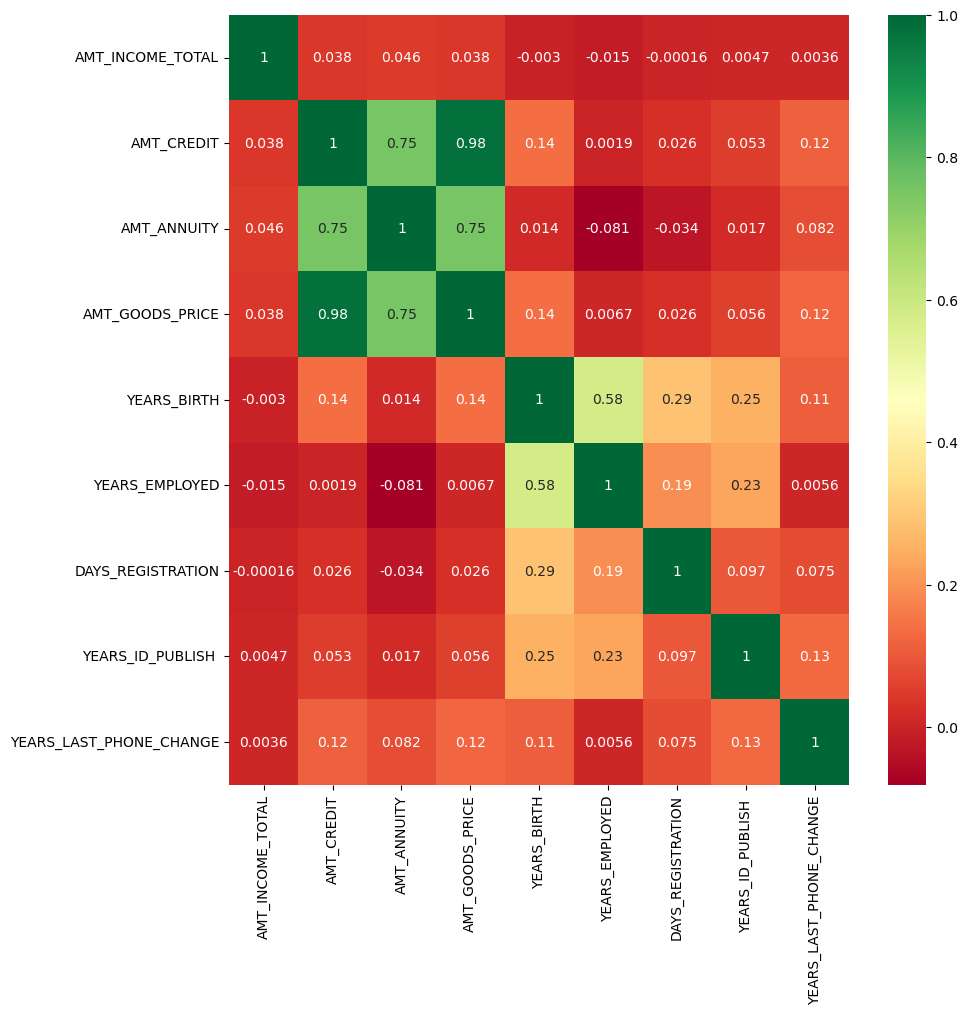

In [355]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_data_1.corr(),annot=True,cmap="RdYlGn")
plt.show()

- Conclusion >>

1.AMT_INCOME_TOTAL - It is less correlated with AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE respectively 

2.AMT_CREDIT - Is has strong positive correlation index of 0.98, 0.75 with AMT_GOODS_PRICE, AMT_ANNUITY respectively and also positive correlation with of the other Year Columns

3.AMT_ANNUITY - Is has positive correlation index of 0.75  with AMT_CREDIT,AMT_GOODS_PRICE respectively and Negative correlation with YEARS_EMPLOYED, YEARS_REGISTRATION

4.AMT_GOODS_PRICE - It has a strong positive correlation index 0.75,0.98 with AMT_CREDIT, AMT_ANNUITY and week positive correlation with of the other Year Columns

## Read Previous Application CSV

In [358]:
papp_data = pd.read_csv("previous_application.csv")
papp_data.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


# Data Inspection on apploication Dataset 
# Get info and shape on the dataset

In [360]:
papp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [361]:
papp_data.shape

(1670214, 37)

## Data Quality check

### check for percentage null values in Application dataset

In [363]:
papp_data.isnull().mean()*100

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_DOWN_PAYMENT               53.636480
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              53.636480
RATE_INTEREST_PRIMARY          99.643698
RATE_INTEREST_PRIVILEGED       99.643698
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                49.119754
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

In [364]:
percentage = 49
threshold_p = int(((100 - percentage) / 100) * papp_data.shape[0] + 1)
papp_df = papp_data.dropna(axis=1 ,thresh=threshold_p)
papp_df = papp_data.dropna(axis=1 , how = 'any')
papp_df.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_APPLICATION,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,NAME_YIELD_GROUP
0,2030495,271877,Consumer loans,17145.0,SATURDAY,15,Y,1,XAP,Approved,-73,Cash through the bank,XAP,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,middle
1,2802425,108129,Cash loans,607500.0,THURSDAY,11,Y,1,XNA,Approved,-164,XNA,XAP,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,low_action
2,2523466,122040,Cash loans,112500.0,TUESDAY,11,Y,1,XNA,Approved,-301,Cash through the bank,XAP,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,high
3,2819243,176158,Cash loans,450000.0,MONDAY,7,Y,1,XNA,Approved,-512,Cash through the bank,XAP,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,middle
4,1784265,202054,Cash loans,337500.0,THURSDAY,9,Y,1,Repairs,Refused,-781,Cash through the bank,HC,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,high


In [365]:
papp_df.shape

(1670214, 21)

## Impute missing values 
  #### Check the missing values in application dataset before imputing

In [367]:
#papp_df.DAYS_BIRTH = app_df.DAYS_BIRTH.apply(lambda x : abs(x))
#papp_df.DAYS_EMPLOYED = app_df.DAYS_EMPLOYED.apply(lambda x : abs(x))
#papp_df.DAYS_REGISTRATION = app_df.DAYS_REGISTRATION.apply(lambda x : abs(x))
#papp_df.DAYS_ID_PUBLISH  = app_df.DAYS_ID_PUBLISH .apply(lambda x : abs(x))
#papp_df.DAYS_LAST_PHONE_CHANGE= app_df.DAYS_LAST_PHONE_CHANGE.apply(lambda x : abs(x))

In [368]:
for col in papp_df.columns:
    if papp_df[col].dtypes == np.int64 or papp_df[col].dtypes == np.float64:
        papp_df[col] = papp_df[col].apply(lambda x: abs(x))

## Validate if any null values present in dataset

In [370]:
papp_df = pd.read_csv('previous_application.csv', na_values=["", "NA", "N/A", "#N/A"])
print(papp_df.isnull().mean() * 100)

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_DOWN_PAYMENT               53.636480
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              53.636480
RATE_INTEREST_PRIMARY          99.643698
RATE_INTEREST_PRIVILEGED       99.643698
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                49.119754
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

In [371]:
null_cols = list(papp_df.columns[papp_df.isna().any()])
len(null_cols)

16

In [372]:
papp_df.isnull().mean()*100

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_DOWN_PAYMENT               53.636480
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              53.636480
RATE_INTEREST_PRIMARY          99.643698
RATE_INTEREST_PRIVILEGED       99.643698
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                49.119754
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

In [373]:
papp_df.AMT_CREDIT.describe()

count    1.670213e+06
mean     1.961140e+05
std      3.185746e+05
min      0.000000e+00
25%      2.416050e+04
50%      8.054100e+04
75%      2.164185e+05
max      6.905160e+06
Name: AMT_CREDIT, dtype: float64

In [374]:
papp_df["AMT_CREDIT_Category"] = pd.cut(papp_df.AMT_CREDIT, [0,200000, 400000, 600000, 800000,1000000], 
                                       labels = ["Very low Credit","low Credit", "Medium Credit", "High Credit", "Very High Credit"])

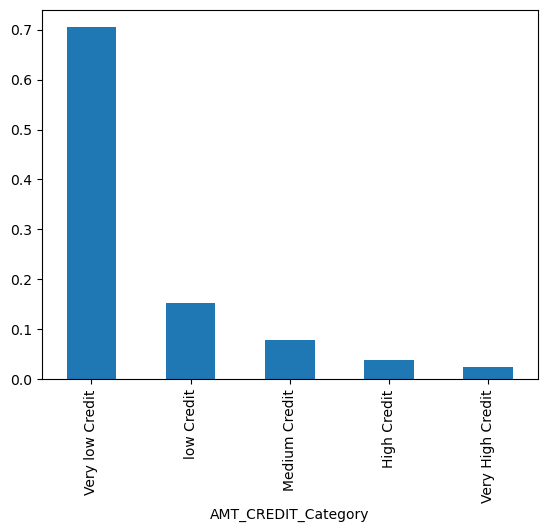

In [375]:
papp_df["AMT_CREDIT_Category"].value_counts(normalize=True).plot.bar()
plt.show()

- conclusion >> The credit amount of the loan for most applicants is either low(200000 to 400000)

In [377]:
papp_df["AMT_GOODS_PRICE_Category"] = pd.qcut(
    papp_df["AMT_GOODS_PRICE"],
    q=[0, 0.25, 0.45, 0.65, 0.85, 1],
    labels=["Very low price", "Low price", "Medium Price", "High Price", "Very High Price"]
)


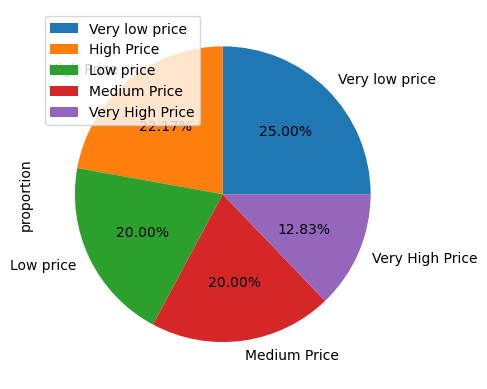

In [378]:
papp_df["AMT_GOODS_PRICE_Category"].value_counts(normalize=True).plot.pie(autopct='%1.2f%%')
plt.legend()
plt.show()

## Data Imbalance check

#### Dividing Application Dataset with NAME_CONTRACT_STATUS

In [381]:
approved = papp_df[papp_df.NAME_CONTRACT_STATUS == 'Approved']
canceled = papp_df[papp_df.NAME_CONTRACT_STATUS == 'Canceled']
refused = papp_df[papp_df.NAME_CONTRACT_STATUS == 'Refused']
unused = papp_df[papp_df.NAME_CONTRACT_STATUS == 'Unused offer']

In [382]:
papp_df.NAME_CONTRACT_STATUS.value_counts(normalize=True)*100

NAME_CONTRACT_STATUS
Approved        62.074740
Canceled        18.938831
Refused         17.403638
Unused offer     1.582791
Name: proportion, dtype: float64

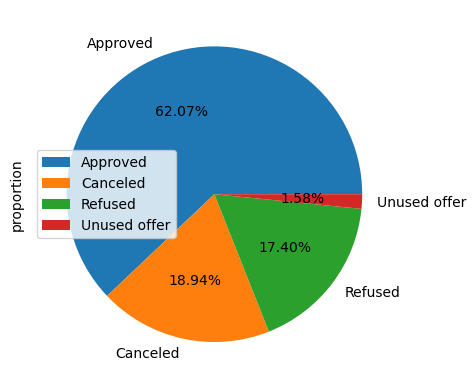

In [383]:
papp_df.NAME_CONTRACT_STATUS.value_counts(normalize=True).plot.pie(autopct='%1.2f%%')
plt.legend()
plt.show()

- conclusion >> 62% of the applicants have the loan approved ,19% ,17% applicants are rejected or cancelled and 2% are unused

## Univariate Analysis

In [386]:
cat_cols = list(papp_df.columns[papp_df.dtypes == object])
num_cols = list(papp_df.columns[papp_df.dtypes == np.int64]) + list(papp_df.columns[papp_df.dtypes == np.float64]) 


In [387]:
cat_cols 

['NAME_CONTRACT_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'FLAG_LAST_APPL_PER_CONTRACT',
 'NAME_CASH_LOAN_PURPOSE',
 'NAME_CONTRACT_STATUS',
 'NAME_PAYMENT_TYPE',
 'CODE_REJECT_REASON',
 'NAME_TYPE_SUITE',
 'NAME_CLIENT_TYPE',
 'NAME_GOODS_CATEGORY',
 'NAME_PORTFOLIO',
 'NAME_PRODUCT_TYPE',
 'CHANNEL_TYPE',
 'NAME_SELLER_INDUSTRY',
 'NAME_YIELD_GROUP',
 'PRODUCT_COMBINATION']

In [388]:
num_cols

['SK_ID_PREV',
 'SK_ID_CURR',
 'HOUR_APPR_PROCESS_START',
 'NFLAG_LAST_APPL_IN_DAY',
 'DAYS_DECISION',
 'SELLERPLACE_AREA',
 'AMT_ANNUITY',
 'AMT_APPLICATION',
 'AMT_CREDIT',
 'AMT_DOWN_PAYMENT',
 'AMT_GOODS_PRICE',
 'RATE_DOWN_PAYMENT',
 'RATE_INTEREST_PRIMARY',
 'RATE_INTEREST_PRIVILEGED',
 'CNT_PAYMENT',
 'DAYS_FIRST_DRAWING',
 'DAYS_FIRST_DUE',
 'DAYS_LAST_DUE_1ST_VERSION',
 'DAYS_LAST_DUE',
 'DAYS_TERMINATION',
 'NFLAG_INSURED_ON_APPROVAL']

In [389]:
s = ["NAME_CONTRACT_TYPE", "WEEKDAY_APPR_PROCESS_START", "NAME_CONTRACT_STATUS","NAME_PAYMENT_TYPE", "NAME_CLIENT_TYPE", "NAME_SELLER_INDUSTRY", "CHANNEL_TYPE", "NAME_YIELD_GROUP", "PRODUCT_COMBINATION"]

In [390]:
num_cols = ["HOUR_APPR_PROCESS_START", "DAYS_DECISION", "AMT_ANNUITY","AMT_APPLICATION", "AMT_CREDIT", "AMT_DOWN_PAYMENT", "AMT_GOODS_PRICE", "CNT_PAYMENT"]

## Plot on categorical columns

NAME_CONTRACT_TYPE
Cash loans         44.757917
Consumer loans     43.656142
Revolving loans    11.565225
XNA                 0.020716
Name: proportion, dtype: float64


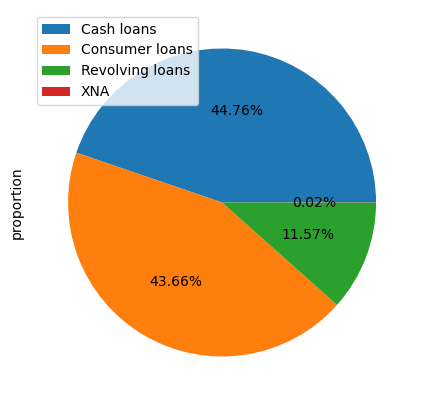

----------------------
WEEKDAY_APPR_PROCESS_START
TUESDAY      15.274570
WEDNESDAY    15.268103
MONDAY       15.181109
FRIDAY       15.090761
THURSDAY     14.914197
SATURDAY     14.407196
SUNDAY        9.864065
Name: proportion, dtype: float64


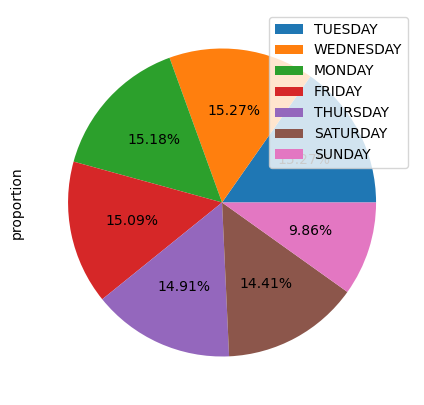

----------------------
FLAG_LAST_APPL_PER_CONTRACT
Y    99.49258
N     0.50742
Name: proportion, dtype: float64


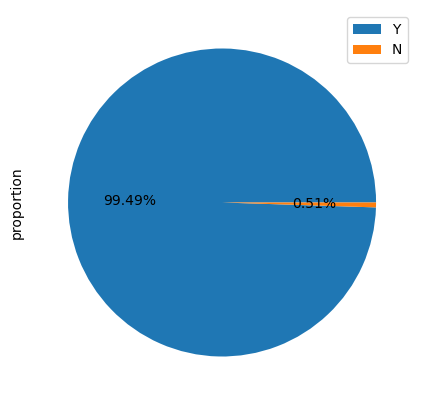

----------------------
NAME_CASH_LOAN_PURPOSE
XAP                                 55.242083
XNA                                 40.588691
Repairs                              1.422872
Other                                0.934491
Urgent needs                         0.503648
Buying a used car                    0.172912
Building a house or an annex         0.161237
Everyday expenses                    0.144652
Medicine                             0.130163
Payments on other loans              0.115614
Education                            0.094180
Journey                              0.074182
Purchase of electronic equipment     0.063525
Buying a new car                     0.060591
Wedding / gift / holiday             0.057597
Buying a home                        0.051790
Car repairs                          0.047718
Furniture                            0.044845
Buying a holiday home / land         0.031912
Business development                 0.025506
Gasification / water supply       

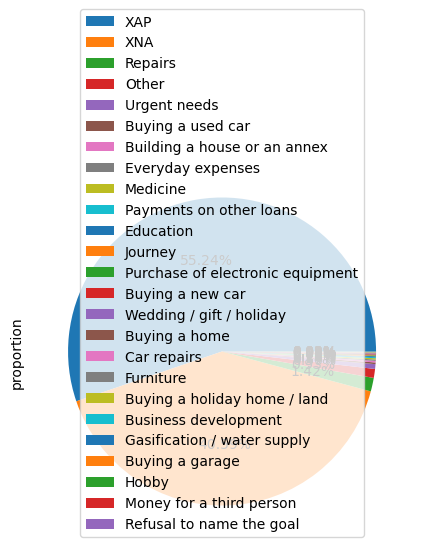

----------------------
NAME_CONTRACT_STATUS
Approved        62.074740
Canceled        18.938831
Refused         17.403638
Unused offer     1.582791
Name: proportion, dtype: float64


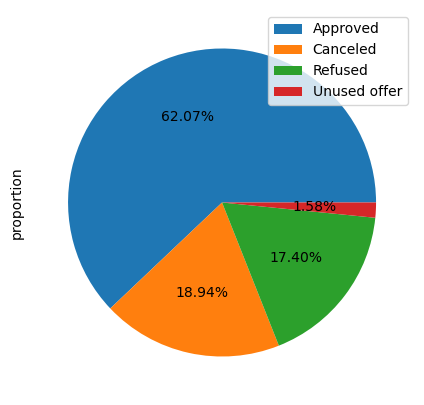

----------------------
NAME_PAYMENT_TYPE
Cash through the bank                        61.881412
XNA                                          37.563091
Non-cash from your account                    0.490536
Cashless from the account of the employer     0.064962
Name: proportion, dtype: float64


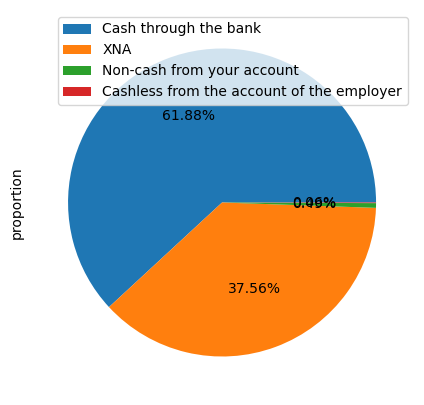

----------------------
CODE_REJECT_REASON
XAP       81.013152
HC        10.491530
LIMIT      3.333705
SCO        2.243245
CLIENT     1.582791
SCOFR      0.767027
XNA        0.313972
VERIF      0.211650
SYSTEM     0.042929
Name: proportion, dtype: float64


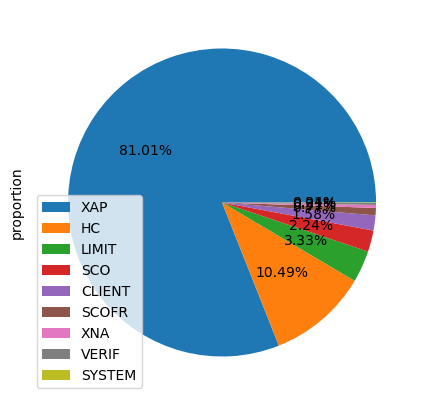

----------------------
NAME_TYPE_SUITE
Unaccompanied      59.892282
Family             25.095404
Spouse, partner     7.892244
Children            3.714482
Other_B             2.073878
Other_A             1.068122
Group of people     0.263589
Name: proportion, dtype: float64


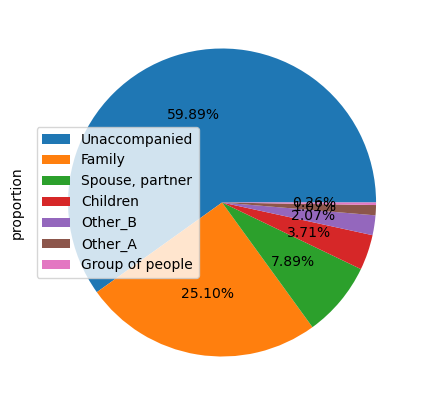

----------------------
NAME_CLIENT_TYPE
Repeater     73.718757
New          18.043376
Refreshed     8.121654
XNA           0.116213
Name: proportion, dtype: float64


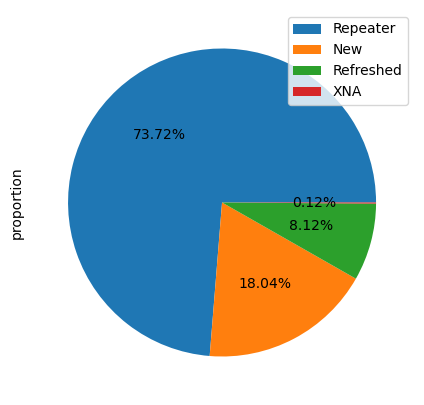

----------------------
NAME_GOODS_CATEGORY
XNA                         56.927376
Mobile                      13.453845
Consumer Electronics         7.279067
Computers                    6.332662
Audio/Video                  5.953788
Furniture                    3.212522
Photo / Cinema Equipment     1.498072
Construction Materials       1.496515
Clothing and Accessories     1.410238
Auto Accessories             0.441919
Jewelry                      0.376598
Homewares                    0.300740
Medical Supplies             0.230090
Vehicles                     0.201771
Sport and Leisure            0.178480
Gardening                    0.159740
Other                        0.152915
Office Appliances            0.139683
Tourism                      0.099329
Medicine                     0.092802
Direct Sales                 0.026703
Fitness                      0.012513
Additional Service           0.007664
Education                    0.006406
Weapon                       0.004610
Insuran

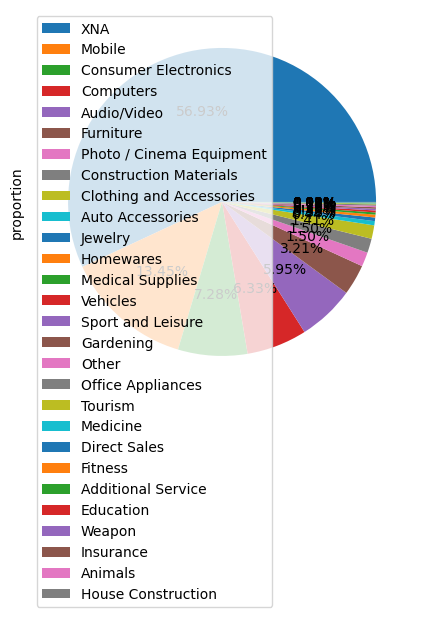

----------------------
NAME_PORTFOLIO
POS      41.372603
Cash     27.634962
XNA      22.286366
Cards     8.680624
Cars      0.025446
Name: proportion, dtype: float64


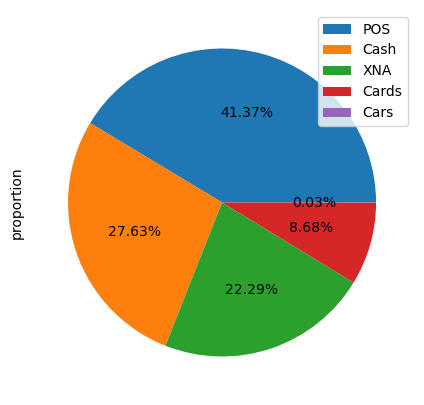

----------------------
NAME_PRODUCT_TYPE
XNA        63.684414
x-sell     27.319074
walk-in     8.996512
Name: proportion, dtype: float64


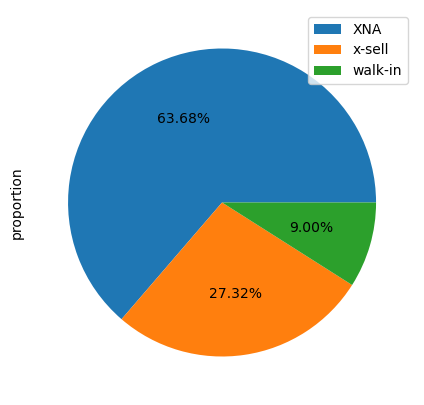

----------------------
CHANNEL_TYPE
Credit and cash offices       43.106332
Country-wide                  29.618360
Stone                         12.697954
Regional / Local               6.497850
Contact center                 4.268734
AP+ (Cash loan)                3.415490
Channel of corporate sales     0.368216
Car dealer                     0.027062
Name: proportion, dtype: float64


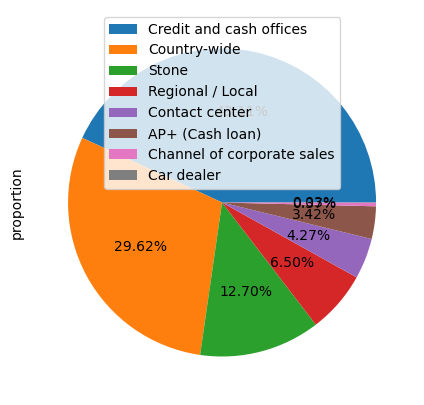

----------------------
NAME_SELLER_INDUSTRY
XNA                     51.234153
Consumer electronics    23.845148
Connectivity            16.526565
Furniture                3.463568
Construction             1.783065
Clothing                 1.433888
Industry                 1.149194
Auto technology          0.298764
Jewelry                  0.162195
MLM partners             0.072745
Tourism                  0.030715
Name: proportion, dtype: float64


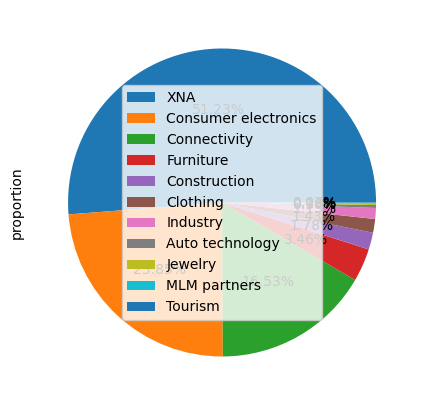

----------------------
NAME_YIELD_GROUP
XNA           30.966990
middle        23.082791
high          21.154834
low_normal    19.284655
low_action     5.510731
Name: proportion, dtype: float64


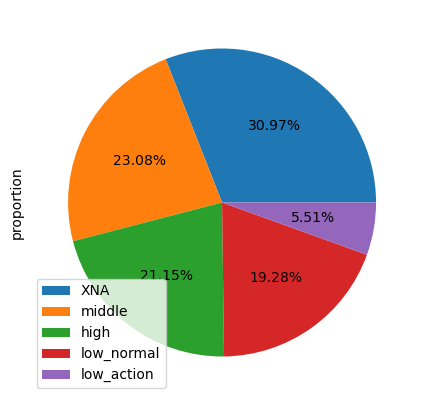

----------------------
PRODUCT_COMBINATION
Cash                              17.126503
POS household with interest       15.786996
POS mobile with interest          13.214817
Cash X-Sell: middle                8.616430
Cash X-Sell: low                   7.799898
Card Street                        6.741970
POS industry with interest         5.918612
POS household without interest     4.964943
Card X-Sell                        4.825651
Cash Street: high                  3.571480
Cash X-Sell: high                  3.551239
Cash Street: middle                2.075493
Cash Street: low                   2.026148
POS mobile without interest        1.442150
POS other with interest            1.429993
POS industry without interest      0.754670
POS others without interest        0.153006
Name: proportion, dtype: float64


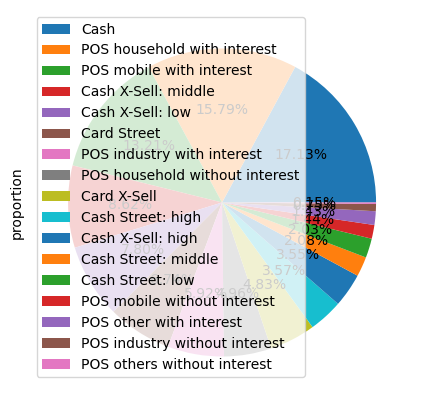

----------------------


In [392]:
for col in cat_cols:
    print(papp_df[col].value_counts(normalize=True)*100)
    plt.figure(figsize=[5,5])
    papp_df[col].value_counts(normalize=True).plot.pie(labeldistance = None, autopct = '%1.2f%%')
    plt.legend()
    plt.show()
    print("----------------------")


- Conclusion

1.NAME_CONTRACT_TYPE - 45% Applicants received Cash loans ,44% Applicants received Consumer loans ,12% received Revolving loans during previous application

2.WEEKDAY_APPR_PROCESS_START - All the days have almost equal number of previous loan application

3.NAME_PAYMENT_STATUS - 62% of Applicants are approved ,19% Cancelled ,17% Refused and 2% unused

4.NAME_PAYMENT_TYPE - 74% of Applicants type are Cash through bank ,10% are New applicants ,8% are Refreshed Applicants

5.NAME_SELLER_INDUSTRY - 51% are from Other industries ,24% are from Consumer electronics ,Connectivity industry respectively

6.CHANNEL_TYPE - 45% Channel type is Credit and cash offices ,20% are country wide

7.NAME_YIELD_GROUP - Majority of the yield group are others

8.PRODUCT_COMBINATION - Most used PRODUCT COMBINATION is Cash followed by POS household with interest ,POS mobile with interest

## Plot on Numerical columns

99th Percentile 17.0
count    1.670214e+06
mean     1.248418e+01
std      3.334028e+00
min      0.000000e+00
25%      1.000000e+01
50%      1.200000e+01
75%      1.500000e+01
max      2.300000e+01
Name: HOUR_APPR_PROCESS_START, dtype: float64


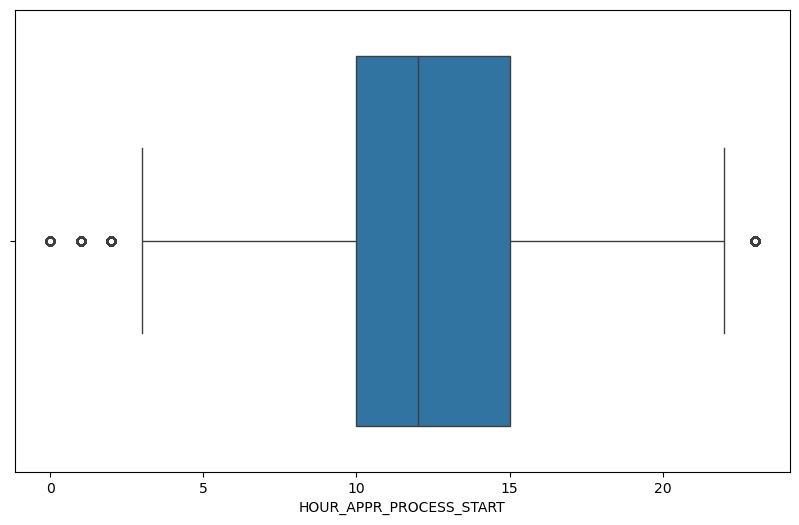

99th Percentile -152.0
count    1.670214e+06
mean    -8.806797e+02
std      7.790997e+02
min     -2.922000e+03
25%     -1.300000e+03
50%     -5.810000e+02
75%     -2.800000e+02
max     -1.000000e+00
Name: DAYS_DECISION, dtype: float64


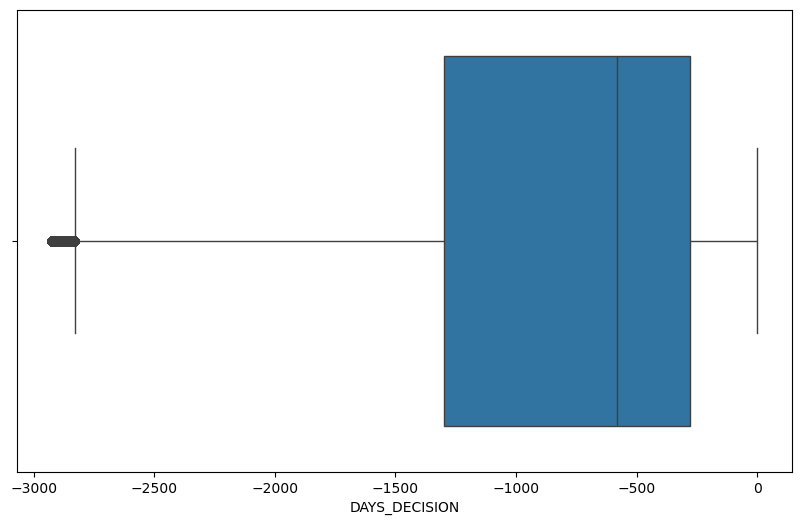

99th Percentile nan
count    1.297979e+06
mean     1.595512e+04
std      1.478214e+04
min      0.000000e+00
25%      6.321780e+03
50%      1.125000e+04
75%      2.065842e+04
max      4.180581e+05
Name: AMT_ANNUITY, dtype: float64


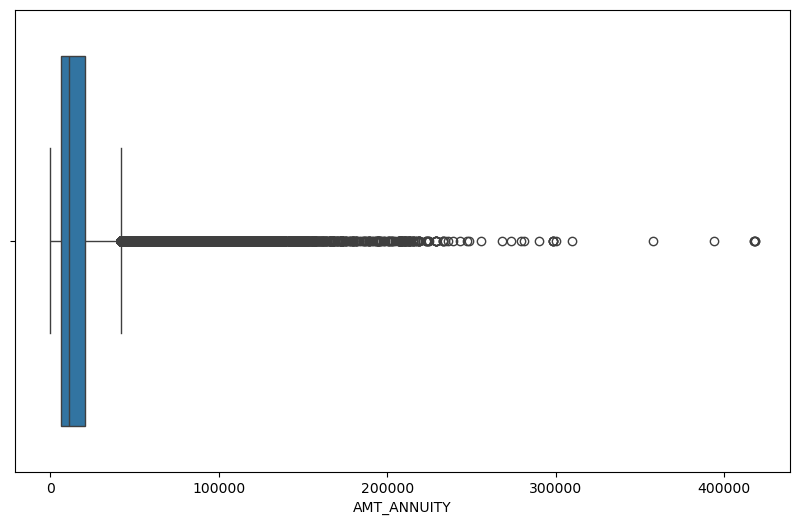

99th Percentile 450000.0
count    1.670214e+06
mean     1.752339e+05
std      2.927798e+05
min      0.000000e+00
25%      1.872000e+04
50%      7.104600e+04
75%      1.803600e+05
max      6.905160e+06
Name: AMT_APPLICATION, dtype: float64


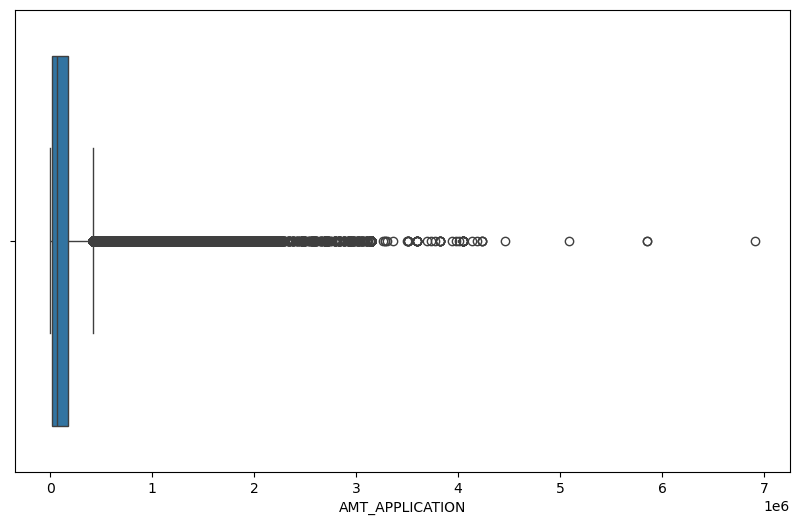

99th Percentile nan
count    1.670213e+06
mean     1.961140e+05
std      3.185746e+05
min      0.000000e+00
25%      2.416050e+04
50%      8.054100e+04
75%      2.164185e+05
max      6.905160e+06
Name: AMT_CREDIT, dtype: float64


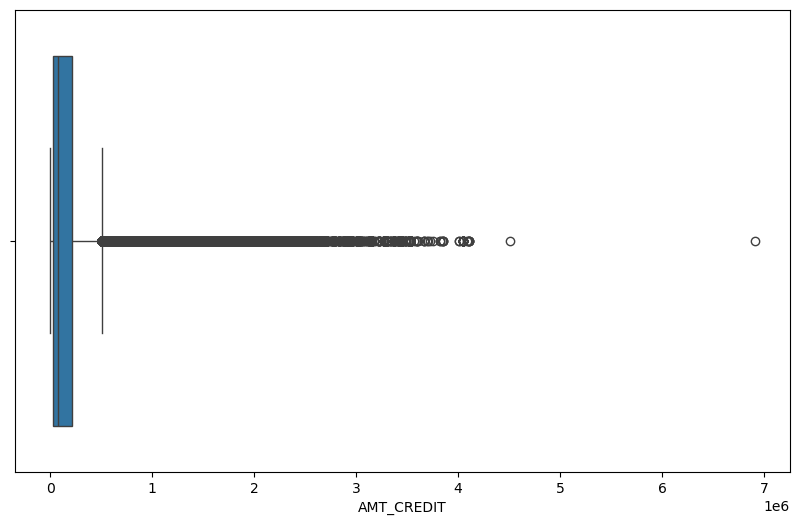

99th Percentile nan
count    7.743700e+05
mean     6.697402e+03
std      2.092150e+04
min     -9.000000e-01
25%      0.000000e+00
50%      1.638000e+03
75%      7.740000e+03
max      3.060045e+06
Name: AMT_DOWN_PAYMENT, dtype: float64


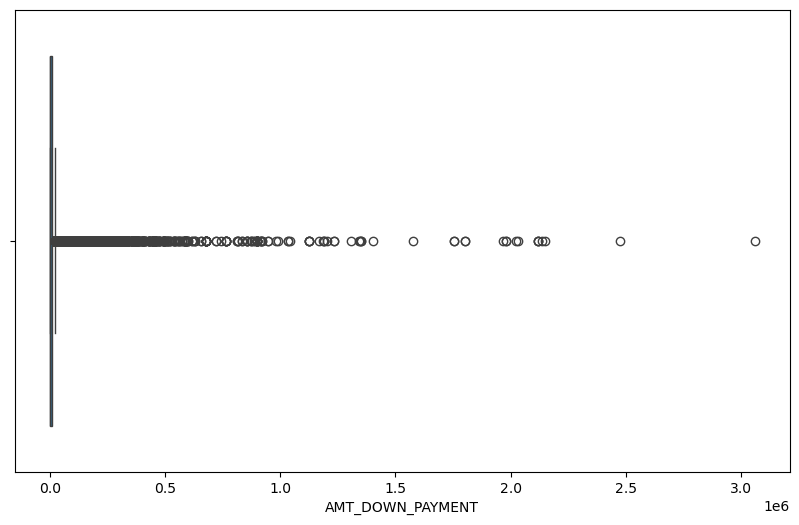

99th Percentile nan
count    1.284699e+06
mean     2.278473e+05
std      3.153966e+05
min      0.000000e+00
25%      5.084100e+04
50%      1.123200e+05
75%      2.340000e+05
max      6.905160e+06
Name: AMT_GOODS_PRICE, dtype: float64


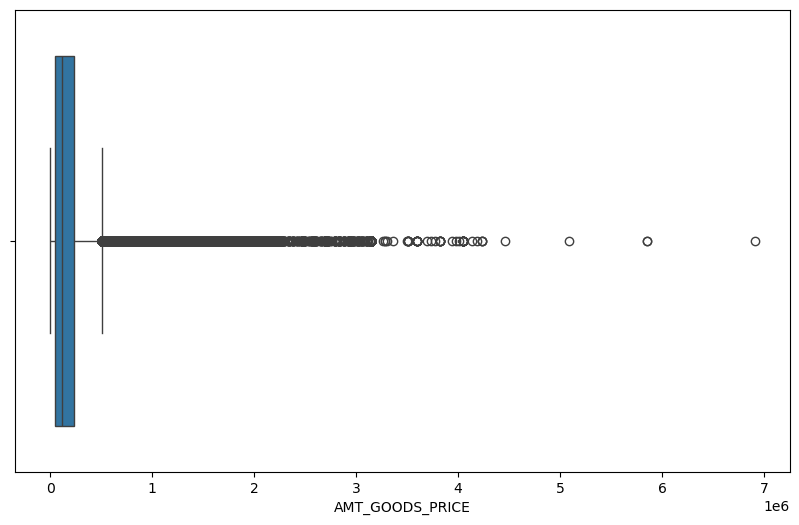

99th Percentile nan
count    1.297984e+06
mean     1.605408e+01
std      1.456729e+01
min      0.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      2.400000e+01
max      8.400000e+01
Name: CNT_PAYMENT, dtype: float64


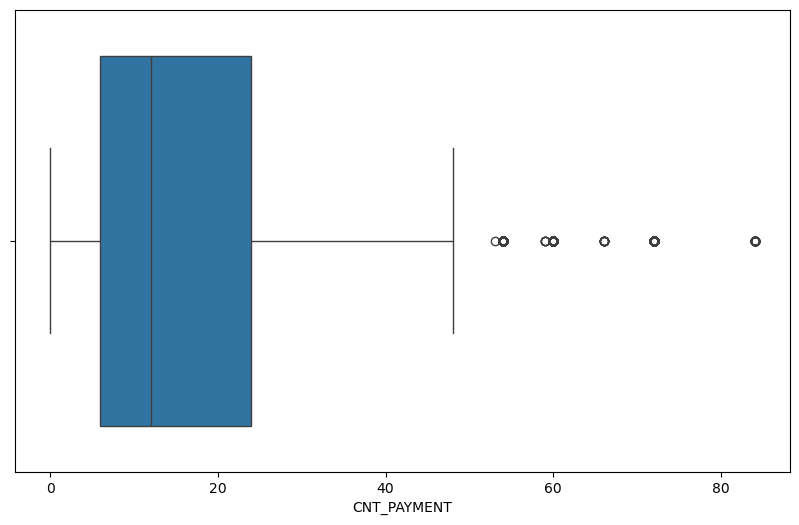

In [395]:
for col in num_cols:
    print("99th Percentile",np.percentile(papp_df[col], 90))
    print(papp_df[col].describe())
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=papp_df,x=col)
    plt.show()

- Conclusion >> Fewer Columns are with outliers are below

1. HOUR_APPR_PROCESS_START has few outliers and there is small difference between mean and median

2. AMT_CREDIT Column has due to outliers and there is a huge difference between the 99th percentile and the max value, also we could see huge variation in mean and median due to outliers

3. AMT_ANNUITY Column has a few outliers and there is a huge difference between the 99th percentile and the max value, also we could see significant variation in mean and median due to outliers

4. AMT_GOODS_PRICE Column has a few outliers and there is a huge difference between the 99th percentile and the max value, also we could see significant variation in mean and median due to outliers

5. AMT_APPLICATION Column has a few outliers and there is a huge difference between the 99th percentile and the max value, also we could see huge variation in mean and median due to outliers

6. CNT_PAYMENT Column has few outliers and there is small difference between mean and median

7. DAYS_DECISION has few outliers and there is small difference between mean and median

## Bivariate and Multivariate Analysis

#### Bivariate Analysis between WEEKDAY_APPR_PROCESS_START vs AMT_APPLICATION

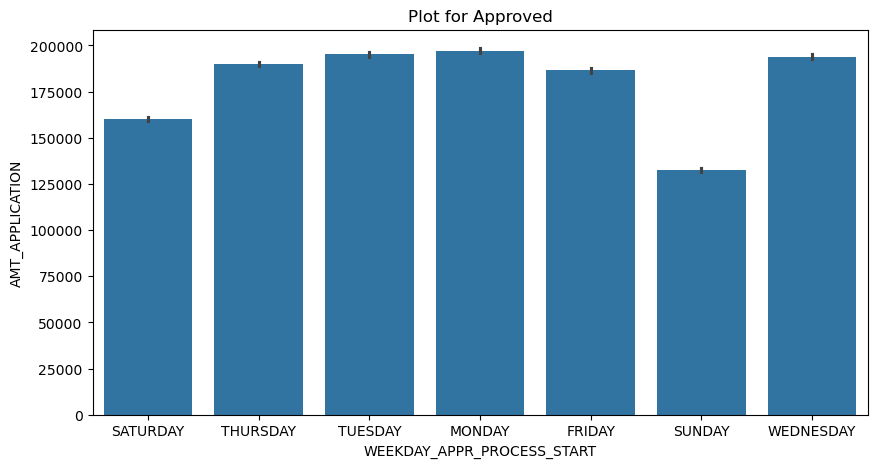

In [398]:
plt.figure(figsize=[10,5])
sns.barplot(x='WEEKDAY_APPR_PROCESS_START', y='AMT_APPLICATION', data=approved)
plt.title("Plot for Approved")
plt.show()

In [399]:
print(papp_df.columns)


Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL',
       'AMT_CREDIT_Category', 'AMT_GOODS_PRICE_Category'],
      dtype='object')


In [400]:
cancelled = papp_df[papp_df['NAME_CONTRACT_STATUS'] == 'Canceled']  # or 'Cancelled' depending on your data


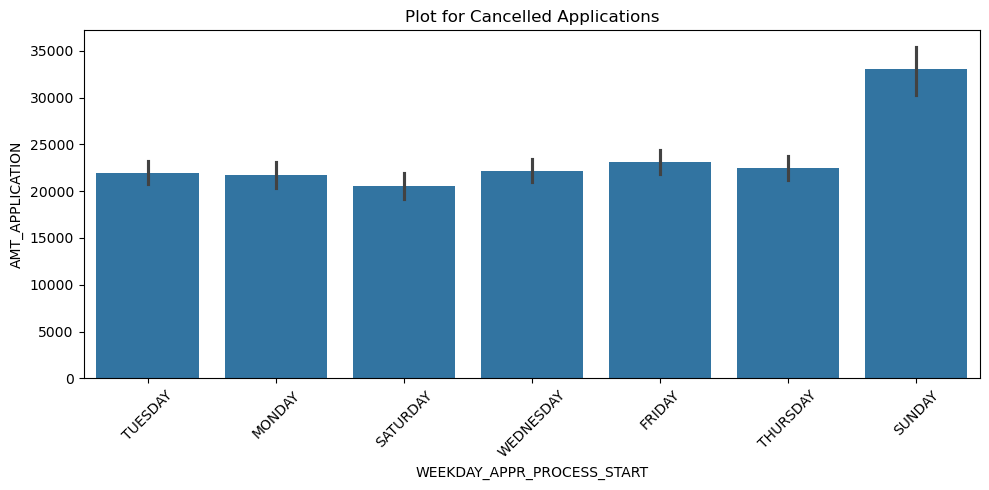

In [401]:
plt.figure(figsize=[10, 5])
sns.barplot(x='WEEKDAY_APPR_PROCESS_START', y='AMT_APPLICATION', data=cancelled)
plt.title("Plot for Cancelled Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


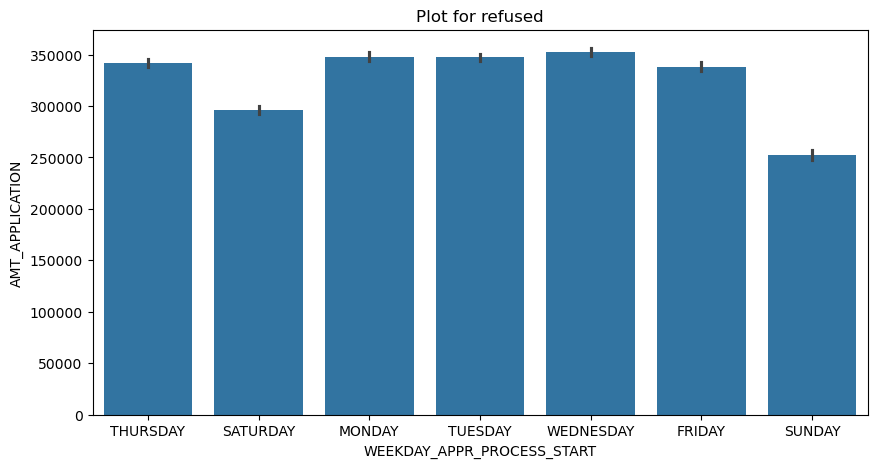

In [402]:
plt.figure(figsize=[10,5])
sns.barplot(x='WEEKDAY_APPR_PROCESS_START', y='AMT_APPLICATION', data=refused)
plt.title("Plot for refused")
plt.show()

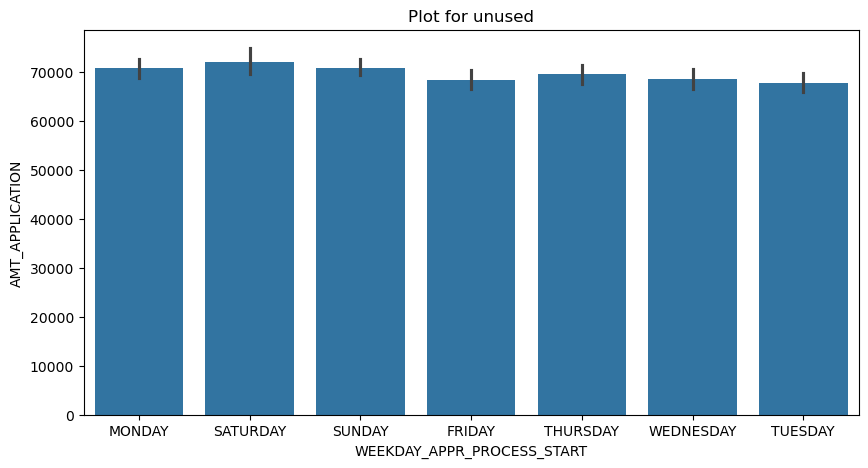

In [403]:
plt.figure(figsize=[10,5])
sns.barplot(x='WEEKDAY_APPR_PROCESS_START', y='AMT_APPLICATION', data=unused)
plt.title("Plot for unused")
plt.show()

- Conclusion >>

1.The Credit Amount of applicants with approved status is high on Monday and Wednesday than other days, and least on Sunday.

2.The Credit Amount of applicants with cancelled status is high on Sunday and almost equal on other days.

3.The Credit Amount of applicants with1 rejected status is least on Sunday and more on Monday and Wednesday

4.The Credit Amount of applicants with unused offer status is almost equal on all days.

## Bivarient Analysis between AMT_ANNUITY vs AMT_GOODS_PRICE 

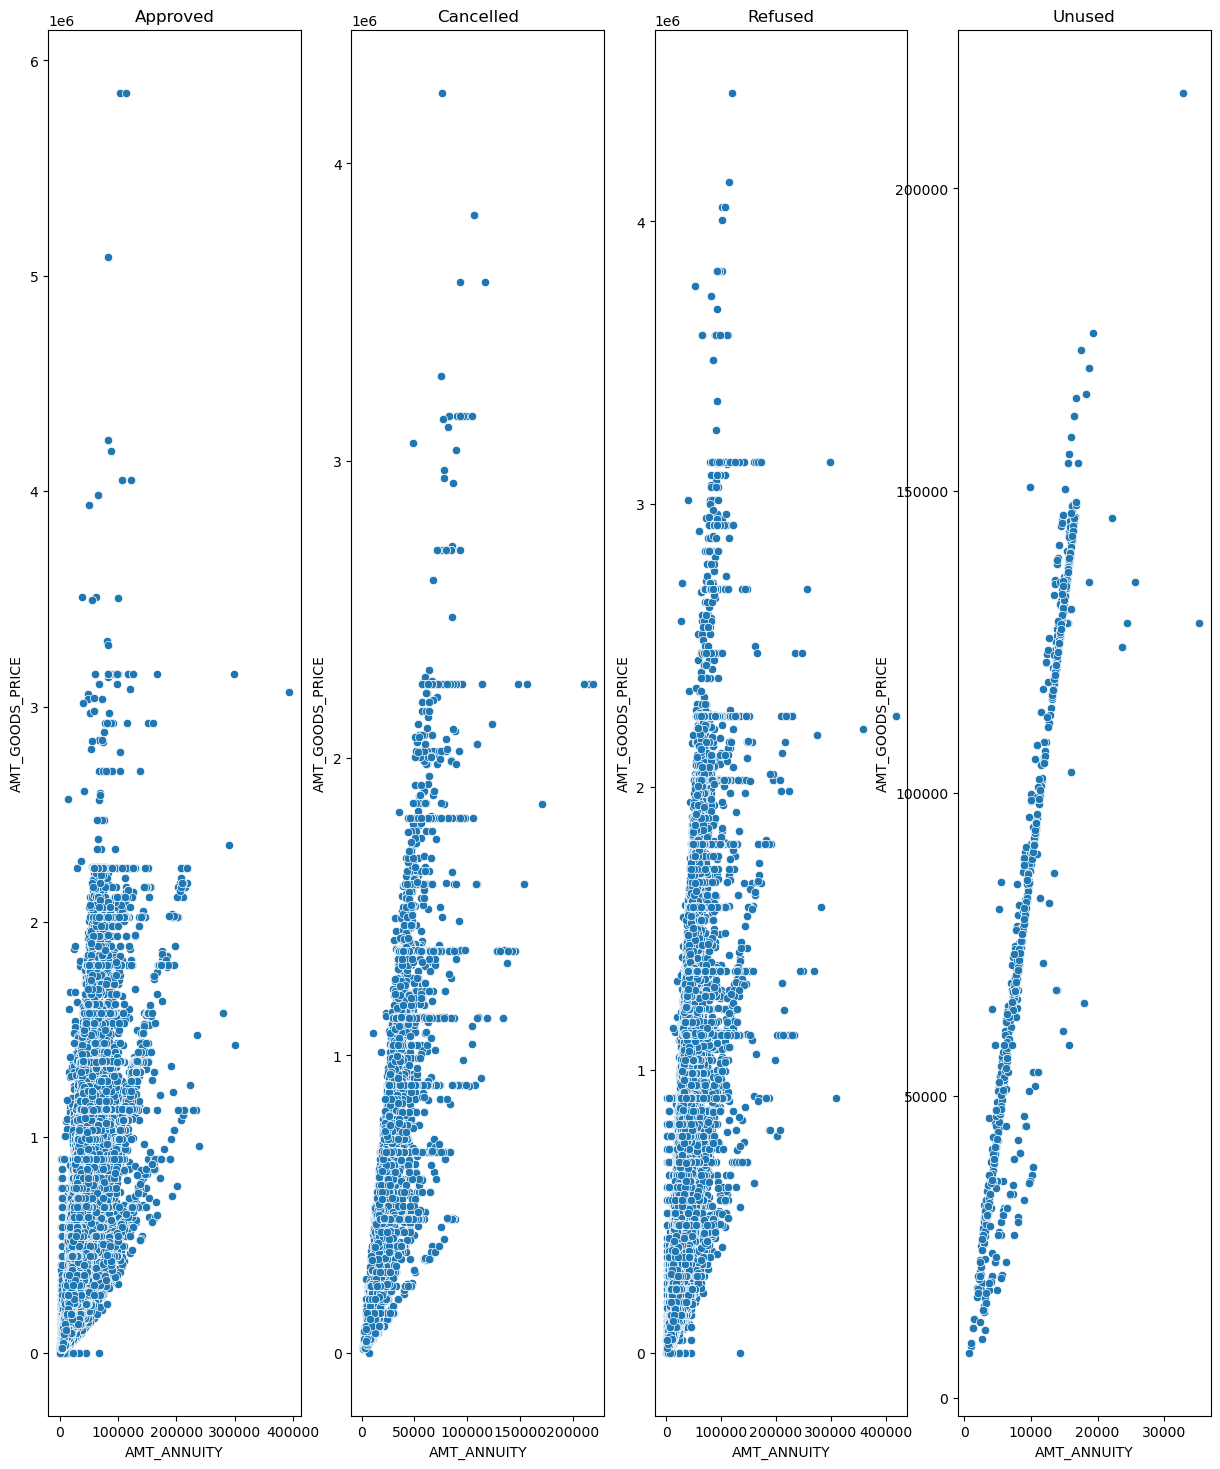

In [406]:
plt.figure(figsize=(15,18))

plt.subplot(1,4,1)
plt.title('Approved')
sns.scatterplot(x='AMT_ANNUITY', y='AMT_GOODS_PRICE', data=approved)

plt.subplot(1,4,2)
plt.title('Cancelled')
sns.scatterplot(x='AMT_ANNUITY', y='AMT_GOODS_PRICE', data=cancelled)

plt.subplot(1,4,3)
plt.title('Refused')
sns.scatterplot(x='AMT_ANNUITY', y='AMT_GOODS_PRICE', data=refused)

plt.subplot(1,4,4)
plt.title('Unused')
sns.scatterplot(x='AMT_ANNUITY', y='AMT_GOODS_PRICE', data=unused)

plt.show()

- conclusion 
1. For loan status as Approved,Refused,Cancelled Amount of annuity increases with Goods price

2. For loan status as refused ,it has no linear relationship

## Co-Relation between NUmerical Columns

In [ ]:
corr_approved = approved[["DAYS_DECISION","AMT_ANNUITY","AMT_APPLICATION","AMT_CREDIT","AMT_GOODS_PRICE","CNT_PAYMENT"]]
corr_refused = refused[["DAYS_DECISION","AMT_ANNUITY","AMT_APPLICATION","AMT_CREDIT","AMT_GOODS_PRICE","CNT_PAYMENT"]]
corr_cancelled = cancelled[["DAYS_DECISION","AMT_ANNUITY","AMT_APPLICATION","AMT_CREDIT","AMT_GOODS_PRICE","CNT_PAYMENT"]]
corr_unused = unused[["DAYS_DECISION","AMT_ANNUITY","AMT_APPLICATION","AMT_CREDIT","AMT_GOODS_PRICE","CNT_PAYMENT"]]

### Co-relation for Numerical columns for Approved

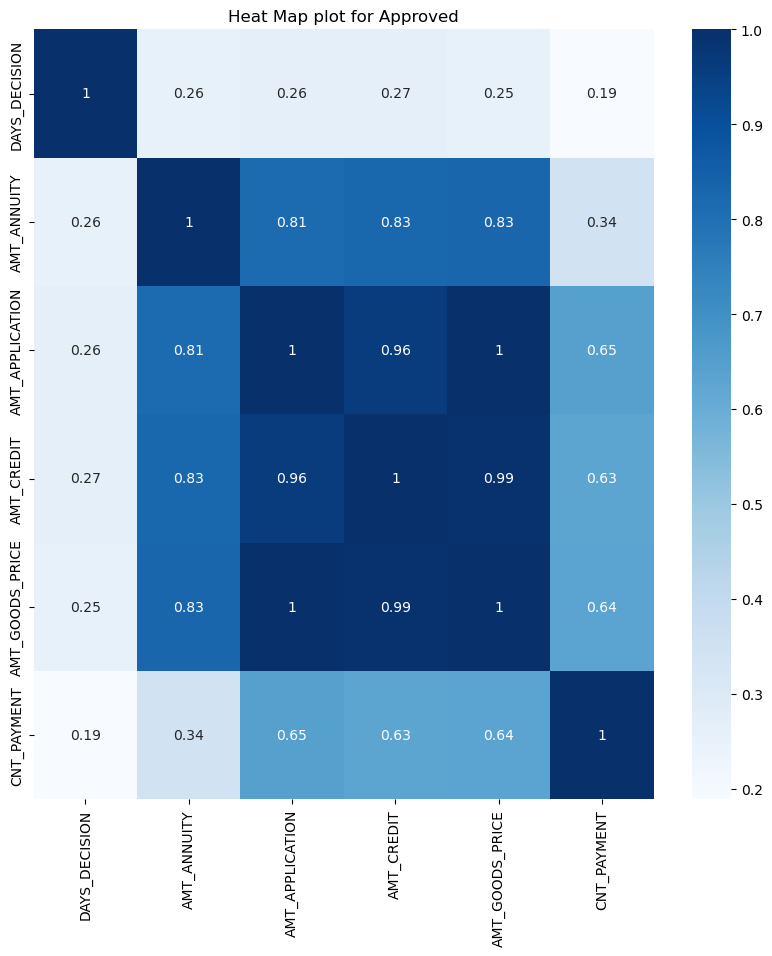

In [411]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_approved.corr(),annot=True,cmap="Blues")
plt.title("Heat Map plot for Approved")
plt.show()

- Conclusion >>

1. AMT_APPLICATION has higher corelation with AMT_CREDIT and AMT_GOODS_PRICE,AMT_ANNUITY

2. DAYS_DECISION has negative corelation with AMT_GOODS_PRICE,AMT_APPLICATION,CNT_PAYMNET,AMT_ANNUITY

### Co-relation for Numerical columns for Refused

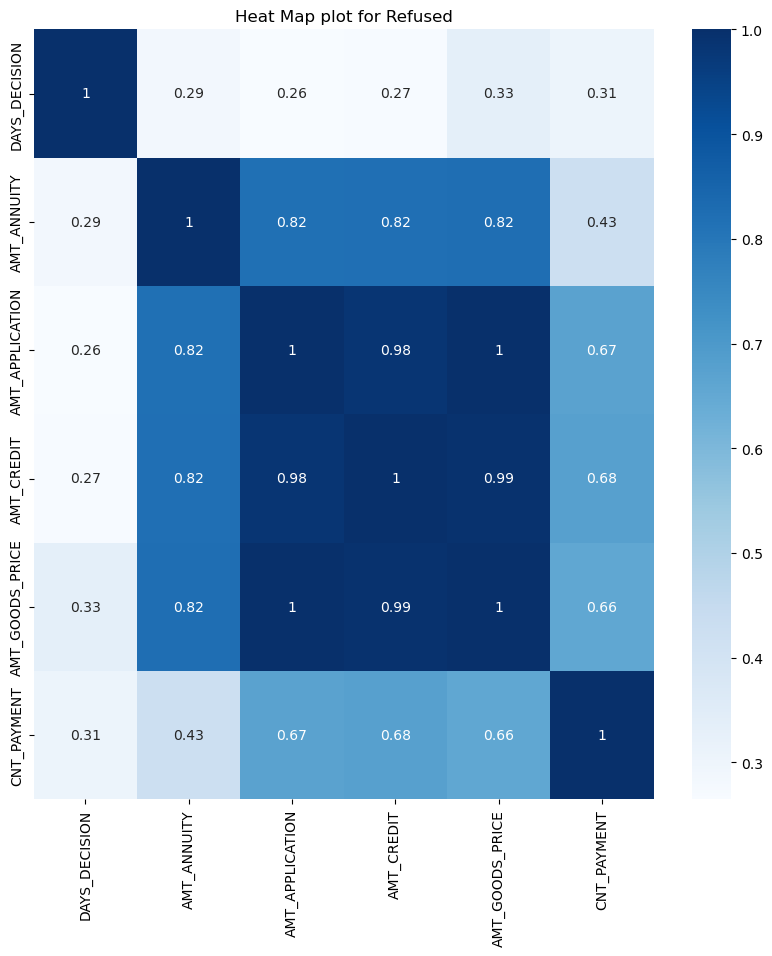

In [414]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_refused.corr(),annot=True,cmap="Blues")
plt.title("Heat Map plot for Refused")
plt.show()

- Conclusion >> For refused category

1.AMT_APPLICATION has higher corelation with AMT_CREDIT and AMT_GOODS_PRICE,AMT_ANNUITY

2.DAYS_DECISION has negative corelation with AMT_GOODS_PRICE,AMT_APPLICATION,CNT_PAYMNET,AMT_ANNUITY

### Co-relation for Numerical columns for cancelled

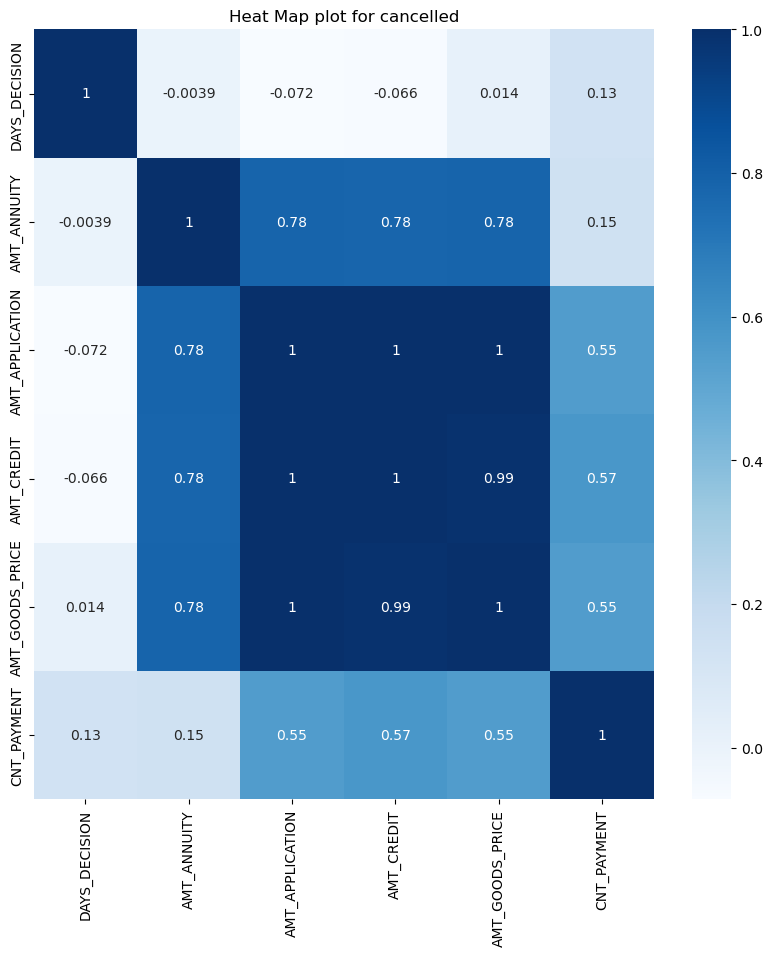

In [417]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_cancelled.corr(),annot=True,cmap="Blues")
plt.title("Heat Map plot for cancelled")
plt.show()

- Conclusion >> For cancelled category

1.AMT_APPLICATION has higher corelation with AMT_CREDIT and AMT_GOODS_PRICE,AMT_ANNUITY

2.DAYS_DECISION has negative corelation with AMT_GOODS_PRICE,AMT_APPLICATION,CNT_PAYMNET,AMT_ANNUITY

### Co-relation for Numerical columns for unused

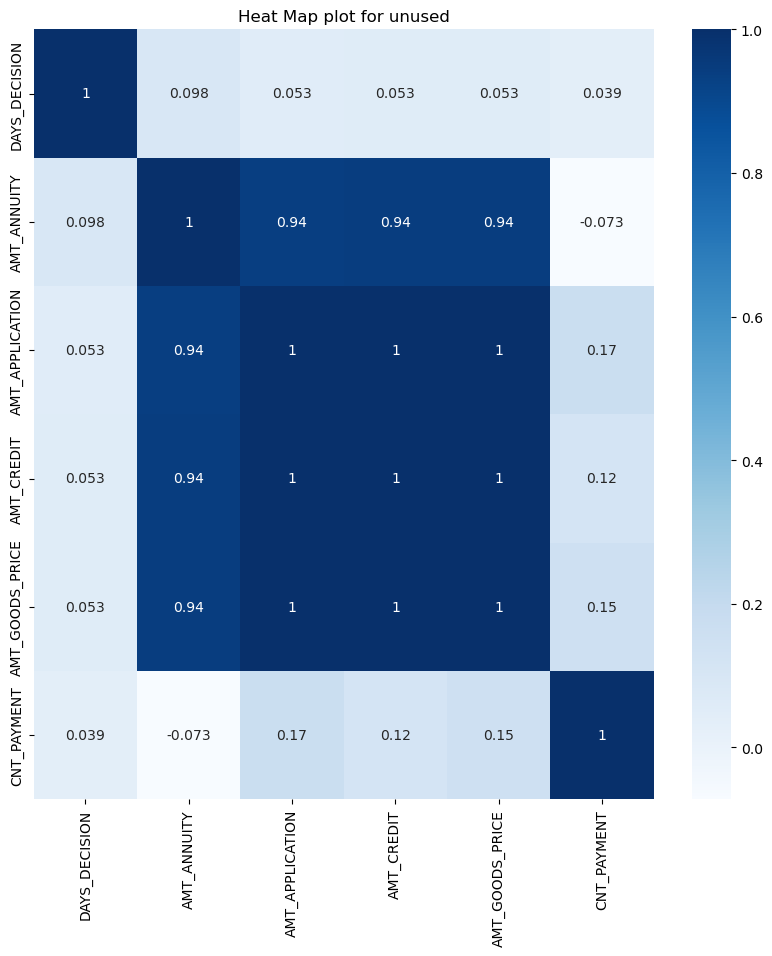

In [420]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_unused.corr(),annot=True,cmap="Blues")
plt.title("Heat Map plot for unused")
plt.show()

- Conclusion >> For unused category

1.AMT_APPLICATION has higher corelation with AMT_CREDIT and AMT_GOODS_PRICE,AMT_ANNUITY

2.DAYS_DECISION  and CNT_PAYMNET has negative corelation with AMT_GOODS_PRICE,AMT_APPLICATION

### Merge the Application and Previous Application DataFrames

In [423]:
merge_df = app_df.merge(papp_df, on="SK_ID_CURR", how="left")
merge_df.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY_x,AMT_GOODS_PRICE_x,NAME_TYPE_SUITE_x,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START_x,HOUR_APPR_PROCESS_START_x,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE,AMT_CREDIT_Category_x,AGE_Category,SK_ID_PREV,NAME_CONTRACT_TYPE_y,AMT_ANNUITY_y,AMT_APPLICATION,AMT_CREDIT_y,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE_y,WEEKDAY_APPR_PROCESS_START_y,HOUR_APPR_PROCESS_START_y,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE_y,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,AMT_CREDIT_Category_y,AMT_GOODS_PRICE_Category
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,9461,637,3648.0,2120,Others,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,26,1,10,5,3,Medium Credit,25-45,1038818.0,Consumer loans,9251.775,179055.0,179055.0,0.0,179055.0,SATURDAY,9.0,Y,1.0,0.000000,NaN,NaN,XAP,Approved,-606.0,XNA,XAP,NaN,New,Vehicles,POS,XNA,Stone,500.0,Auto technolo

In [424]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430155 entries, 0 to 1430154
Columns: 167 entries, SK_ID_CURR to AMT_GOODS_PRICE_Category
dtypes: category(4), float64(84), int64(46), object(33)
memory usage: 1.7+ GB


### Filtering required columnsfor our Analysis

In [426]:
for col in merge_df.columns:
    if col.startswith("Flag"):
        merge_df.drop(columns-col, axis=1, inplace=True)

In [427]:
merge_df.shape

(1430155, 167)

In [442]:
rest1=pd.pivot_table(data=merge_df, index=["NAME_INCOME_TYPE","NAME_CONTRACT_TYPE_x"], columns=["NAME_CONTRACT_STATUS"], values="TARGET",aggfunc="mean")
rest1

NAME_CONTRACT_STATUS                       Approved  Canceled   Refused  \
NAME_INCOME_TYPE     NAME_CONTRACT_TYPE_x                                 
Commercial associate Cash loans            0.073919  0.087494  0.114168   
                     Revolving loans       0.046092  0.055723  0.069899   
Maternity leave      Cash loans            1.000000  1.000000  1.000000   
Pensioner            Cash loans            0.053079  0.061470  0.079020   
                     Revolving loans       0.040764  0.050557  0.067769   
State servant        Cash loans            0.059113  0.073552  0.089116   
                     Revolving loans       0.025676  0.022403  0.047094   
Student              Cash loans            0.000000  0.000000       NaN   
                     Revolving loans       0.000000       NaN  0.000000   
Unemployed           Cash loans            0.469697  0.687500  0.657895   
                     Revolving loans       0.000000       NaN       NaN   
Working              Cash loans            0.092104  0.114957  0.147779   
                     Revolving loans       0.056402  0.067260  0.072031   

NAME_CONTRACT_STATUS                       Unused offer  
NAME_INCOME_TYPE     NAME_CONTRACT_TYPE_x                
Commercial associate Cash loans                0.067485  
                     Revolving loans           0.061024  
Maternity leave      Cash loans                1.000000  
Pensioner            Cash loans                0.054735  
                     Revolving loans           0.020619  
State servant        Cash loans                0.072909  
                     Revolving loans           0.042017  
Student              Cash loans                     NaN  
                     Revolving loans                NaN  
Unemployed           Cash loans                0.000000  
                     Revolving loans                NaN  
Working              Cash loans                0.096194  
                     Revolving loans           0.066856

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

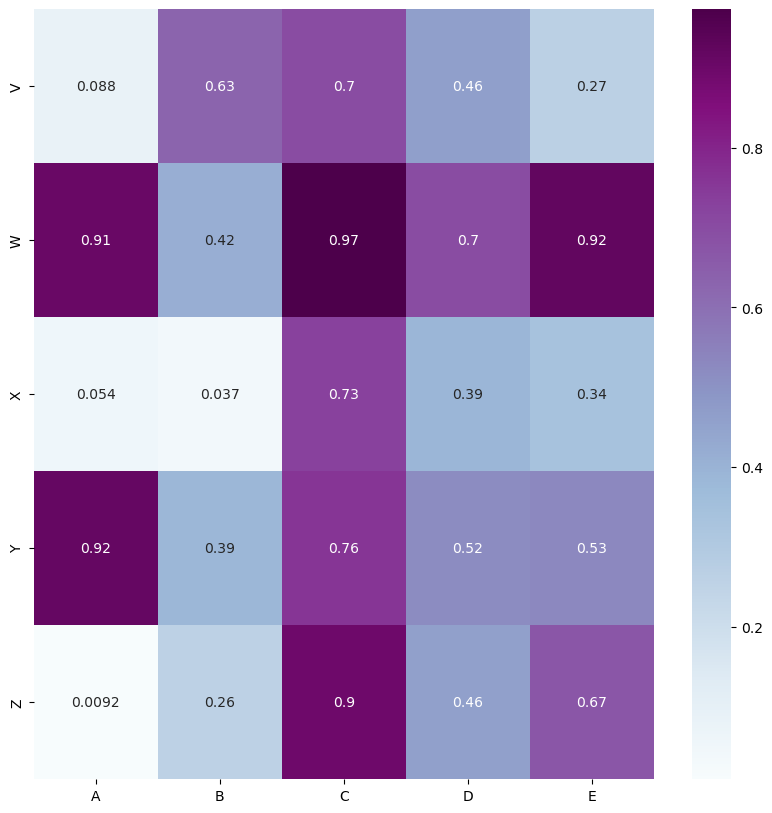

In [448]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
res1 = pd.DataFrame(np.random.rand(5, 5), columns=list('ABCDE'), index=list('VWXYZ'))

plt.figure(figsize=[10,10])
sns.heatmap(res1, annot=True, cmap='BuPu')
plt.show()


- conclusion 

1.Applicants with income type Maternity leave and client type New are more likely to get a loan approved.

2.Applicants with income type Maternity leave, Unemployed, and client type Repeater are more likely to have a loan canceled.

3.Applicants with income type Maternity leave, Unemployed, and client type Repeater who are Working and classified as New are not able to utilize the bank’s offer.
Code Explanation:


In [454]:
res2 = pd.pivot_table(data=merge_df, index=['CODE_GENDER', 'NAME_SELLER_INDUSTRY'], columns=['TARGET'], values=['AMT_GOODS_PRICE_x'], aggfunc='sum'
)

In [456]:
res2

AMT_GOODS_PRICE_x              
TARGET                                           0             1
CODE_GENDER NAME_SELLER_INDUSTRY                                
F           Auto technology           6.111273e+08  5.364450e+07
            Clothing                  9.403640e+09  4.968903e+08
            Connectivity              7.070942e+10  5.910960e+09
            Construction              8.794223e+09  5.130180e+08
            Consumer electronics      1.086232e+11  7.170236e+09
            Furniture                 1.987179e+10  1.034667e+09
            Industry                  5.634099e+09  3.440790e+08
            Jewelry                   6.349129e+08  4.627532e+07
            MLM partners              3.501245e+08  2.293200e+07
            Tourism                   1.711690e+08  5.674500e+06
            XNA                       2.409409e+11  2.068024e+10
M           Auto technology           1.142561e+09  1.286955e+08
            Clothing                  1.418759e+09  1.160505e+08
            Connectivity              4.010272e+10  4.572106e+09
            Construction              3.882024e+09  3.197192e+08
            Consumer electronics      6.305746e+10  5.757388e+09
            Furniture                 5.886620e+09  4.915566e+08
            Industry                  2.905955e+09  2.527595e+08
            Jewelry                   2.021443e+08  2.709533e+07
            MLM partners              6.380550e+07  6.390000e+06
            Tourism                   4.858650e+07  3.640500e+06
            XNA                       1.014658e+11  1.203918e+10
XNA         Connectivity              2.700000e+06           NaN
            Consumer electronics      3.262500e+06           NaN
            Furniture                 1.350000e+06           NaN
            XNA                       2.092500e+07           NaN

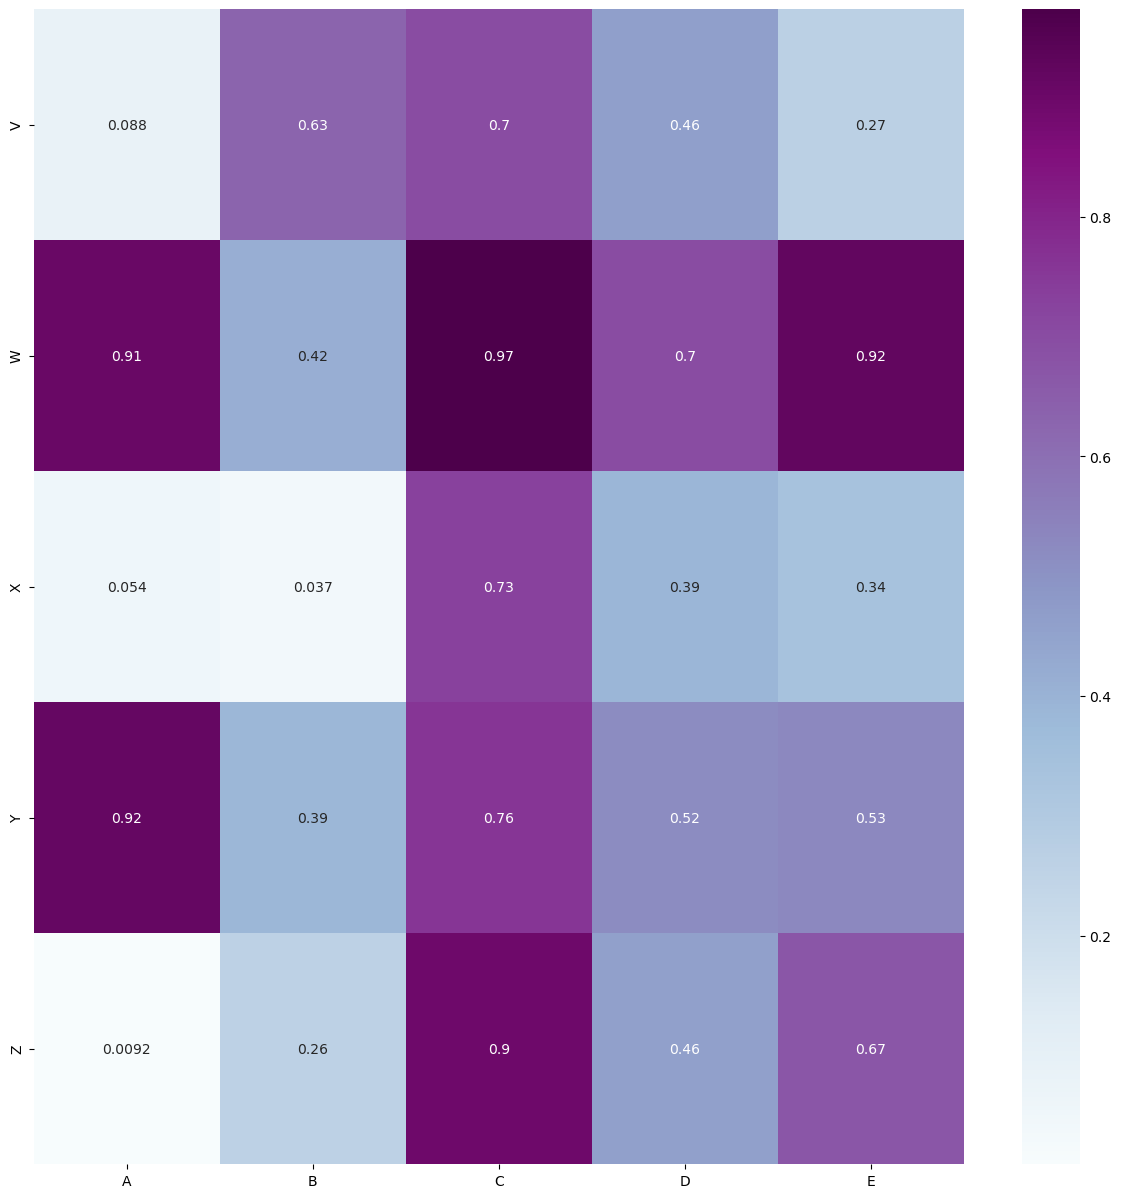

In [458]:
plt.figure(figsize=[15,15])
sns.heatmap(res1, annot=True, cmap='BuPu')
plt.show()